# Spaceship Titanic

## Problem Description

A passenger spaceship hit a spacetime anomaly and ~50% of passengers got transported to an alternate dimension. Using damaged ship records (demographics, cabin info, onboard spending, cryo-sleep status), the task is to predict which passengers were transported (binary classification).
Target: Transported (True/False)
Metric: Classification Accuracy
Key challenge: Missing data, compound cabin field, and engineering spend features around CryoSleep logic.

In [ ]:
!pip install swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=d8764a8230c9a979bd9f9371652eb98d1c86c7ff8786eee161a7d3284104a54f
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter


In [ ]:
!pip install kydavra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.3 MB/s eta 0:00:00


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.3 MB/s eta 0:00:00


In [1]:
!pip install swifter
!pip install kydavra
!pip install optuna

# Import Data Structures
import pandas as pd

# Import Data Manipulation Libraries
import numpy as np
import math
from collections import Counter, defaultdict

# Import Base Classes for Type Annotation
from sklearn.base import BaseEstimator, TransformerMixin
from numbers import Number

# Import Structure Manipulation Methods
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RepeatedEditedNearestNeighbours
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer

# Import Visualization Libs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
sns.set_style(style="whitegrid")
sns.set_palette('bright')

# Import Outlier Detection
from sklearn.ensemble import IsolationForest

# Import Feature Selection Methods
from kydavra import PValueSelector
from sklearn.feature_selection import RFECV

# Import Hyperparameter Tuning
import optuna

# Import ML Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Import Interpretation Metrics
from sklearn.metrics import (classification_report, accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, auc, roc_curve, average_precision_score,
                             roc_auc_score, precision_recall_curve, PrecisionRecallDisplay, make_scorer)
import shap
shap.initjs()

# Import Custom Utils
import swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=786f7d3a08824698f18e6ba3ef21dabf98861fba048ecc14816d77fa9d4ca7e5
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.3 MB/s eta 0:00:00


## Dataset Loading
Since both training and test datasets are not very large, basic `pandas.DataFrame` will be sufficient.

In [2]:
train_raw = pd.read_csv("/content/train.csv")
test_raw = pd.read_csv("/content/test.csv")

In [3]:
train_raw.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train_raw["PassengerId"].value_counts()

,count
PassengerId,
9280_02,1
0001_01,1
0002_01,1
0003_01,1
0003_02,1
...,...
0008_01,1
0007_01,1
0006_02,1


In [5]:
train_raw['group_suffix'] = train_raw['PassengerId'].str.split('_').str[1]
train_raw['group_suffix'].value_counts().sort_index()

,count
group_suffix,
01,6217
02,1412
03,571
04,231
05,128
06,75
07,46
08,13


In [6]:
train_raw['group_suffix'] = train_raw['PassengerId'].str.split('_').str[1]
train_raw.groupby('group_suffix')['Transported'].mean()

,Transported
group_suffix,
01,0.475953
02,0.558782
03,0.618214
04,0.593074
05,0.546875
06,0.546667
07,0.500000
08,0.461538


In [8]:
train_raw['group_id'] = train_raw['PassengerId'].str.split('_').str[0].astype(int)
train_raw['group_suffix'] = train_raw['PassengerId'].str.split('_').str[1].astype(int)
group_size = train_raw['group_id'].map(train_raw['group_id'].value_counts())
train_raw['group_size'] = group_size
train_raw['is_alone'] = (train_raw['group_size'] == 1).astype(int)
train_raw.drop(columns=['PassengerId', 'group_size', 'group_id', 'group_suffix'], inplace=True)

There is a connection, but it's weak, and the feature of whether there was 1 person or not could be useful.

In [9]:
train_raw.tail(n=5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,is_alone
8688,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,1
8689,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,1
8690,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,1
8691,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,0
8692,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True,0


In [ ]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


There are no columns of int64 data type in this dataset. We have 6 numerical (float64) columns and 7 text (object) columns, plus 1 boolean target. Most columns have some missing values, so we'll need to handle those. In total there are 13 features and 1 target variable — Transported

In [ ]:
train_raw.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


After a brief analysis of the described dataset, were derived several conclusions:
1.Spending features are heavily zero-skewed - for RoomService, FoodCourt, ShoppingMall, and Spa, both the 25% and 50% percentiles are 0, meaning more than half of passengers spent nothing. This suggests a lot of outliers on the high end, confirmed by very large max values (e.g. FoodCourt goes up to 29,813).
2.Age looks clean - ranges from 0 to 79 with a mean of ~29, no obvious issues there.
3.High standard deviations on spend columns relative to their means indicate the data is quite spread out - this could affect distance-based models like KNN or Logistic Regression, so scaling will likely be needed.

In [ ]:
train_raw.shape

(8693, 14)

In [ ]:
train_raw.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [ ]:
missing_values_cols: list[str] = train_raw.isnull().sum()[train_raw.isnull().sum() > 0].index.tolist()
missing_values_cols

['HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name']

In [ ]:
for col in missing_values_cols:
    print(f"Feature '{col}': {train_raw[col].isnull().sum()} missing values ({(train_raw[col].isnull().sum() / train_raw.shape[0] * 100):.2f}%)")

Feature 'HomePlanet': 201 missing values (2.31%)
Feature 'CryoSleep': 217 missing values (2.50%)
Feature 'Cabin': 199 missing values (2.29%)
Feature 'Destination': 182 missing values (2.09%)
Feature 'Age': 179 missing values (2.06%)
Feature 'VIP': 203 missing values (2.34%)
Feature 'RoomService': 181 missing values (2.08%)
Feature 'FoodCourt': 183 missing values (2.11%)
Feature 'ShoppingMall': 208 missing values (2.39%)
Feature 'Spa': 183 missing values (2.11%)
Feature 'VRDeck': 188 missing values (2.16%)
Feature 'Name': 200 missing values (2.30%)


There are a large number of missing values ​​in almost all columns. The highest number of nanos is in CryoSleep, and the lowest is in Age.

EDA

In [ ]:
train = train_raw.dropna()

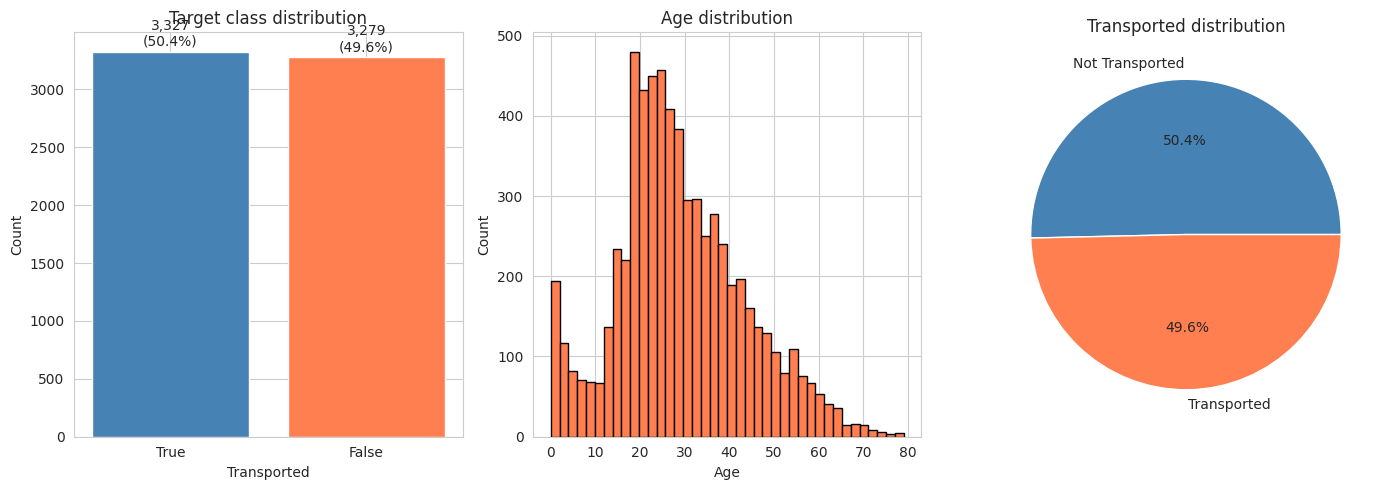

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Plot 1: Target class distribution (bar)
counts = train['Transported'].value_counts()
axes[0].bar(counts.index.astype(str), counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Target class distribution')
axes[0].set_xlabel('Transported')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center')

# Plot 2: Age distribution (histogram)
train['Age'].clip(upper=100).hist(bins=40, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Age distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# Plot 3: Pie chart of target
axes[2].pie(
    counts.values,
    autopct='%1.1f%%',
    labels=['Not Transported', 'Transported'],
    colors=['steelblue', 'coral']
)
axes[2].set_title('Transported distribution')

plt.tight_layout()
plt.show()

The data are very well balanced, but in principle the sample is very small - about 4000-4400 copies per class.
Moreover, the majority of passengers are between 20 and 40 years old.

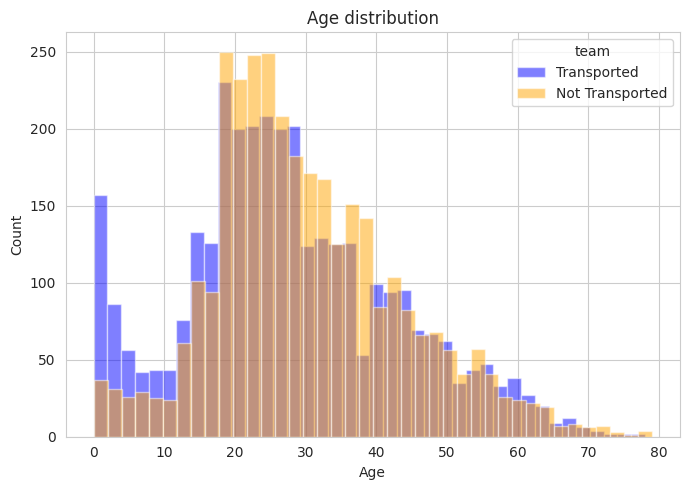

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(train[train['Transported']==1]['Age'].dropna(),
        bins=40, color='blue', alpha=0.5, label='Transported')
ax.hist(train[train['Transported']==0]['Age'].dropna(),
        bins=40, color='orange', alpha=0.5, label='Not Transported')
ax.set_title('Age distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend(title='team')

plt.tight_layout()
plt.show()

The distribution is right-skewed, with most passengers being between 18–35 years old, peaking around 20–25.
Young children (0–5) show a notably high proportion of transported passengers (blue), suggesting age may be a meaningful feature.
For middle-aged passengers (20–45), the not-transported (orange) group dominates slightly.
Overall, the age pattern hints that Age could be a useful predictor, especially at the younger end.

Анализ выбросов

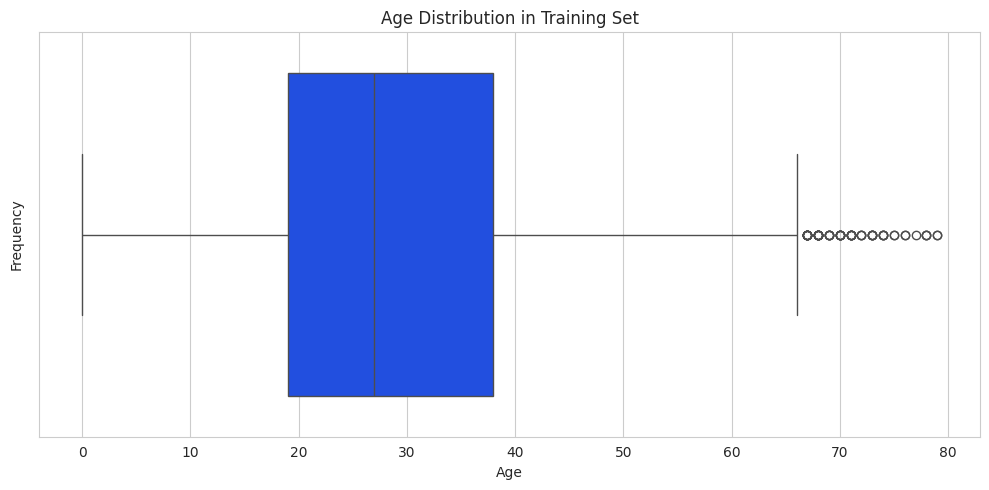

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

sns.boxplot(
    data=train,
    x='Age',
    ax=ax
)
ax.set_title('Age Distribution in Training Set')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
def get_outliers_by_boxplot(df: pd.DataFrame, column: str) -> pd.Series:
    Q1 = train[column].quantile(0.25)
    Q3 = train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_mask = (df[column] < lower_bound) | (train[column] > upper_bound)
    outliers_mask = outliers_mask.apply(
        lambda x: -1 if x else 1
    )

    return outliers_mask

In [ ]:
outliers_age_mask = get_outliers_by_boxplot(train, 'Age')
print(f"Total Number of Samples: {train.shape[0]}")
print(f"Number of Outliers in Age Column detected using Boxplot Method: {outliers_age_mask[outliers_age_mask == -1].count()}")
print(f"Number of Inliers in Age Column detected using Boxplot Method: {outliers_age_mask[outliers_age_mask == 1].count()}")
print(f"Percentage of Outliers in Age Column detected using Boxplot Method: {(train[outliers_age_mask == -1].shape[0] / train.shape[0] * 100):.5f}%")
print(f"Percentage of Inliers in Age Column detected using Boxplot Method: {(train[outliers_age_mask == 1].shape[0] / train.shape[0] * 100):.5f}%")

Total Number of Samples: 6606
Number of Outliers in Age Column detected using Boxplot Method: 62
Number of Inliers in Age Column detected using Boxplot Method: 6544
Percentage of Outliers in Age Column detected using Boxplot Method: 0.93854%
Percentage of Inliers in Age Column detected using Boxplot Method: 99.06146%


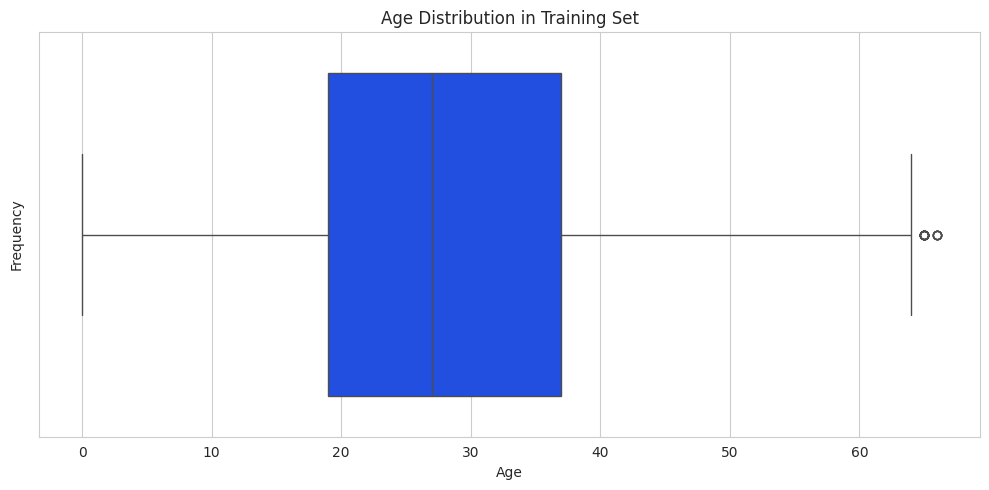

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

sns.boxplot(
    data=train[outliers_age_mask == 1],
    x='Age',
    ax=ax
)
ax.set_title('Age Distribution in Training Set')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Passengers aged 65+ could be considered domain-specific outliers — in the context of an interstellar voyage in 2912, it's reasonable to assume that elderly passengers would be unlikely to undertake such a journey. These values may represent data entry errors or edge cases rather than genuine observations, which justifies treating them as outliers.

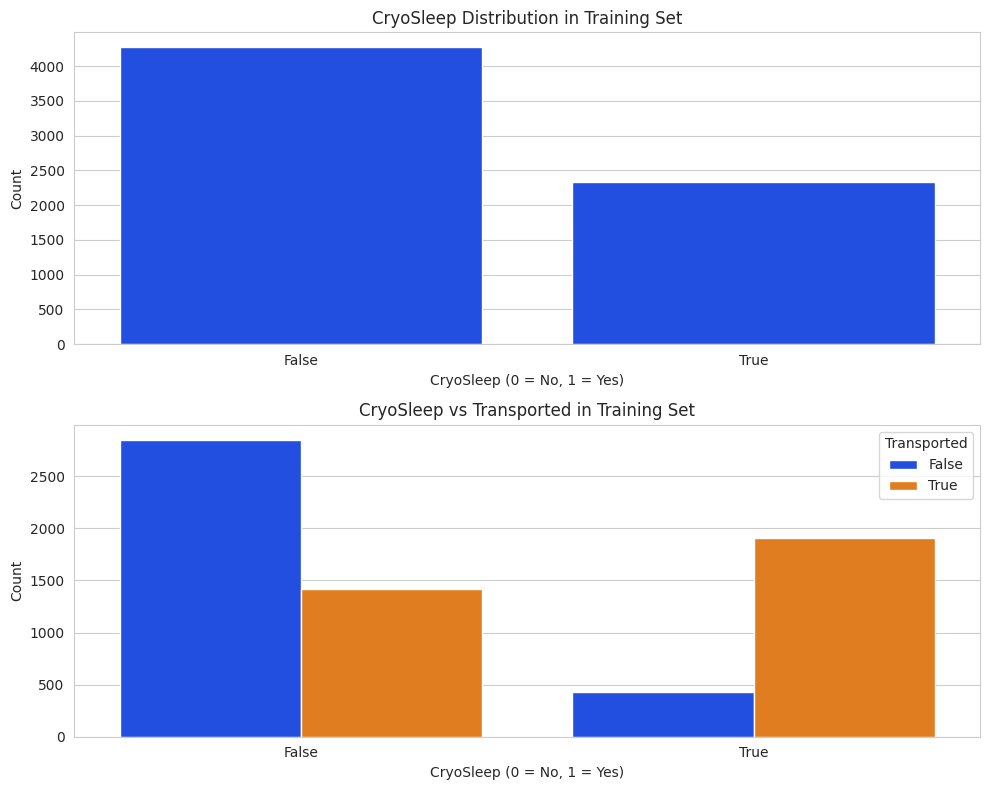

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

sns.countplot(data=train, x='CryoSleep', ax=axes[0])
axes[0].set_title('CryoSleep Distribution in Training Set')
axes[0].set_xlabel('CryoSleep (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

sns.countplot(data=train, x='CryoSleep', hue='Transported', ax=axes[1])
axes[1].set_title('CryoSleep vs Transported in Training Set')
axes[1].set_xlabel('CryoSleep (0 = No, 1 = Yes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

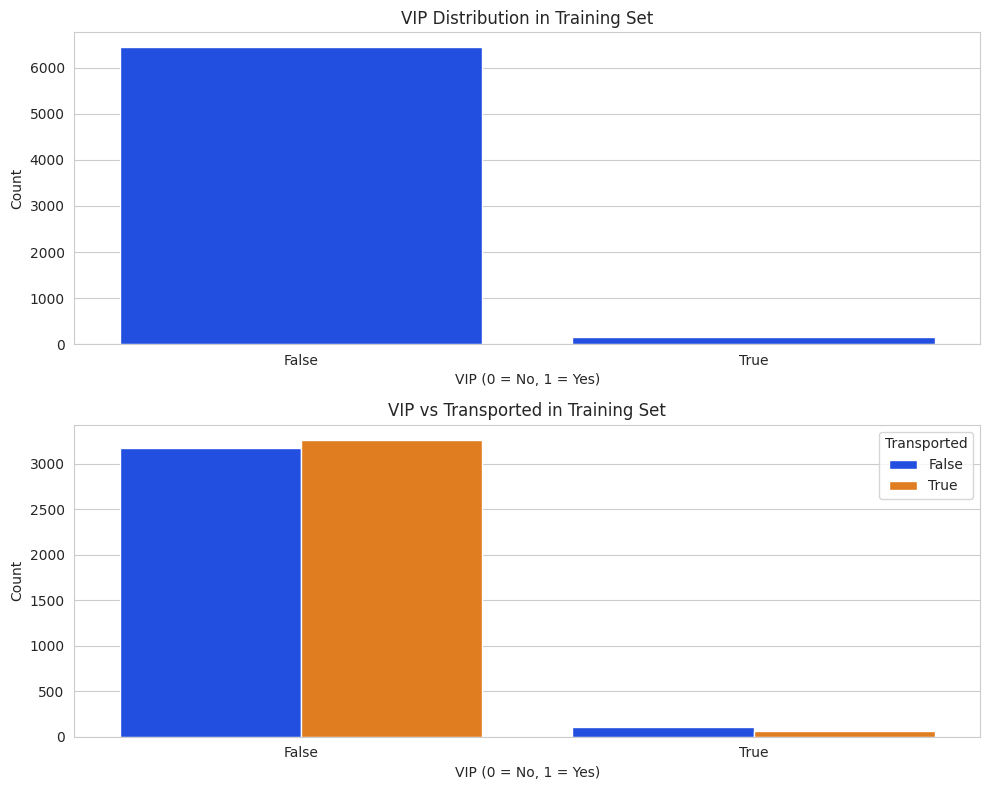

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

sns.countplot(data=train, x='VIP', ax=axes[0])
axes[0].set_title('VIP Distribution in Training Set')
axes[0].set_xlabel('VIP (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

sns.countplot(data=train, x='VIP', hue='Transported', ax=axes[1])
axes[1].set_title('VIP vs Transported in Training Set')
axes[1].set_xlabel('VIP (0 = No, 1 = Yes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

there is a very big imbalance

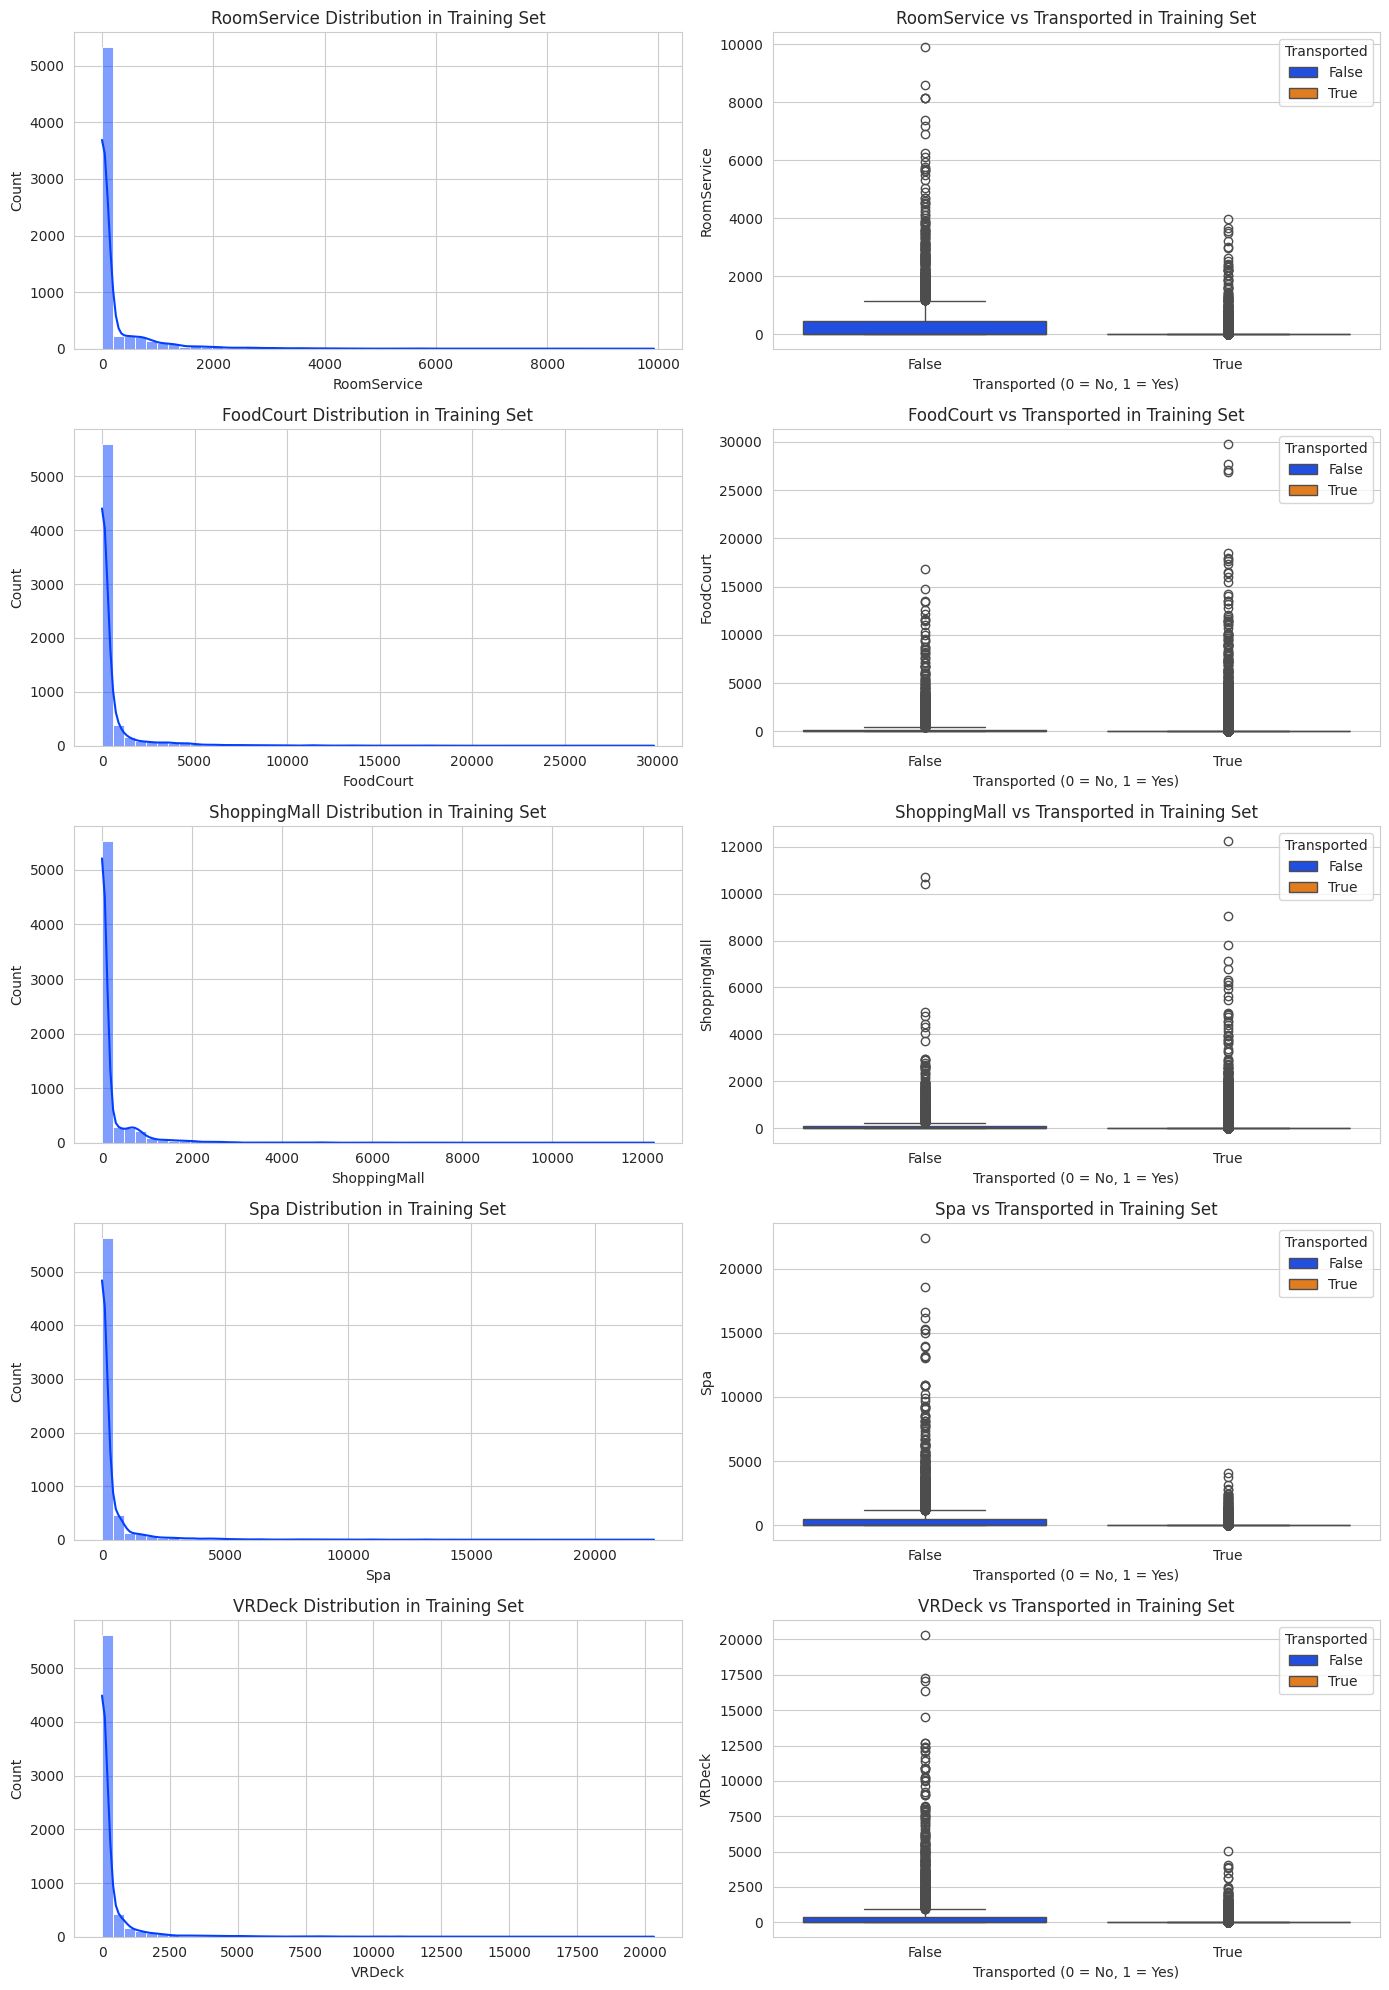

In [ ]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(nrows=len(spend_cols), ncols=2, figsize=(14, 20))

for i, col in enumerate(spend_cols):
    sns.histplot(data=train, x=col, bins=50, kde=True, ax=axes[i][0])
    axes[i][0].set_title(f'{col} Distribution in Training Set')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Count')

    sns.boxplot(x=train['Transported'], y=train[col], hue=train['Transported'], ax=axes[i][1])
    axes[i][1].set_title(f'{col} vs Transported in Training Set')
    axes[i][1].set_xlabel('Transported (0 = No, 1 = Yes)')
    axes[i][1].set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
train = train.drop("PassengerId", axis=1)
train = train.drop("Name", axis=1)
train["Transported"] = train["Transported"].map({False:0, True:1})
train["CryoSleep"] = train["CryoSleep"].map({False:0, True:1})
train["VIP"] = train["VIP"].map({False:0, True:1})
train

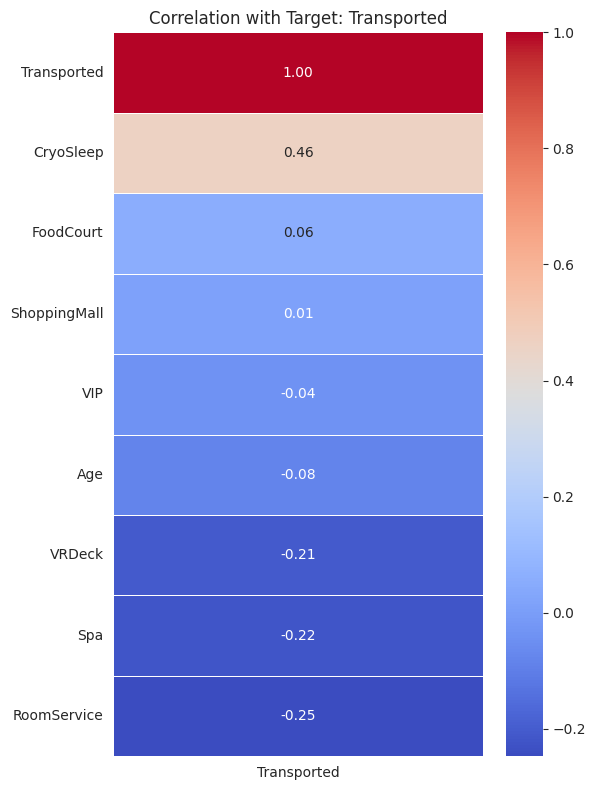

In [ ]:
target = train['Transported'].astype(int).reset_index(drop=True)

corr_df = train.copy().reset_index(drop=True)
corr_df['Transported'] = target

corr = corr_df.select_dtypes(include='number').corr()

plt.figure(figsize=(6, 8))
sns.heatmap(corr[['Transported']].sort_values('Transported', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation with Target: Transported')
plt.tight_layout()
plt.show()

Among the numerical data, for engineering features that don't require one-hot encoding, the CryoSleep feature has the strongest correlation. Because people who have been in cryosleep experience a slowdown or complete halt in the aging and wear and tear of their bodies, the likelihood of a passenger successfully reaching the required distance is higher.

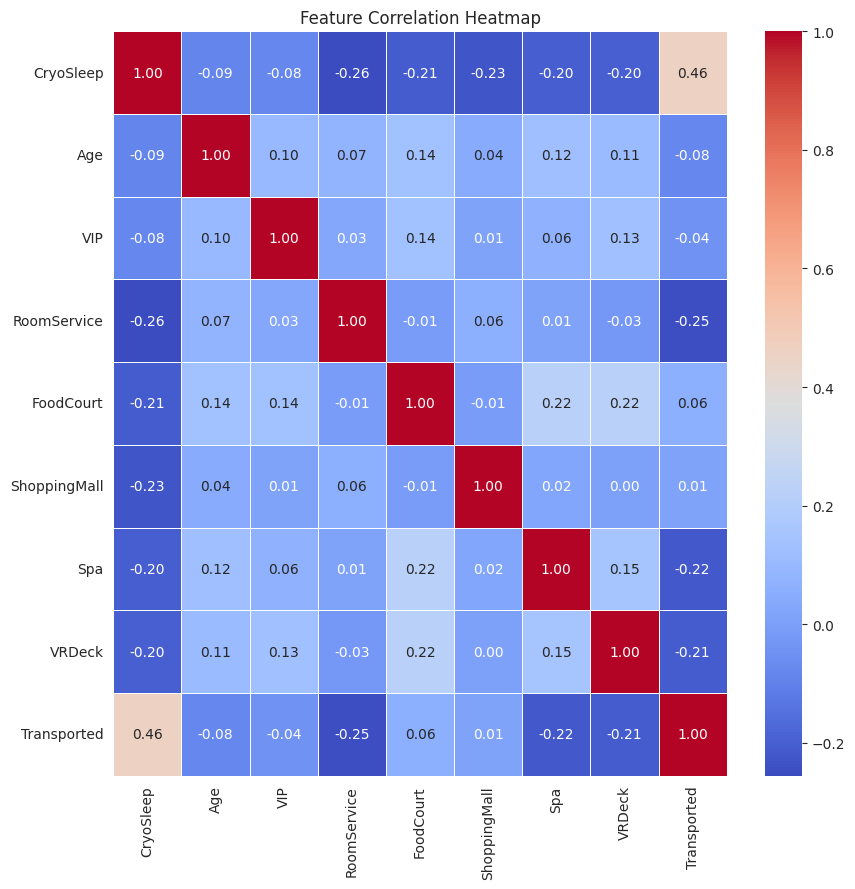

In [ ]:
corr = train.select_dtypes(include='number').corr()
plt.figure(figsize=(9, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In the correlation matrix, there is a negative correlation between CryoSleep and RoomService, FoodCourt, ShoppingMall, Spa, VRDeck because people in cryo sleep did not make purchases more than those necessary to maintain life.

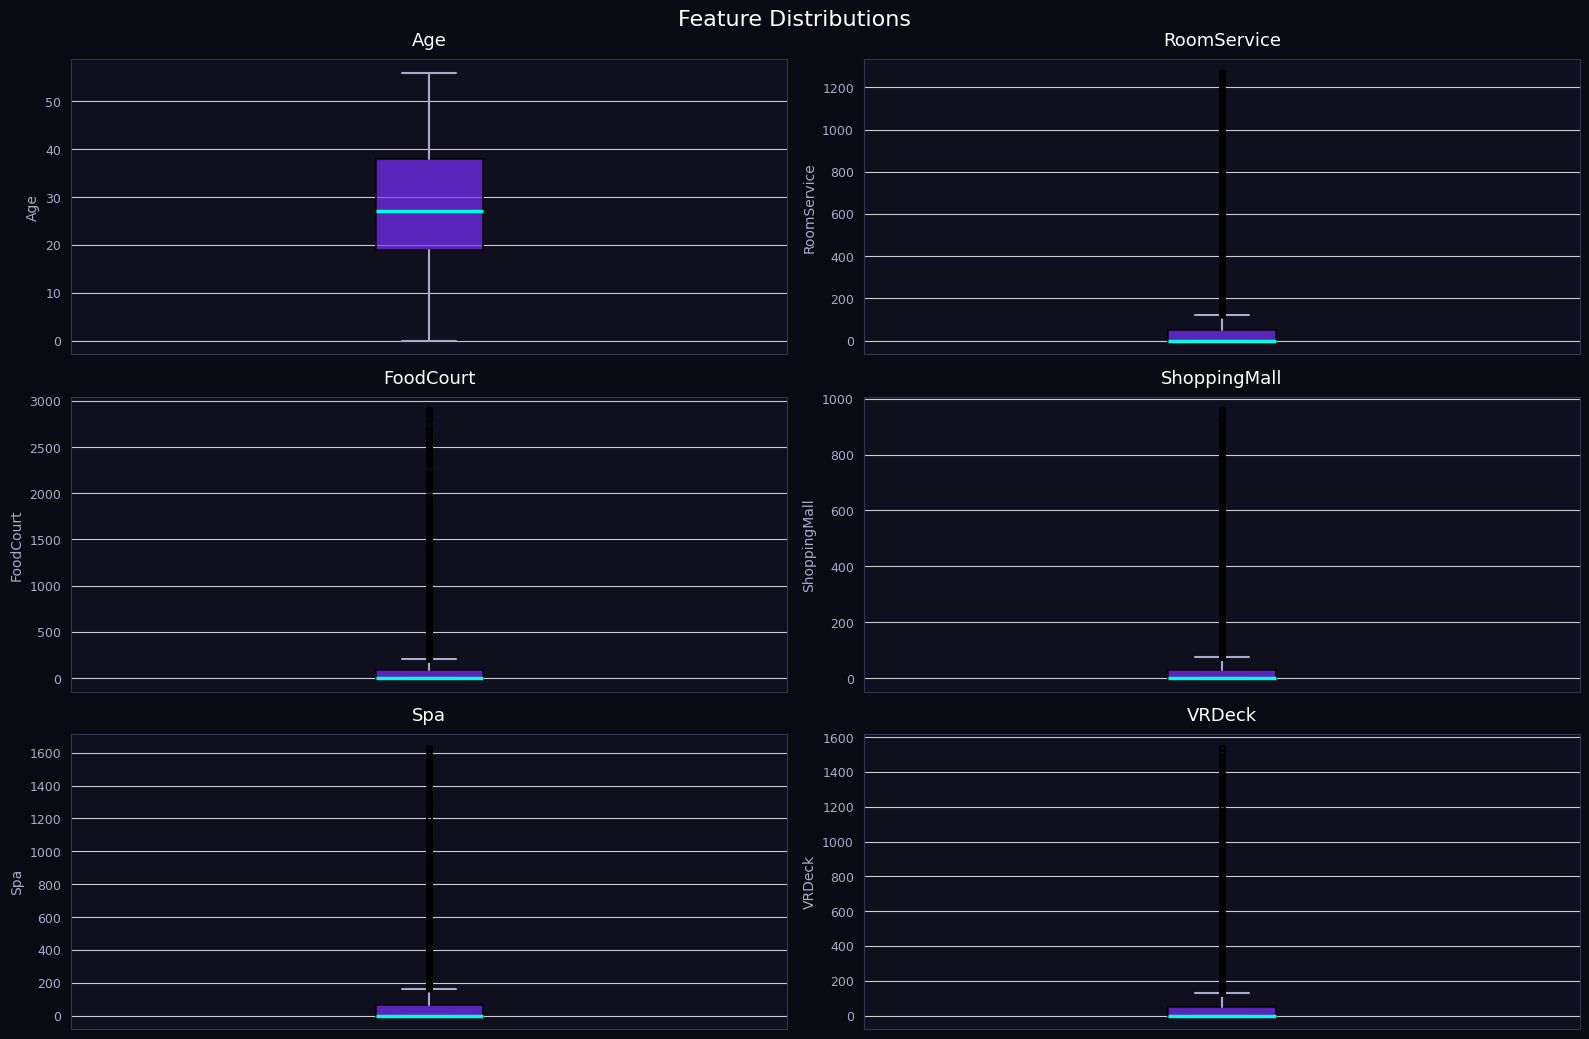

In [ ]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(4, 2, figsize=(16, 14), facecolor='#0a0a12')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#0f0f1e')
    q95 = train[col].quantile(0.95)
    data = train[col].clip(upper=q95).dropna()

    bp = ax.boxplot(data, patch_artist=True, vert=True,
                    medianprops=dict(color='#00ffe0', linewidth=2.5),
                    whiskerprops=dict(color='#aaaacc', linewidth=1.5),
                    capprops=dict(color='#aaaacc', linewidth=1.5),
                    flierprops=dict(marker='o', color='#ff3cac', alpha=0.4, markersize=4),
                    boxprops=dict(linewidth=1.5))

    bp['boxes'][0].set_facecolor('#7b2fff')
    bp['boxes'][0].set_alpha(0.7)

    ax.set_title(f'{col}', color='white', fontsize=13, pad=10)
    ax.set_ylabel(col, color='#aaaacc', fontsize=10)
    ax.tick_params(colors='#aaaacc', labelsize=9)
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', color='white', fontsize=16)
plt.tight_layout()
plt.show()

Age - nicely distributed, median around 27–28, range 0–55 (clipped at 95th percentile). No extreme skew.
Spending features (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) - all show the same pattern: median and 25–75% box squashed near zero, with a long whisker upward. This confirms what we saw in describe() - most passengers spent nothing, but a few spent a lot, creating heavy right skew and many outliers.

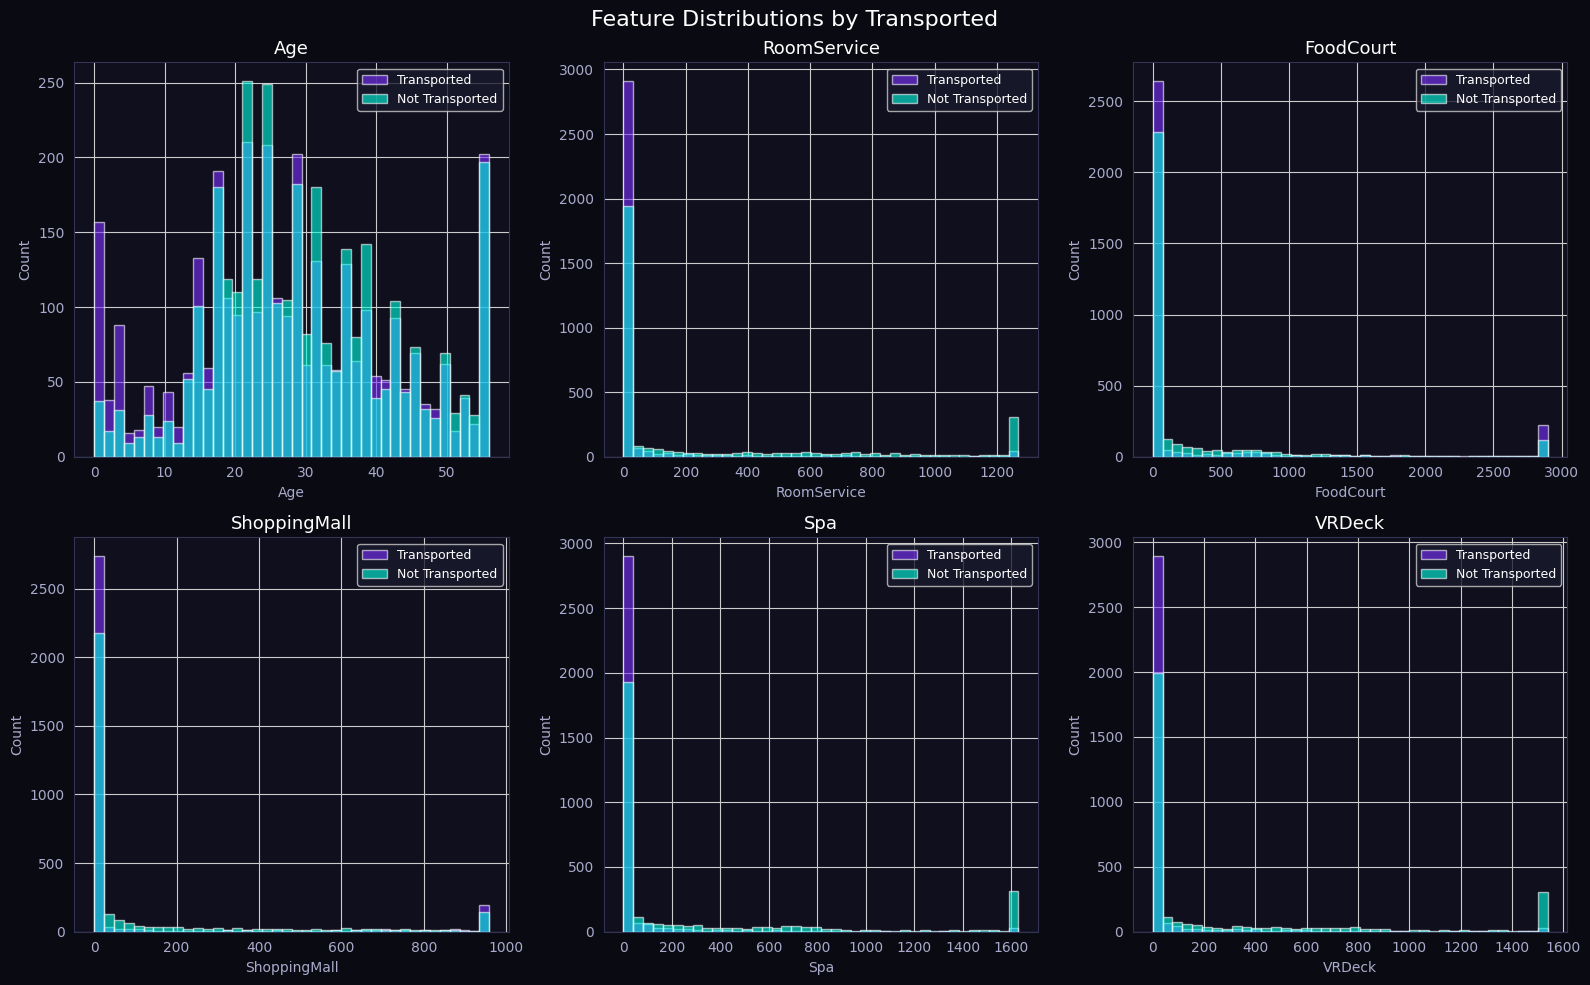

In [ ]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
plot_df = train.loc[:, ~train.columns.duplicated()].copy()
fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor='#0a0a12')
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#0f0f1e')

    q95 = plot_df[col].quantile(0.95)

    ax.hist(plot_df[plot_df['Transported']==1][col].clip(upper=q95).dropna(),
            bins=40, color='#7b2fff', alpha=0.6, label='Transported')
    ax.hist(plot_df[plot_df['Transported']==0][col].clip(upper=q95).dropna(),
            bins=40, color='#00ffe0', alpha=0.6, label='Not Transported')

    ax.set_title(col, color='white', fontsize=13)
    ax.set_xlabel(col, color='#aaaacc')
    ax.set_ylabel('Count', color='#aaaacc')
    ax.tick_params(colors='#aaaacc')
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.suptitle('Feature Distributions by Transported', color='white', fontsize=16)
plt.tight_layout()
plt.show()

Добавление, не накладывание stack histogram

The Age feature shows that more younger passengers had a positive travel experience than those with a negative one, suggesting a correlation with age. And based on features directly related to how much people paid for various services during the trip, it can be concluded that a large proportion of those who paid virtually nothing made it to the destination because they were in cryo-sleep.

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
CYAN   = '#00ffe0'
PINK   = '#ff3cac'
PURPLE = '#7b2fff'
AMBER  = '#ffdd00'
BLUE   = '#00b4ff'
planet = train.groupby(['HomePlanet', 'Transported']).size().reset_index(name='count')

fig2 = px.bar(planet, x='Transported', y='count', color='HomePlanet',
              barmode='group',
              color_discrete_map={True: CYAN, False: PINK})
fig2.update_traces(marker_line_color='#0a0a12', marker_line_width=1.5)
fig2.update_layout(
    paper_bgcolor='#0a0a12', plot_bgcolor='#0f0f1e',
    font=dict(family='monospace', color='#ccc'),
    title=dict(text='Пассажиры по планете × Transported',
               font=dict(size=15, color='#fff'), x=0.5),
    xaxis=dict(gridcolor='rgba(80,60,180,0.15)', zerolinecolor='rgba(80,60,180,0.15)',
               tickfont=dict(color='#555577')),
    yaxis=dict(gridcolor='rgba(80,60,180,0.15)', zerolinecolor='rgba(80,60,180,0.15)',
               tickfont=dict(color='#555577')),
    legend=dict(bgcolor='rgba(15,15,30,0.8)', bordercolor='#2a2a4a',
                borderwidth=1, font=dict(color='#ccc')),
    margin=dict(l=50, r=30, t=60, b=50)
)
fig2.show()

Earth dominates in passenger numbers in both classes, but there are significantly more passengers among the non-transported classes, indicating that Earthlings were transported less frequently.
Europa shows the opposite pattern: among the transported classes, there are almost twice as many passengers as among the non-transported. This is a strong signal—passengers from Europa were transported significantly more often.
Mars is roughly balanced between classes, with slightly more passengers among the transported classes.

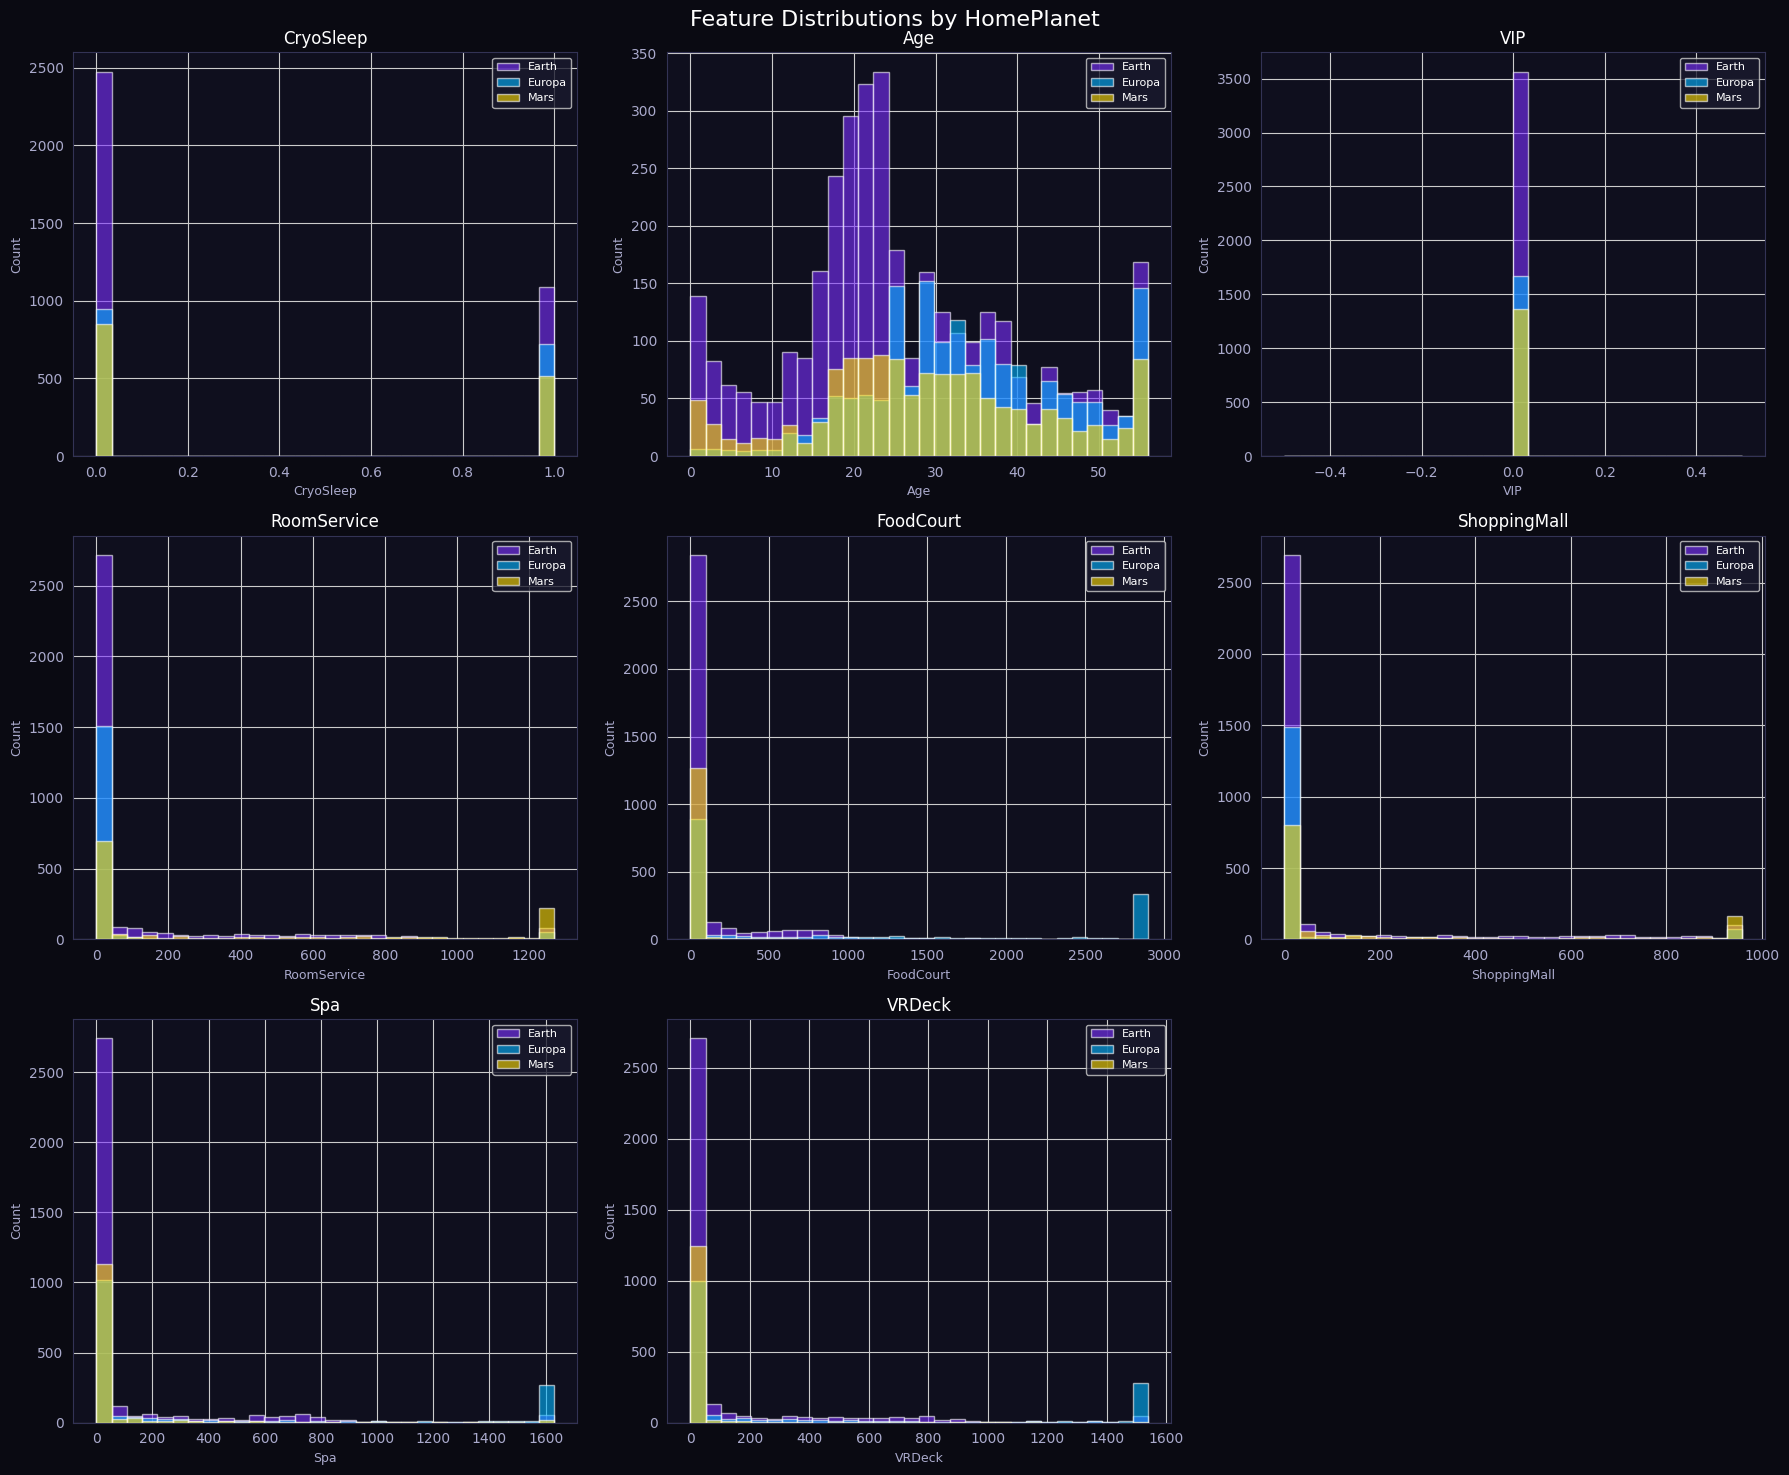

In [ ]:
num_cols_only = [c for c in train.columns
                 if c != 'Transported'
                 and c != 'HomePlanet'
                 and train[c].dtype in ['float64', 'int64']]

all_cols = num_cols_only

planets_map = {'Earth': 'Earth', 'Europa': 'Europa', 'Mars': 'Mars'}
colors = ['#7b2fff', '#00b4ff', '#ffdd00']

n = len(all_cols)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows), facecolor='#0a0a12')
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    ax.set_facecolor('#0f0f1e')

    if train[col].dtype not in ['float64', 'int64']:
        ax.set_visible(False)
        continue

    q95 = train[col].quantile(0.95)

    for planet_val, color in zip(sorted(train['HomePlanet'].dropna().unique()), colors):
        data = train[train['HomePlanet'] == planet_val][col].clip(upper=q95).dropna()
        ax.hist(data, bins=30, color=color, alpha=0.6, label=planet_val)

    ax.set_title(col, color='white', fontsize=12)
    ax.set_xlabel(col, color='#aaaacc', fontsize=9)
    ax.set_ylabel('Count', color='#aaaacc', fontsize=9)
    ax.tick_params(colors='#aaaacc')
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by HomePlanet', color='white', fontsize=16)
plt.tight_layout()
plt.show()

Interestingly, Europe is virtually absent from non-zero spending values—this is consistent with the fact that Europeans were more likely to be in CryoSleep and therefore did not spend money.

# Задать вопрос
Нужна визуализация по каждой фиче ? - надо

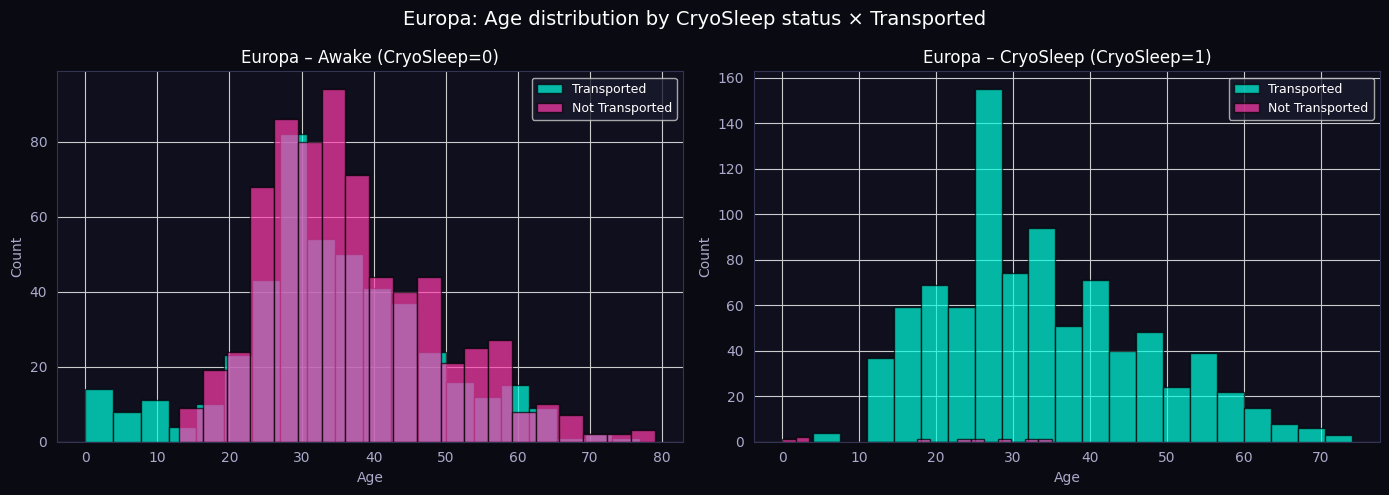

In [ ]:
europa_df = train_raw[train_raw['HomePlanet'] == 'Europa'].copy()

europa_df['CryoSleep_label'] = europa_df['CryoSleep'].map(
    {True: 'CryoSleep', False: 'Awake'}
)
europa_df['Transported_label'] = europa_df['Transported'].map(
    {True: 'Transported', False: 'Not Transported'}
)
europa_df = europa_df.dropna(subset=['Age', 'CryoSleep_label', 'Transported_label'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0a0a12')

for ax, cryo_val, title in zip(
    axes,
    ['Awake', 'CryoSleep'],
    ['Europa – Awake (CryoSleep=0)', 'Europa – CryoSleep (CryoSleep=1)']
):
    ax.set_facecolor('#0f0f1e')
    sub = europa_df[europa_df['CryoSleep_label'] == cryo_val]

    ax.hist(sub[sub['Transported_label'] == 'Transported']['Age'],
            bins=20, color='#00ffe0', alpha=0.7, label='Transported', edgecolor='black')
    ax.hist(sub[sub['Transported_label'] == 'Not Transported']['Age'],
            bins=20, color='#ff3cac', alpha=0.7, label='Not Transported', edgecolor='black')

    ax.set_title(title, color='white', fontsize=12)
    ax.set_xlabel('Age', color='#aaaacc')
    ax.set_ylabel('Count', color='#aaaacc')
    ax.tick_params(colors='#aaaacc')
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.suptitle('Europa: Age distribution by CryoSleep status × Transported', color='white', fontsize=14)
plt.tight_layout()
plt.show()

It is quite possible that the number of people successfully transported to Europe who were not in cryosleep depended on age - the graph shows that the peak was before 30

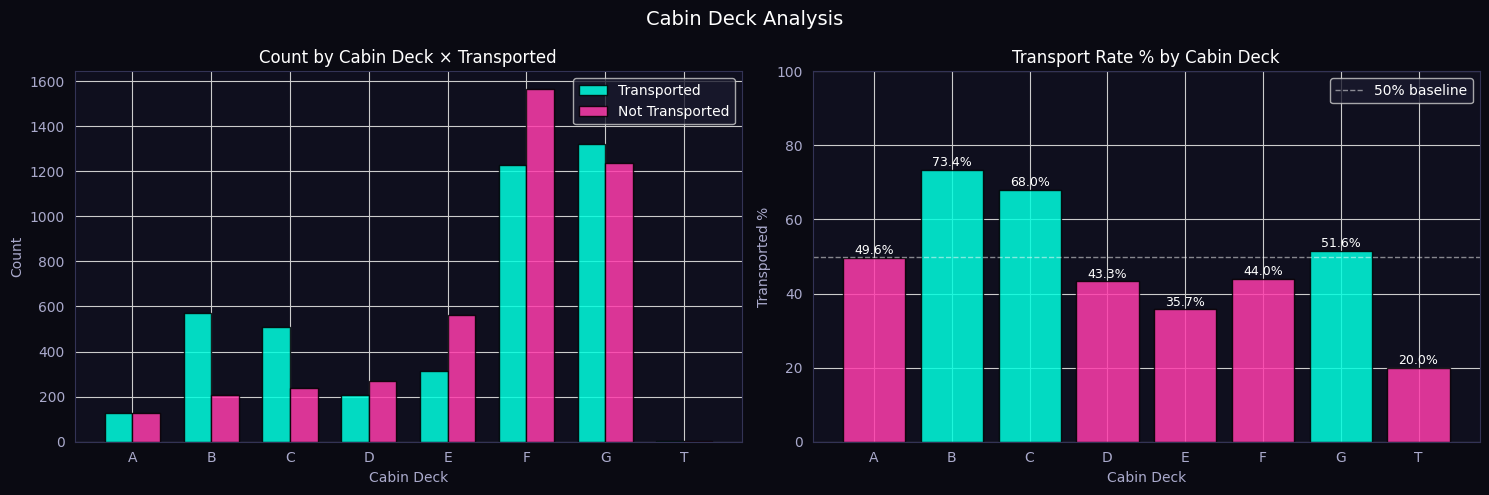

In [ ]:
df = train_raw.copy()
df['cabin_deck'] = df['Cabin'].str[0]
df = df.dropna(subset=['cabin_deck', 'Transported'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='#0a0a12')

decks = sorted(df['cabin_deck'].unique())
x = range(len(decks))
width = 0.35

transported     = [df[(df['cabin_deck']==d) & (df['Transported']==True)].shape[0]  for d in decks]
not_transported = [df[(df['cabin_deck']==d) & (df['Transported']==False)].shape[0] for d in decks]

ax = axes[0]
ax.set_facecolor('#0f0f1e')
bars1 = ax.bar([i - width/2 for i in x], transported,     width, label='Transported',     color='#00ffe0', alpha=0.85, edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], not_transported, width, label='Not Transported', color='#ff3cac', alpha=0.85, edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(decks, color='#aaaacc')
ax.set_title('Count by Cabin Deck × Transported', color='white', fontsize=12)
ax.set_xlabel('Cabin Deck', color='#aaaacc')
ax.set_ylabel('Count',      color='#aaaacc')
ax.tick_params(colors='#aaaacc')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

ax2 = axes[1]
ax2.set_facecolor('#0f0f1e')

rate = [
    df[df['cabin_deck']==d]['Transported'].mean() * 100
    for d in decks
]
colors = ['#00ffe0' if r >= 50 else '#ff3cac' for r in rate]
bars = ax2.bar(decks, rate, color=colors, alpha=0.85, edgecolor='black')

for bar, r in zip(bars, rate):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{r:.1f}%', ha='center', color='white', fontsize=9)

ax2.axhline(50, color='white', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
ax2.set_title('Transport Rate % by Cabin Deck', color='white', fontsize=12)
ax2.set_xlabel('Cabin Deck', color='#aaaacc')
ax2.set_ylabel('Transported %', color='#aaaacc')
ax2.tick_params(colors='#aaaacc')
ax2.set_ylim(0, 100)
ax2.legend(facecolor='#1a1a2e', labelcolor='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333355')

plt.suptitle('Cabin Deck Analysis', color='white', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
stats = df.groupby('cabin_deck')['Transported'].agg(
    Total='count',
    Transported_count=lambda x: x.sum(),
    Transport_rate=lambda x: round(x.mean() * 100, 2)
).reset_index()
print(stats.to_string(index=False))

cabin_deck  Total  Transported_count  Transport_rate
         A    256                127           49.61
         B    779                572           73.43
         C    747                508           68.01
         D    478                207           43.31
         E    876                313           35.73
         F   2794               1229           43.99
         G   2559               1321           51.62
         T      5                  1           20.00


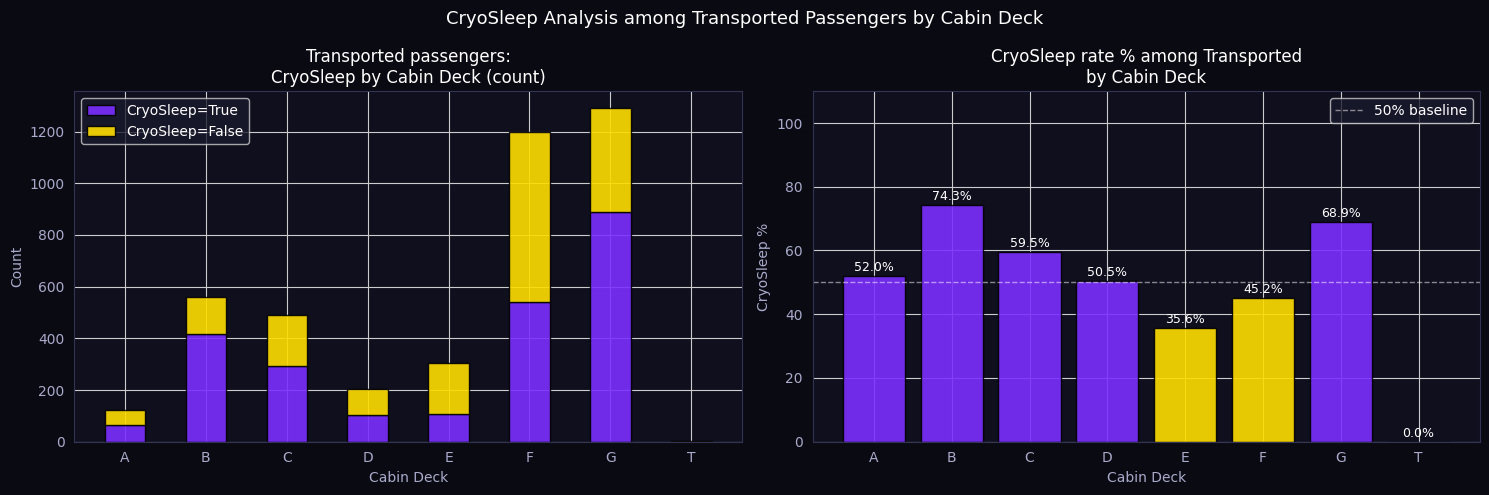

In [ ]:
transported_df = df[df['Transported'] == True]

decks = sorted(transported_df['cabin_deck'].unique())

cryo    = [transported_df[(transported_df['cabin_deck']==d) & (transported_df['CryoSleep']==True)].shape[0]  for d in decks]
no_cryo = [transported_df[(transported_df['cabin_deck']==d) & (transported_df['CryoSleep']==False)].shape[0] for d in decks]
cryo_rate = [c/(c+n)*100 if (c+n) > 0 else 0 for c, n in zip(cryo, no_cryo)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='#0a0a12')

ax = axes[0]
ax.set_facecolor('#0f0f1e')
x = range(len(decks))
width = 0.5

ax.bar(x, cryo,    width, label='CryoSleep=True',  color='#7b2fff', alpha=0.9, edgecolor='black')
ax.bar(x, no_cryo, width, label='CryoSleep=False', color='#ffdd00', alpha=0.9, edgecolor='black',
       bottom=cryo)

ax.set_xticks(list(x))
ax.set_xticklabels(decks, color='#aaaacc')
ax.set_title('Transported passengers:\nCryoSleep by Cabin Deck (count)', color='white', fontsize=12)
ax.set_xlabel('Cabin Deck', color='#aaaacc')
ax.set_ylabel('Count', color='#aaaacc')
ax.tick_params(colors='#aaaacc')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')
ax2 = axes[1]
ax2.set_facecolor('#0f0f1e')

colors = ['#7b2fff' if r >= 50 else '#ffdd00' for r in cryo_rate]
bars = ax2.bar(decks, cryo_rate, color=colors, alpha=0.9, edgecolor='black')

for bar, r in zip(bars, cryo_rate):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{r:.1f}%', ha='center', color='white', fontsize=9)

ax2.axhline(50, color='white', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
ax2.set_title('CryoSleep rate % among Transported\nby Cabin Deck', color='white', fontsize=12)
ax2.set_xlabel('Cabin Deck', color='#aaaacc')
ax2.set_ylabel('CryoSleep %', color='#aaaacc')
ax2.tick_params(colors='#aaaacc')
ax2.set_ylim(0, 110)
ax2.legend(facecolor='#1a1a2e', labelcolor='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#333355')

plt.suptitle('CryoSleep Analysis among Transported Passengers by Cabin Deck',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
stats = transported_df.groupby('cabin_deck')['CryoSleep'].agg(
    Total='count',
    CryoSleep_count=lambda x: x.sum(),
    CryoSleep_rate=lambda x: round(x.mean() * 100, 2)
).reset_index()
print(stats.to_string(index=False))

cabin_deck  Total CryoSleep_count  CryoSleep_rate
         A    123              64           52.03
         B    560             416           74.29
         C    491             292           59.47
         D    204             103           50.49
         E    306             109           35.62
         F   1199             542           45.20
         G   1292             890           68.89
         T      1           False            0.00


We can see that in almost all cabins, the majority of those transported were in cryosleep

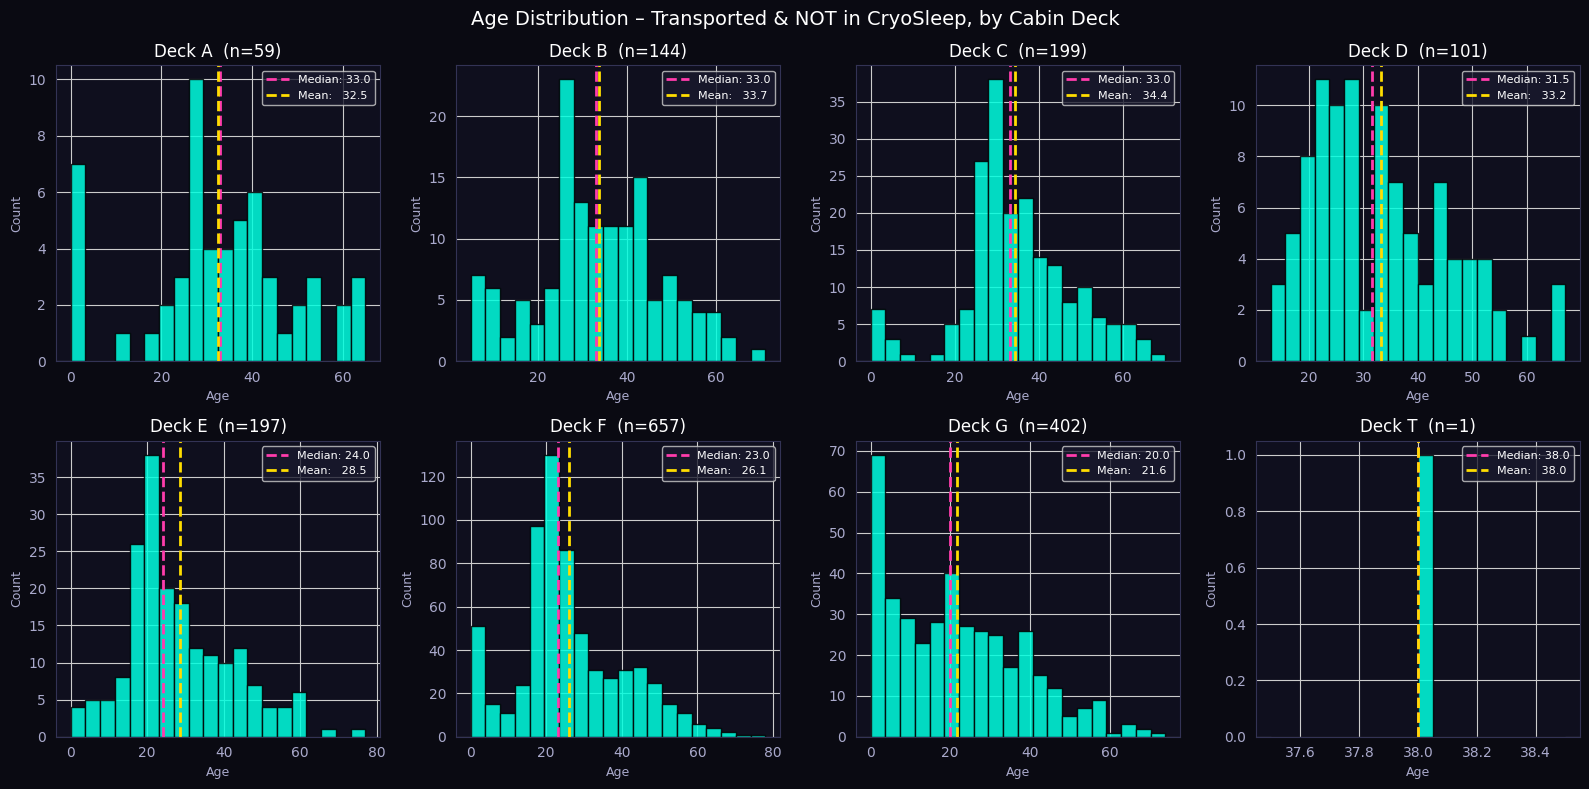

In [ ]:
sub = df[(df['Transported'] == True) & (df['CryoSleep'] == False)]

decks = sorted(sub['cabin_deck'].unique())
n_decks = len(decks)
cols = 4
rows = (n_decks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), facecolor='#0a0a12')
axes = axes.flatten()

for i, deck in enumerate(decks):
    ax = axes[i]
    ax.set_facecolor('#0f0f1e')
    ages = sub[sub['cabin_deck'] == deck]['Age']

    ax.hist(ages, bins=20, color='#00ffe0', alpha=0.85, edgecolor='black')
    ax.axvline(ages.median(), color='#ff3cac', linestyle='--', linewidth=2,
               label=f'Median: {ages.median():.1f}')
    ax.axvline(ages.mean(),   color='#ffdd00', linestyle='--', linewidth=2,
               label=f'Mean:   {ages.mean():.1f}')

    ax.set_title(f'Deck {deck}  (n={len(ages)})', color='white', fontsize=12)
    ax.set_xlabel('Age', color='#aaaacc', fontsize=9)
    ax.set_ylabel('Count', color='#aaaacc', fontsize=9)
    ax.tick_params(colors='#aaaacc')
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Age Distribution – Transported & NOT in CryoSleep, by Cabin Deck',
             color='white', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print(sub.groupby('cabin_deck')['Age']
        .agg(n='count', mean=lambda x: round(x.mean(),1),
             median=lambda x: round(x.median(),1),
             std=lambda x: round(x.std(),1))
        .to_string())

              n  mean  median   std
cabin_deck                         
A            57  32.5    33.0  16.6
B           141  33.7    33.0  13.9
C           196  34.4    33.0  13.3
D           100  33.2    31.5  12.5
E           192  28.5    24.0  14.0
F           648  26.1    23.0  14.2
G           399  21.6    20.0  16.6
T             1  38.0    38.0   NaN


In [ ]:
train_raw

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


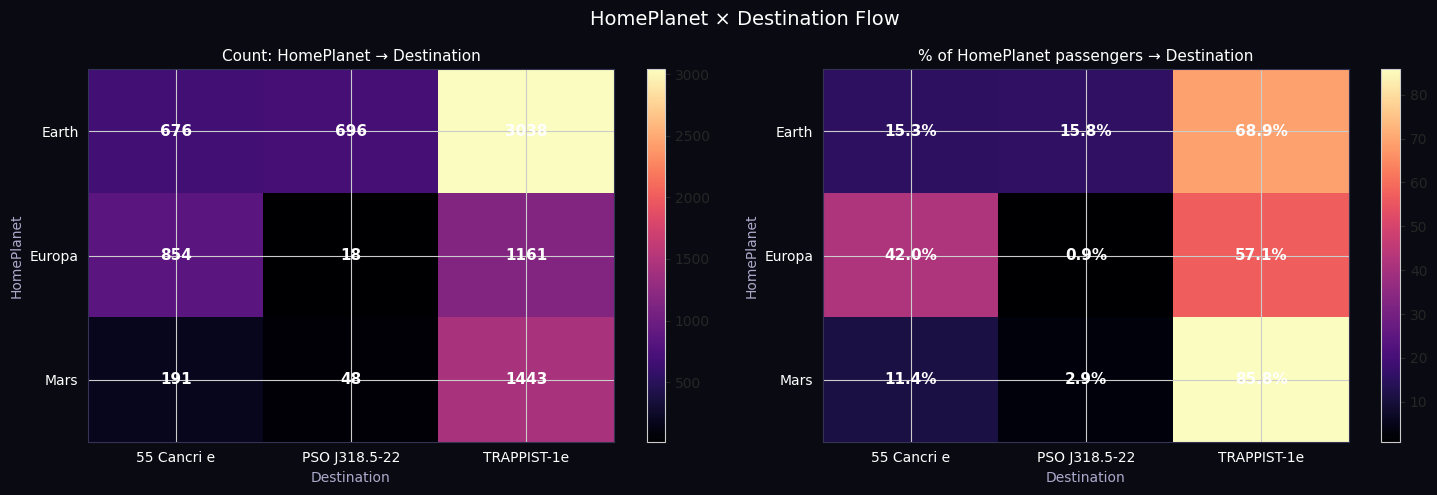

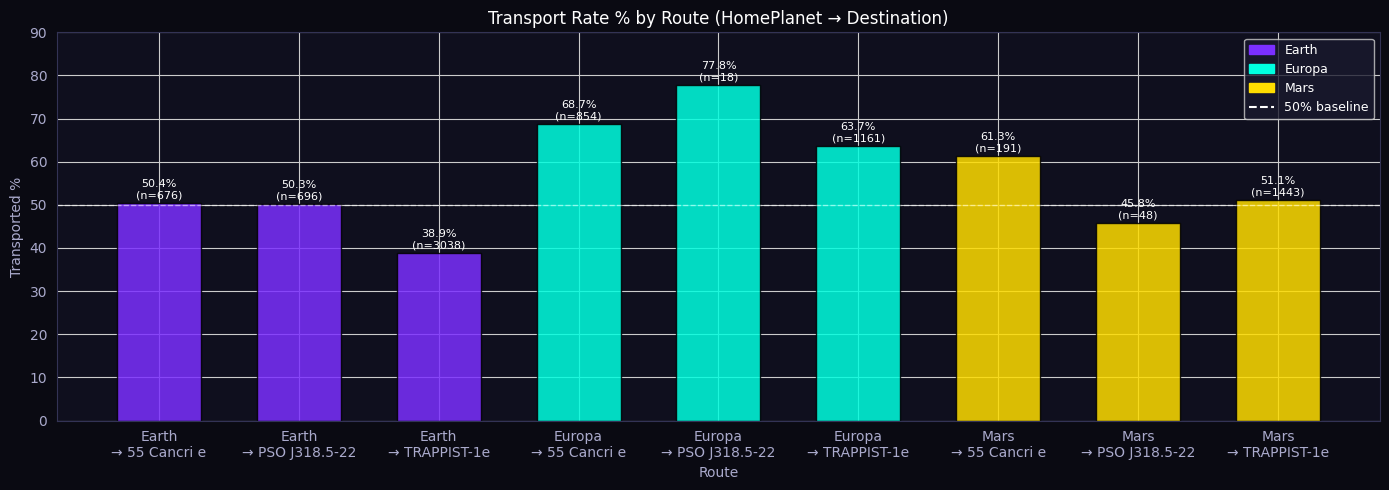

In [ ]:
cross = pd.crosstab(df['HomePlanet'], df['Destination'])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100  # % от планеты

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='#0a0a12')

import numpy as np
for ax, data, title, fmt in zip(
    axes,
    [cross, cross_pct],
    ['Count: HomePlanet → Destination', '% of HomePlanet passengers → Destination'],
    ['.0f', '.1f']
):
    ax.set_facecolor('#0f0f1e')
    im = ax.imshow(data.values, cmap='magma', aspect='auto')

    ax.set_xticks(range(len(data.columns)))
    ax.set_yticks(range(len(data.index)))
    ax.set_xticklabels(data.columns, color='white', fontsize=10)
    ax.set_yticklabels(data.index,   color='white', fontsize=10)
    ax.set_xlabel('Destination', color='#aaaacc')
    ax.set_ylabel('HomePlanet',  color='#aaaacc')
    ax.set_title(title, color='white', fontsize=11)

    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            label = f'{val:{fmt}}' + ('' if fmt == '.0f' else '%')
            ax.text(j, i, label, ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.suptitle('HomePlanet × Destination Flow', color='white', fontsize=14)
plt.tight_layout()
plt.show()

route_df = df.groupby(['HomePlanet', 'Destination'])['Transported'].agg(
    n='count',
    transported_rate=lambda x: round(x.mean() * 100, 1)
).reset_index()
route_df['route'] = route_df['HomePlanet'] + '\n→ ' + route_df['Destination']

fig2, ax2 = plt.subplots(figsize=(14, 5), facecolor='#0a0a12')
ax2.set_facecolor('#0f0f1e')

colors_map = {'Earth': '#7b2fff', 'Europa': '#00ffe0', 'Mars': '#ffdd00'}
bar_colors = [colors_map[r.split('\n')[0]] for r in route_df['route']]

bars = ax2.bar(route_df['route'], route_df['transported_rate'],
               color=bar_colors, alpha=0.85, edgecolor='black', width=0.6)

for bar, row in zip(bars, route_df.itertuples()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{row.transported_rate}%\n(n={row.n})',
             ha='center', color='white', fontsize=8)

ax2.axhline(50, color='white', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
ax2.set_ylabel('Transported %', color='#aaaacc')
ax2.set_xlabel('Route', color='#aaaacc')
ax2.set_title('Transport Rate % by Route (HomePlanet → Destination)', color='white', fontsize=12)
ax2.tick_params(colors='#aaaacc')
ax2.set_ylim(0, 90)
ax2.set_ylim(0, 90)

from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=p) for p, c in colors_map.items()]
legend_els.append(plt.Line2D([0],[0], color='white', linestyle='--', label='50% baseline'))
ax2.legend(handles=legend_els, facecolor='#1a1a2e', labelcolor='white', fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()


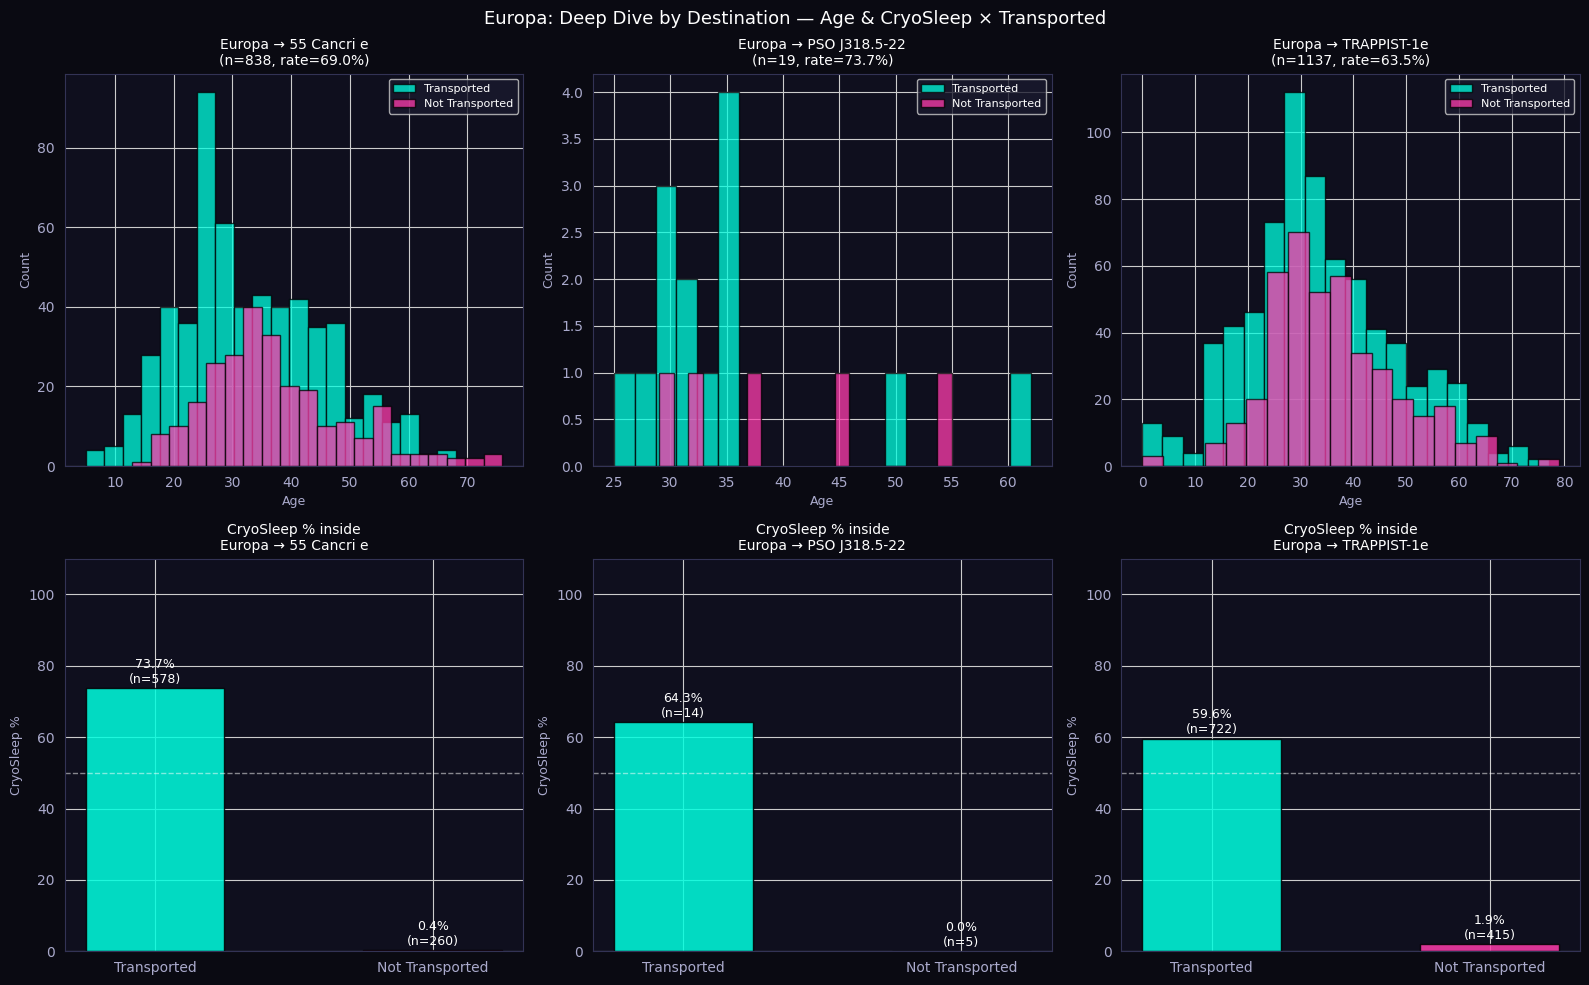

In [ ]:
europa = df[df['HomePlanet'] == 'Europa'].copy()
dests  = sorted(europa['Destination'].unique())

colors_dest = {'55 Cancri e': '#ff3cac', 'PSO J318.5-22': '#ffdd00', 'TRAPPIST-1e': '#00ffe0'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor='#0a0a12')

for ax, dest in zip(axes[0], dests):
    ax.set_facecolor('#0f0f1e')
    sub = europa[europa['Destination'] == dest]
    n_total = len(sub)
    rate    = sub['Transported'].mean() * 100

    ax.hist(sub[sub['Transported'] == True]['Age'],  bins=20,
            color='#00ffe0', alpha=0.75, label='Transported',     edgecolor='black')
    ax.hist(sub[sub['Transported'] == False]['Age'], bins=20,
            color='#ff3cac', alpha=0.75, label='Not Transported', edgecolor='black')

    ax.set_title(f'Europa → {dest}\n(n={n_total}, rate={rate:.1f}%)',
                 color='white', fontsize=10)
    ax.set_xlabel('Age', color='#aaaacc', fontsize=9)
    ax.set_ylabel('Count', color='#aaaacc', fontsize=9)
    ax.tick_params(colors='#aaaacc')
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

for ax, dest in zip(axes[1], dests):
    ax.set_facecolor('#0f0f1e')
    sub = europa[europa['Destination'] == dest]

    groups   = ['Transported', 'Not Transported']
    cryo_rates = [
        sub[sub['Transported'] == True]['CryoSleep'].mean()  * 100,
        sub[sub['Transported'] == False]['CryoSleep'].mean() * 100,
    ]
    counts = [
        sub[sub['Transported'] == True].shape[0],
        sub[sub['Transported'] == False].shape[0],
    ]

    bars = ax.bar(groups, cryo_rates,
                  color=['#00ffe0', '#ff3cac'], alpha=0.85, edgecolor='black', width=0.5)
    for bar, rate, n in zip(bars, cryo_rates, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{rate:.1f}%\n(n={n})', ha='center', color='white', fontsize=9)

    ax.axhline(50, color='white', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f'CryoSleep % inside\nEuropa → {dest}',
                 color='white', fontsize=10)
    ax.set_ylabel('CryoSleep %', color='#aaaacc', fontsize=9)
    ax.set_ylim(0, 110)
    ax.tick_params(colors='#aaaacc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.suptitle('Europa: Deep Dive by Destination — Age & CryoSleep × Transported',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
melted = train[spend_cols + ['Transported']].melt(
    id_vars='Transported', var_name='Service', value_name='Amount')
melted = melted[melted['Amount'] < melted['Amount'].quantile(0.95)]

fig4 = px.violin(melted, x='Service', y='Amount', color='Transported',
                 box=True, points=False,
                 color_discrete_map={True: 'cyan', False: 'hotpink'})
fig4.update_layout(
    paper_bgcolor='#0a0a12', plot_bgcolor='#0f0f1e',
    font=dict(family='monospace', color='#ccc'),
    title=dict(text='Распределение трат по сервисам',
               font=dict(size=15, color='#fff'), x=0.5),
    xaxis=dict(gridcolor='rgba(80,60,180,0.15)', tickfont=dict(color='#555577')),
    yaxis=dict(gridcolor='rgba(80,60,180,0.15)', tickfont=dict(color='#555577')),
    legend=dict(bgcolor='rgba(15,15,30,0.8)', bordercolor='#2a2a4a', borderwidth=1),
    margin=dict(l=50, r=30, t=60, b=50)
)
fig4.show()

Passengers who spent money were less likely to be transported. This is directly related to CryoSleep.

Normal distribution, but there are outliers

## Model Selection
1. **Random Forest Classifier** robust to outliers and works well with overfitting - due to the randomness in the selection of each feature and the data of each tree.
2. **XGBoost Classifier** It's similar to Random Forest - it's also an ensemble model, but with a different approach that can show different results.
3. **LightGBM Classifier** similar to XGBoost, but faster.
4. **Logistic Regression** the most basic classifier with linear dependencies, which will help compare the performance of ensemble and linear models for this dataset

## Dataset Preparation

In [ ]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['cabin_cluster'] = df['Cabin'].str[0]

    df = df.drop(columns=['PassengerId', 'Name', 'Cabin'])

    for col in ['CryoSleep', 'VIP']:
        df[col] = df[col].map({False: 0, True: 1})

    return df

cabin_cluster encodes the deck letter of a passenger's cabin (A–T).
Cabin deck is strongly associated with the HomePlanet and with which part of the ship
a passenger was in, both of which are correlated with the Transported outcome.

In [ ]:
train_raw = pd.read_csv("train.csv")
test_raw  = pd.read_csv("test.csv")

In [ ]:
spaceship_train_df, spaceship_holdout_df = train_test_split(train_raw, test_size=0.2, random_state=42)

In [ ]:
spaceship_train_fe = engineer_features(spaceship_train_df)
spaceship_holdout_fe = engineer_features(spaceship_holdout_df)
test_fe = engineer_features(test_raw)

In [ ]:
print("cabin_cluster value counts:")
print(spaceship_train_fe['cabin_cluster'].value_counts())
spaceship_train_fe.head()

cabin_cluster value counts:
cabin_cluster
F    2242
G    2057
E     688
B     627
C     599
D     379
A     199
T       5
Name: count, dtype: int64


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,cabin_cluster
2333,Earth,0.0,TRAPPIST-1e,28.0,0.0,0.0,55.0,0.0,656.0,0.0,False,NaN
2589,Earth,0.0,TRAPPIST-1e,17.0,0.0,0.0,1195.0,31.0,0.0,0.0,False,F
8302,Europa,1.0,55 Cancri e,28.0,0.0,0.0,0.0,0.0,0.0,0.0,True,C
8177,Mars,0.0,TRAPPIST-1e,20.0,0.0,NaN,2.0,289.0,976.0,0.0,True,F
500,Europa,1.0,55 Cancri e,36.0,0.0,0.0,0.0,0.0,0.0,0.0,True,C


## Utils

In [ ]:
def plot_roc_curve_from_probabilities(y_true, y_prob_pred, pos_label=1, estimator_name=None, **kwargs):
    RocCurveDisplay.from_predictions(
        y_true=y_true, y_pred=y_prob_pred, pos_label=pos_label,
        plot_chance_level=True,
        name=estimator_name if estimator_name is not None else 'Model',
        **kwargs)
    plt.show()

In [ ]:
def plot_roc_curve_from_estimator(X, y, estimator, pos_label=1, estimator_name=None, **kwargs):
    RocCurveDisplay.from_estimator(
        estimator=estimator, X=X, y=y,
        name=estimator_name if estimator_name is not None else estimator.__class__.__name__,
        pos_label=pos_label, plot_chance_level=True, **kwargs)
    plt.show()

In [ ]:
def plot_roc_curve_from_cv(estimator, X, y, n_splits=5, pos_label=1, estimator_name=None, random_state=None):
    stratified_k_fold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
    interp_tprs = []
    auc_score_list = []
    mean_fpr = np.linspace(0, 1, 100)

    for i, (train_index, test_index) in enumerate(stratified_k_fold.split(X=X, y=y)):
        print(f"{estimator_name} - Fold {i + 1}:")
        X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        estimator.fit(X=X_train, y=y_train)
        y_hat_proba = estimator.predict_proba(X=X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_true=y_test, y_score=y_hat_proba, pos_label=pos_label)
        roc_auc_scr = roc_auc_score(y_true=y_test, y_score=y_hat_proba)

        RocCurveDisplay(fpr=fpr, tpr=tpr).plot(
            ax=ax, name=f'{estimator_name} - Fold {i + 1} (AUC = {roc_auc_scr:.5f})', alpha=.7)

        interp_tpr = np.interp(x=mean_fpr, xp=fpr, fp=tpr)
        interp_tpr[0] = 0.0
        interp_tprs.append(interp_tpr)
        auc_score_list.append(roc_auc_scr)

    mean_tpr = np.mean(interp_tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(auc_score_list)

    RocCurveDisplay(fpr=mean_fpr, tpr=mean_tpr).plot(
        ax=ax,
        name=fr"{estimator_name} - Mean ROC (AUC = {mean_auc:.5f} $\pm$ {std_auc:.5f})",
        lw=2, alpha=1, linestyle='--', color='black', plot_chance_level=True)
    plt.show()

In [ ]:
def plot_precision_recall_curve_from_probabilities(y_true, y_prob_pred, pos_label=1, estimator_name=None, **kwargs):
    PrecisionRecallDisplay.from_predictions(
        y_true=y_true, y_pred=y_prob_pred, pos_label=pos_label,
        plot_chance_level=True,
        name=estimator_name if estimator_name is not None else 'Model',
        **kwargs)
    plt.show()

In [ ]:
def plot_precision_recall_curve_from_estimator(X, y, estimator, estimator_name=None, **kwargs):
    PrecisionRecallDisplay.from_estimator(
        estimator=estimator, X=X, y=y,
        name=estimator_name if estimator_name is not None else estimator.__class__.__name__,
        plot_chance_level=True, **kwargs)
    plt.show()

In [ ]:
def plot_pr_curve_from_cv(estimator, X, y, n_splits=5, pos_label=1, estimator_name=None, random_state=None):
    stratified_k_fold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
    ap_scores = []
    y_real = []
    y_proba = []

    for i, (train_index, test_index) in enumerate(stratified_k_fold.split(X=X, y=y)):
        print(f"{estimator_name} - Fold {i + 1}:")
        X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        estimator.fit(X=X_train, y=y_train)
        y_hat_proba = estimator.predict_proba(X=X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_true=y_test, y_score=y_hat_proba, pos_label=pos_label)
        ap_score = average_precision_score(y_true=y_test, y_score=y_hat_proba, pos_label=pos_label)

        PrecisionRecallDisplay(precision=precision, recall=recall, pos_label=pos_label).plot(
            ax=ax, name=f'{estimator_name} - Fold {i + 1} (AP = {ap_score:.5f})', alpha=.7)

        ap_scores.append(ap_score)
        y_real.append(y_test)
        y_proba.append(y_hat_proba)

    mean_ap = np.mean(ap_scores)
    std_ap = np.std(ap_scores)
    y_real = np.concatenate(y_real)
    y_proba = np.concatenate(y_proba)
    precision, recall, _ = precision_recall_curve(y_real, y_proba)
    class_count = Counter(y)
    prevalence_pos_label_param = class_count[pos_label] / sum(class_count.values())

    PrecisionRecallDisplay(precision=precision, recall=recall, pos_label=pos_label,
                           prevalence_pos_label=prevalence_pos_label_param).plot(
        ax=ax,
        name=fr'{estimator_name} - Mean PR (AP = {mean_ap:.5f} $\pm$ {std_ap:.5f})',
        alpha=.7, plot_chance_level=True, linestyle='--', color='black')
    plt.show()

In [ ]:
def print_classification_report(model_name, y_true, y_pred, modifiers):
    print(f'{model_name} - {modifiers} - Accuracy Score: {accuracy_score(y_true=y_true, y_pred=y_pred)}')
    print(classification_report(y_true=y_true, y_pred=y_pred, digits=5))

In [ ]:
def plot_confusion_matrix(model_name, y_true, y_pred, modifiers):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{model_name} Classification Report - {modifiers}')
    plt.grid(False)
    plt.show()

In [ ]:
def create_pipeline(steps: list[tuple[str, BaseEstimator]]) -> Pipeline:
    return Pipeline(steps=steps).set_output(transform='pandas')

In [ ]:
model_performance_df: pd.DataFrame = pd.DataFrame(columns=['Score'])
model_performance_df.index = pd.MultiIndex.from_product(iterables=[[], []], names=['Model', 'Metric'])

In [ ]:
def compute_model_info_metrics(y_true, y_pred, y_pred_proba, estimator_name) -> dict:
    return {
        'Model_Name': estimator_name,
        'Model_Metrics': {
            'Accuracy': accuracy_score(y_true=y_true, y_pred=y_pred),
            'Precision (0)': precision_score(y_true=y_true, y_pred=y_pred, pos_label=0),
            'Recall (0)': recall_score(y_true=y_true, y_pred=y_pred, pos_label=0),
            'F1 Score (0)': f1_score(y_true=y_true, y_pred=y_pred, pos_label=0),
            'Precision (1)': precision_score(y_true=y_true, y_pred=y_pred, pos_label=1),
            'Recall (1)': recall_score(y_true=y_true, y_pred=y_pred, pos_label=1),
            'F1 Score (1)': f1_score(y_true=y_true, y_pred=y_pred, pos_label=1),
            'ROC AUC Score': roc_auc_score(y_true=y_true, y_score=y_pred_proba),
            'PR AUC Score': average_precision_score(y_true=y_true, y_score=y_pred_proba),
        }
    }

In [ ]:
def add_to_df(metrics_dict, estimator_name, old_df) -> pd.DataFrame:
    df_copy = old_df.copy()
    index_iterables = [[estimator_name], list(metrics_dict.keys())]
    new_multi_index = pd.MultiIndex.from_product(iterables=index_iterables, names=['Model', 'Metric'])
    new_scores = pd.DataFrame({'Score': list(metrics_dict.values())}, index=new_multi_index)
    return pd.concat([df_copy, new_scores])

In [ ]:
def plot_metrics(metrics_df) -> None:
    metrics = metrics_df.index.get_level_values("Metric").unique()
    models = metrics_df.index.get_level_values("Model").unique()
    n_metrics = len(metrics)

    colors = ['red', 'orange', 'yellow', 'blue', 'black']
    color_map = dict(zip(models, colors))
    print(color_map)

    ncols = 3
    nrows = (n_metrics + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows), sharex=True)
    axes = axes.flatten()

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        ax.set_title(metric)
        for model in models:
            score = metrics_df.loc[(model, metric), "Score"]
            color = color_map[model]
            ax.hlines(y=score, xmin=0, xmax=1, label=model, color=color)
            ax.text(1.02, score, f"{score:.3f}", va='center', fontsize=8)
        ax.set_xlim(0, 1)
        ax.tick_params(left=True, labelleft=True)
        ax.grid(True)

    fig.suptitle("Model Comparison by Metric", fontsize=16)
    fig.supylabel("Score", fontsize=12)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

In [ ]:
scoring_dict: dict = {
    'Accuracy': make_scorer(accuracy_score, greater_is_better=True),
    'Precision (0)': make_scorer(precision_score, pos_label=0, greater_is_better=True),
    'Recall (0)': make_scorer(recall_score, pos_label=0, greater_is_better=True),
    'F1 Score (0)': make_scorer(f1_score, pos_label=0, greater_is_better=True),
    'Precision (1)': make_scorer(precision_score, pos_label=1, greater_is_better=True),
    'Recall (1)': make_scorer(recall_score, pos_label=1, greater_is_better=True),
    'F1 Score (1)': make_scorer(f1_score, pos_label=1, greater_is_better=True),
    'ROC AUC Score': make_scorer(roc_auc_score, response_method='predict_proba', greater_is_better=True),
    'PR AUC Score': make_scorer(average_precision_score, response_method='predict_proba', greater_is_better=True),
}

In [ ]:
def calculate_preds_metrics(X_train_cv, y_train_cv, cv_alg, estimator, modifiers, estimator_name=None):
    all_y_true = []
    all_y_pred = []
    all_y_pred_proba = []
    all_metrics = []

    for i, (train_index, test_index) in enumerate(cv_alg.split(X=X_train_cv, y=y_train_cv)):
        print(f'{estimator_name} ({modifiers}) - Fold {i + 1}:')
        X_train_fold = X_train_cv.iloc[train_index, :]
        X_test_fold  = X_train_cv.iloc[test_index, :]
        y_train_fold = y_train_cv.iloc[train_index]
        y_test_fold  = y_train_cv.iloc[test_index]

        estimator.fit(X=X_train_fold, y=y_train_fold)

        y_fold_pred_proba = pd.Series(estimator.predict_proba(X_test_fold)[:, 1], index=y_test_fold.index)
        y_fold_pred = pd.Series(estimator.predict(X_test_fold), index=y_test_fold.index)

        model_info_metrics = compute_model_info_metrics(
            y_true=y_test_fold, y_pred=y_fold_pred, y_pred_proba=y_fold_pred_proba,
            estimator_name=f'{estimator_name} ({modifiers}) | Fold {i + 1}')

        all_y_pred.append(y_fold_pred)
        all_y_pred_proba.append(y_fold_pred_proba)
        all_y_true.append(y_test_fold)
        all_metrics.append(model_info_metrics)

    all_y_true        = pd.concat(all_y_true).reindex(y_train_cv.index)
    all_y_pred        = pd.concat(all_y_pred).reindex(y_train_cv.index)
    all_y_pred_proba  = pd.concat(all_y_pred_proba).reindex(y_train_cv.index)

    return (all_y_true, all_y_pred, all_y_pred_proba, all_metrics)

In [ ]:
def calculate_mean_metrics_cv(all_metrics) -> dict:
    metric_lists = defaultdict(list)
    for fold_metric_dict in all_metrics:
        for key, value in fold_metric_dict['Model_Metrics'].items():
            metric_lists[key].append(value)
    return {
        'Model_Name': all_metrics[0].get('Model_Name').split(' | ')[0] + ' - CV',
        'Model_Metrics': {metric: np.mean(values) for metric, values in metric_lists.items()}
    }

Baseline

In [ ]:
numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'VIP']
categorical_ohe_features = ['HomePlanet', 'Destination']   # 3 и 3 уникальных значения → OHE
categorical_ord_features = ['cabin_cluster']

In [ ]:
median_imputer = SimpleImputer(strategy='median').set_output(transform='pandas')
cat_imputer_bp = SimpleImputer(strategy='most_frequent').set_output(transform='pandas')

In [ ]:
ohe_bp = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
ordinal_encoder_bp = OrdinalEncoder(
    categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
).set_output(transform='pandas')

In [ ]:
cat_ohe_pipeline_bp = create_pipeline(steps=[
    ('cat_impute', cat_imputer_bp),
    ('ohe', ohe_bp),
])

In [ ]:
cat_ord_pipeline_bp = create_pipeline(steps=[
    ('cat_impute', SimpleImputer(strategy='most_frequent').set_output(transform='pandas')),
    ('ordinal', ordinal_encoder_bp),
])

In [ ]:
preprocessing_bp = ColumnTransformer(
    transformers=[
        ('impute_encode_ohe', cat_ohe_pipeline_bp, categorical_ohe_features),
        ('impute_encode_ord', cat_ord_pipeline_bp, categorical_ord_features),
        ('impute_numerical',  median_imputer,       numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [ ]:
model_names_cv: list[str] = [
    'LightGBM Classifier (BP) - CV',
    'XGBoost Classifier (BP) - CV',
    'Logistic Regression (BP) - CV',
    'Random Forest Classifier (BP) - CV',
]

LightGBM

In [ ]:
lightgbm_classifier = LGBMClassifier(
    n_jobs=-1, random_state=42, verbose=-1,
    objective='binary', metric='average_precision'
)
pipeline_steps = [('preprocessing', preprocessing_bp), ('model', lightgbm_classifier)]
pipeline = create_pipeline(steps=pipeline_steps)

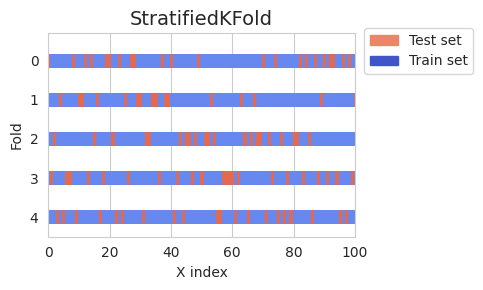

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=1, verbose=2
)

[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    1.2s finished


LightGBM Classifier - Fold 1:
LightGBM Classifier - Fold 2:
LightGBM Classifier - Fold 3:
LightGBM Classifier - Fold 4:
LightGBM Classifier - Fold 5:


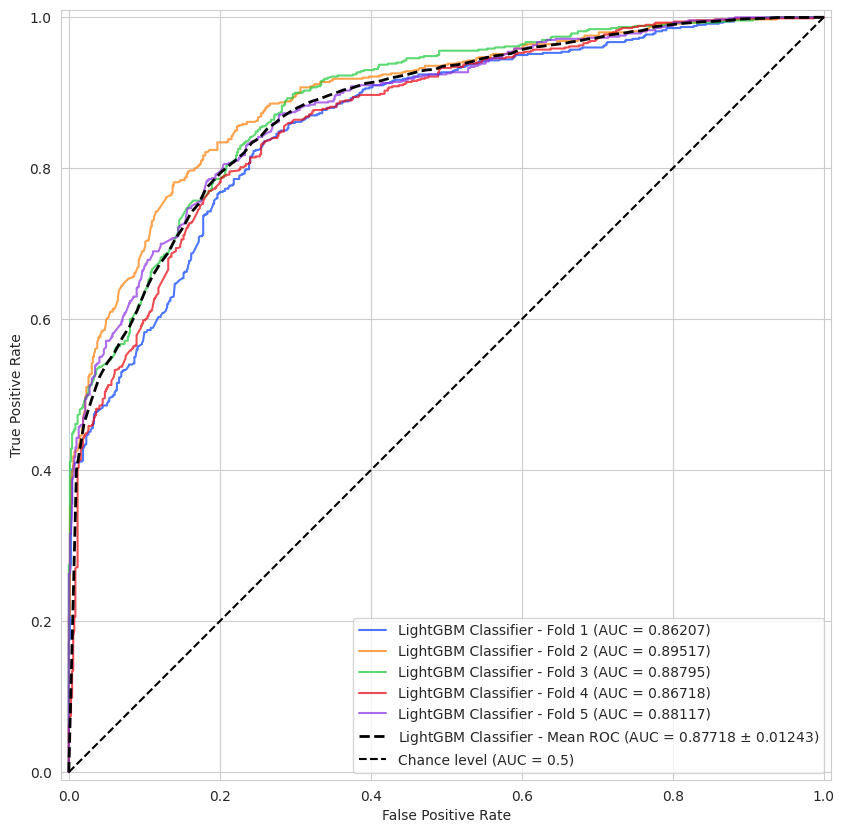

In [ ]:
plot_roc_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                       pos_label=1, random_state=42, estimator_name='LightGBM Classifier')

LightGBM Classifier - Fold 1:
LightGBM Classifier - Fold 2:
LightGBM Classifier - Fold 3:
LightGBM Classifier - Fold 4:
LightGBM Classifier - Fold 5:


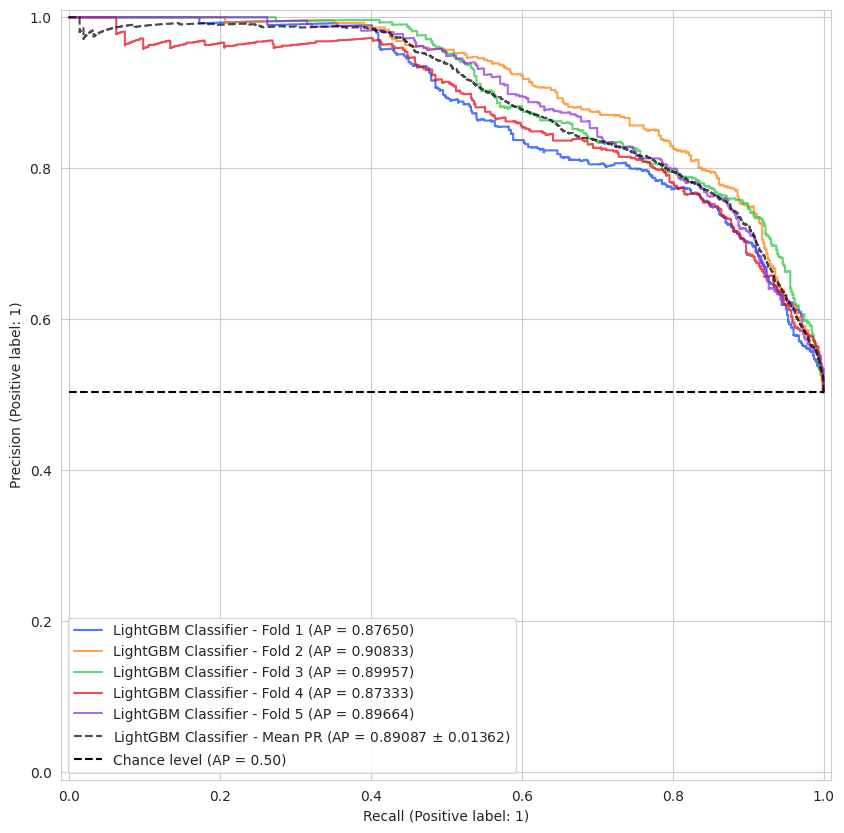

In [ ]:
plot_pr_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                      pos_label=1, random_state=42, estimator_name='LightGBM Classifier')

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='LightGBM Classifier', modifiers='BP'
)

LightGBM Classifier (BP) - Fold 1:
LightGBM Classifier (BP) - Fold 2:
LightGBM Classifier (BP) - Fold 3:
LightGBM Classifier (BP) - Fold 4:
LightGBM Classifier (BP) - Fold 5:


In [ ]:
print_classification_report(model_name='LightGBM Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')

LightGBM Classifier - Baseline Performance - Accuracy Score: 0.7963761863675582
              precision    recall  f1-score   support

           0    0.80748   0.77475   0.79078      3454
           1    0.78626   0.81771   0.80168      3500

    accuracy                        0.79638      6954
   macro avg    0.79687   0.79623   0.79623      6954
weighted avg    0.79680   0.79638   0.79627      6954



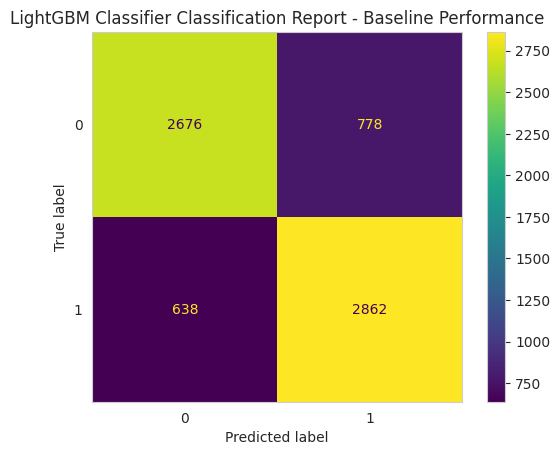

In [ ]:
plot_confusion_matrix(model_name='LightGBM Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='Baseline Performance')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(metrics_dict=mean_metrics['Model_Metrics'],
                                  estimator_name=mean_metrics['Model_Name'],
                                  old_df=model_performance_df)
model_performance_df.xs('LightGBM Classifier (BP) - CV')

,Score
Metric,
Accuracy,0.796376
Precision (0),0.807505
Recall (0),0.774749
F1 Score (0),0.790693
Precision (1),0.786489
Recall (1),0.817714
F1 Score (1),0.801718
ROC AUC Score,0.878708
PR AUC Score,0.890873


LightGBM Classifier - Hold-out - Accuracy Score: 0.7947096032202415
              precision    recall  f1-score   support

           0    0.80508   0.77236   0.78838       861
           1    0.78532   0.81663   0.80067       878

    accuracy                        0.79471      1739
   macro avg    0.79520   0.79449   0.79453      1739
weighted avg    0.79511   0.79471   0.79459      1739



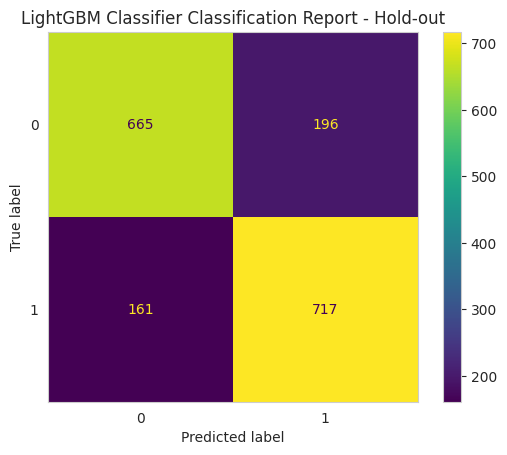

In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)
y_holdout_pred_proba = pipeline.predict_proba(X=X_holdout)[:, 1]
y_holdout_pred = pipeline.predict(X=X_holdout)
print_classification_report(model_name='LightGBM Classifier',
                             y_true=y_holdout, y_pred=y_holdout_pred,
                             modifiers='Hold-out')
plot_confusion_matrix(model_name='LightGBM Classifier',
                      y_true=y_holdout, y_pred=y_holdout_pred,
                      modifiers='Hold-out')

In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)
y_sub = (pipeline.predict_proba(X=X_test_final)[:, 1] >= 0.5).astype(bool)
pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': y_sub}).to_csv(
    'submission_default_bp_lightgbm.csv', index=False)

XGBoost

In [ ]:
xgboost_classifier = XGBClassifier(
    n_jobs=-1, random_state=42, verbosity=0, objective="binary:logistic", eval_metrics="aucpr"
)

In [ ]:
pipeline_steps = [('preprocessing', preprocessing_bp), ('model', xgboost_classifier)]
pipeline = create_pipeline(steps=pipeline_steps)

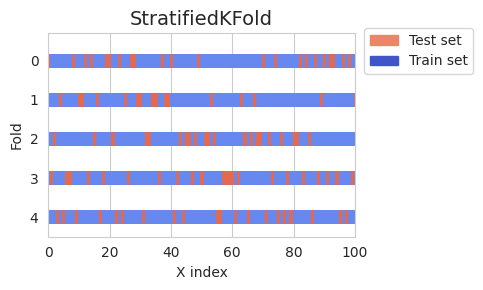

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.5s finished


XGBoost Classifier (BP) - Fold 1:
XGBoost Classifier (BP) - Fold 2:
XGBoost Classifier (BP) - Fold 3:
XGBoost Classifier (BP) - Fold 4:
XGBoost Classifier (BP) - Fold 5:
XGBoost Classifier - Baseline Performance - Accuracy Score: 0.7929249352890423
              precision    recall  f1-score   support

           0    0.79600   0.78402   0.78996      3454
           1    0.78998   0.80171   0.79580      3500

    accuracy                        0.79292      6954
   macro avg    0.79299   0.79287   0.79288      6954
weighted avg    0.79297   0.79292   0.79290      6954



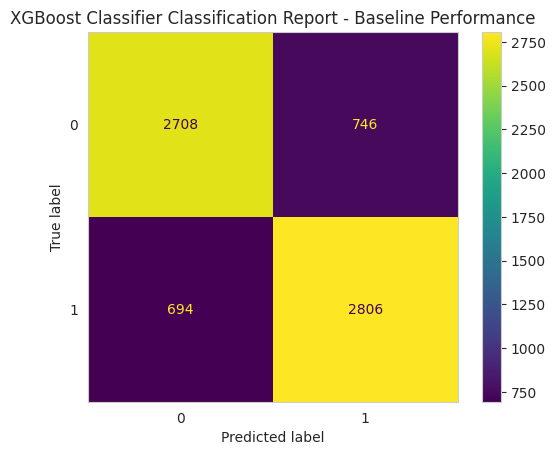

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='XGBoost Classifier', modifiers='BP'
)
print_classification_report(model_name='XGBoost Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')
plot_confusion_matrix(model_name='XGBoost Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='Baseline Performance')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(metrics_dict=mean_metrics['Model_Metrics'],
                                  estimator_name=mean_metrics['Model_Name'],
                                  old_df=model_performance_df)
model_performance_df.xs('XGBoost Classifier (BP) - CV')

,Score
Metric,
Accuracy,0.792925
Precision (0),0.796242
Recall (0),0.784014
F1 Score (0),0.789982
Precision (1),0.790021
Recall (1),0.801714
F1 Score (1),0.795737
ROC AUC Score,0.873637
PR AUC Score,0.886323


In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)
y_sub = (pipeline.predict_proba(X=X_test_final)[:, 1] >= 0.5).astype(bool)
pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': y_sub}).to_csv(
    'submission_default_bp_xgboost.csv', index=False)

Logistic Regression

In [ ]:
logistic_regressor = LogisticRegression(n_jobs=-1, verbose=0, max_iter=1000)
pipeline_steps = [('preprocessing', preprocessing_bp), ('model', logistic_regressor)]
pipeline = create_pipeline(steps=pipeline_steps)

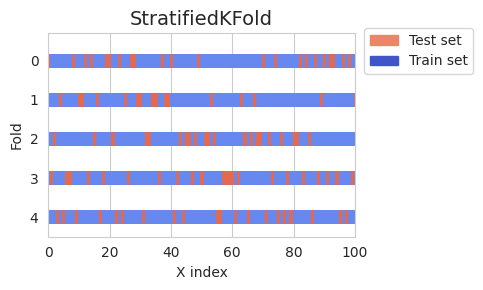

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.2s finished


Logistic Regression (BP) - Fold 1:
Logistic Regression (BP) - Fold 2:
Logistic Regression (BP) - Fold 3:
Logistic Regression (BP) - Fold 4:
Logistic Regression (BP) - Fold 5:
Logistic Regression - Baseline Performance - Accuracy Score: 0.7917745182628703
              precision    recall  f1-score   support

           0    0.80102   0.77273   0.78662      3454
           1    0.78327   0.81057   0.79669      3500

    accuracy                        0.79177      6954
   macro avg    0.79214   0.79165   0.79165      6954
weighted avg    0.79209   0.79177   0.79169      6954



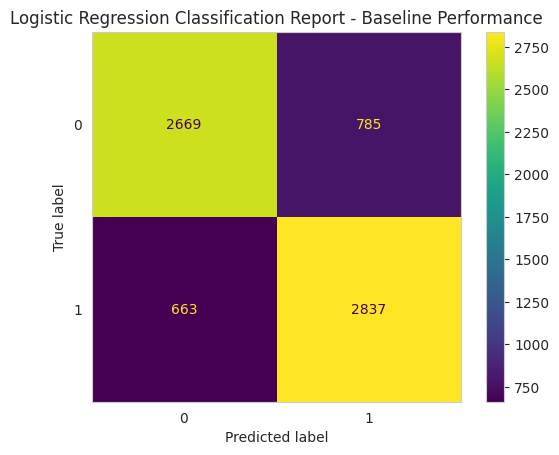

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Logistic Regression', modifiers='BP'
)
print_classification_report(model_name='Logistic Regression',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')
plot_confusion_matrix(model_name='Logistic Regression',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='Baseline Performance')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(metrics_dict=mean_metrics['Model_Metrics'],
                                  estimator_name=mean_metrics['Model_Name'],
                                  old_df=model_performance_df)
model_performance_df.xs('Logistic Regression (BP) - CV')

,Score
Metric,
Accuracy,0.791776
Precision (0),0.801041
Recall (0),0.772730
F1 Score (0),0.786617
Precision (1),0.783288
Recall (1),0.810571
F1 Score (1),0.796684
ROC AUC Score,0.871859
PR AUC Score,0.877038


In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)
y_sub = (pipeline.predict_proba(X=X_test_final)[:, 1] >= 0.5).astype(bool)
pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': y_sub}).to_csv(
    'submission_default_bp_logistic.csv', index=False)

Random Forest

In [ ]:
random_forest_classifier = RandomForestClassifier(n_jobs=-1, random_state=42, verbose=0)
pipeline_steps = [('preprocessing', preprocessing_bp), ('model', random_forest_classifier)]
pipeline = create_pipeline(steps=pipeline_steps)

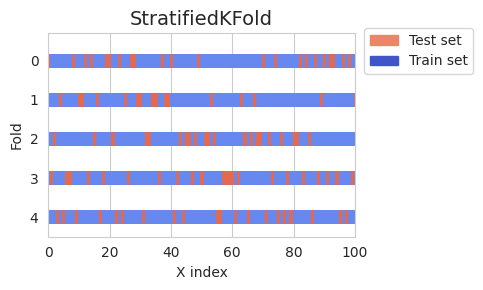

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.7s finished


Random Forest Classifier (BP) - Fold 1:
Random Forest Classifier (BP) - Fold 2:
Random Forest Classifier (BP) - Fold 3:
Random Forest Classifier (BP) - Fold 4:
Random Forest Classifier (BP) - Fold 5:
Random Forest Classifier - Baseline Performance - Accuracy Score: 0.7883232671843543
              precision    recall  f1-score   support

           0    0.78026   0.79878   0.78941      3454
           1    0.79666   0.77800   0.78722      3500

    accuracy                        0.78832      6954
   macro avg    0.78846   0.78839   0.78832      6954
weighted avg    0.78852   0.78832   0.78831      6954



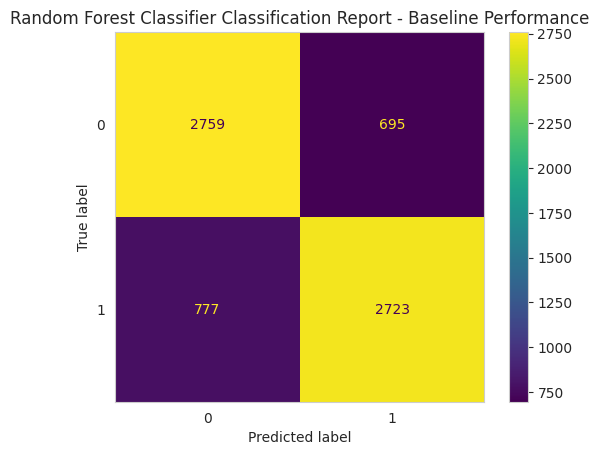

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Random Forest Classifier', modifiers='BP'
)
print_classification_report(model_name='Random Forest Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')
plot_confusion_matrix(model_name='Random Forest Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='Baseline Performance')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(metrics_dict=mean_metrics['Model_Metrics'],
                                  estimator_name=mean_metrics['Model_Name'],
                                  old_df=model_performance_df)
model_performance_df.xs('Random Forest Classifier (BP) - CV')

,Score
Metric,
Accuracy,0.796376
Precision (0),0.807505
Recall (0),0.774749
F1 Score (0),0.790693
Precision (1),0.786489
Recall (1),0.817714
F1 Score (1),0.801718
ROC AUC Score,0.878708
PR AUC Score,0.890873


In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)
y_sub = (pipeline.predict_proba(X=X_test_final)[:, 1] >= 0.5).astype(bool)
pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': y_sub}).to_csv(
    'submission_default_bp_randomforest.csv', index=False)

In [ ]:
def plot_metrics(metrics_df: pd.DataFrame) -> None:
    metrics = metrics_df.index.get_level_values("Metric").unique()
    models = metrics_df.index.get_level_values("Model").unique()
    n_metrics = len(metrics)

    colors = ['red', 'orange', 'yellow', 'blue', 'black']
    color_map = dict(zip(models, colors))
    print(color_map)

    ncols = 3
    nrows = (n_metrics + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows), sharex=True)
    axes = axes.flatten()

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        ax.set_title(metric)

        for model in models:
            score = score = float(metrics_df.loc[(model, metric), "Score"].iloc[0])
            color = color_map[model]

            ax.hlines(y=score, xmin=0, xmax=1, label=model, color=color)
            ax.text(1.02, score, f"{score:.3f}", va='center', fontsize=8)

        ax.set_xlim(0, 1)
        ax.tick_params(left=True, labelleft=True)
        ax.grid(True)

    fig.suptitle("Model Comparison by Metric", fontsize=16)
    fig.supylabel("Score", fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

{'LightGBM Classifier (BP) - CV': 'red', 'XGBoost Classifier (BP) - CV': 'orange', 'Logistic Regression (BP) - CV': 'yellow', 'Random Forest Classifier (BP) - CV': 'blue'}


/tmp/ipykernel_7330/427551743.py:21: PerformanceWarning: indexing past lexsort depth may impact performance.
  score = score = float(metrics_df.loc[(model, metric), "Score"].iloc[0])


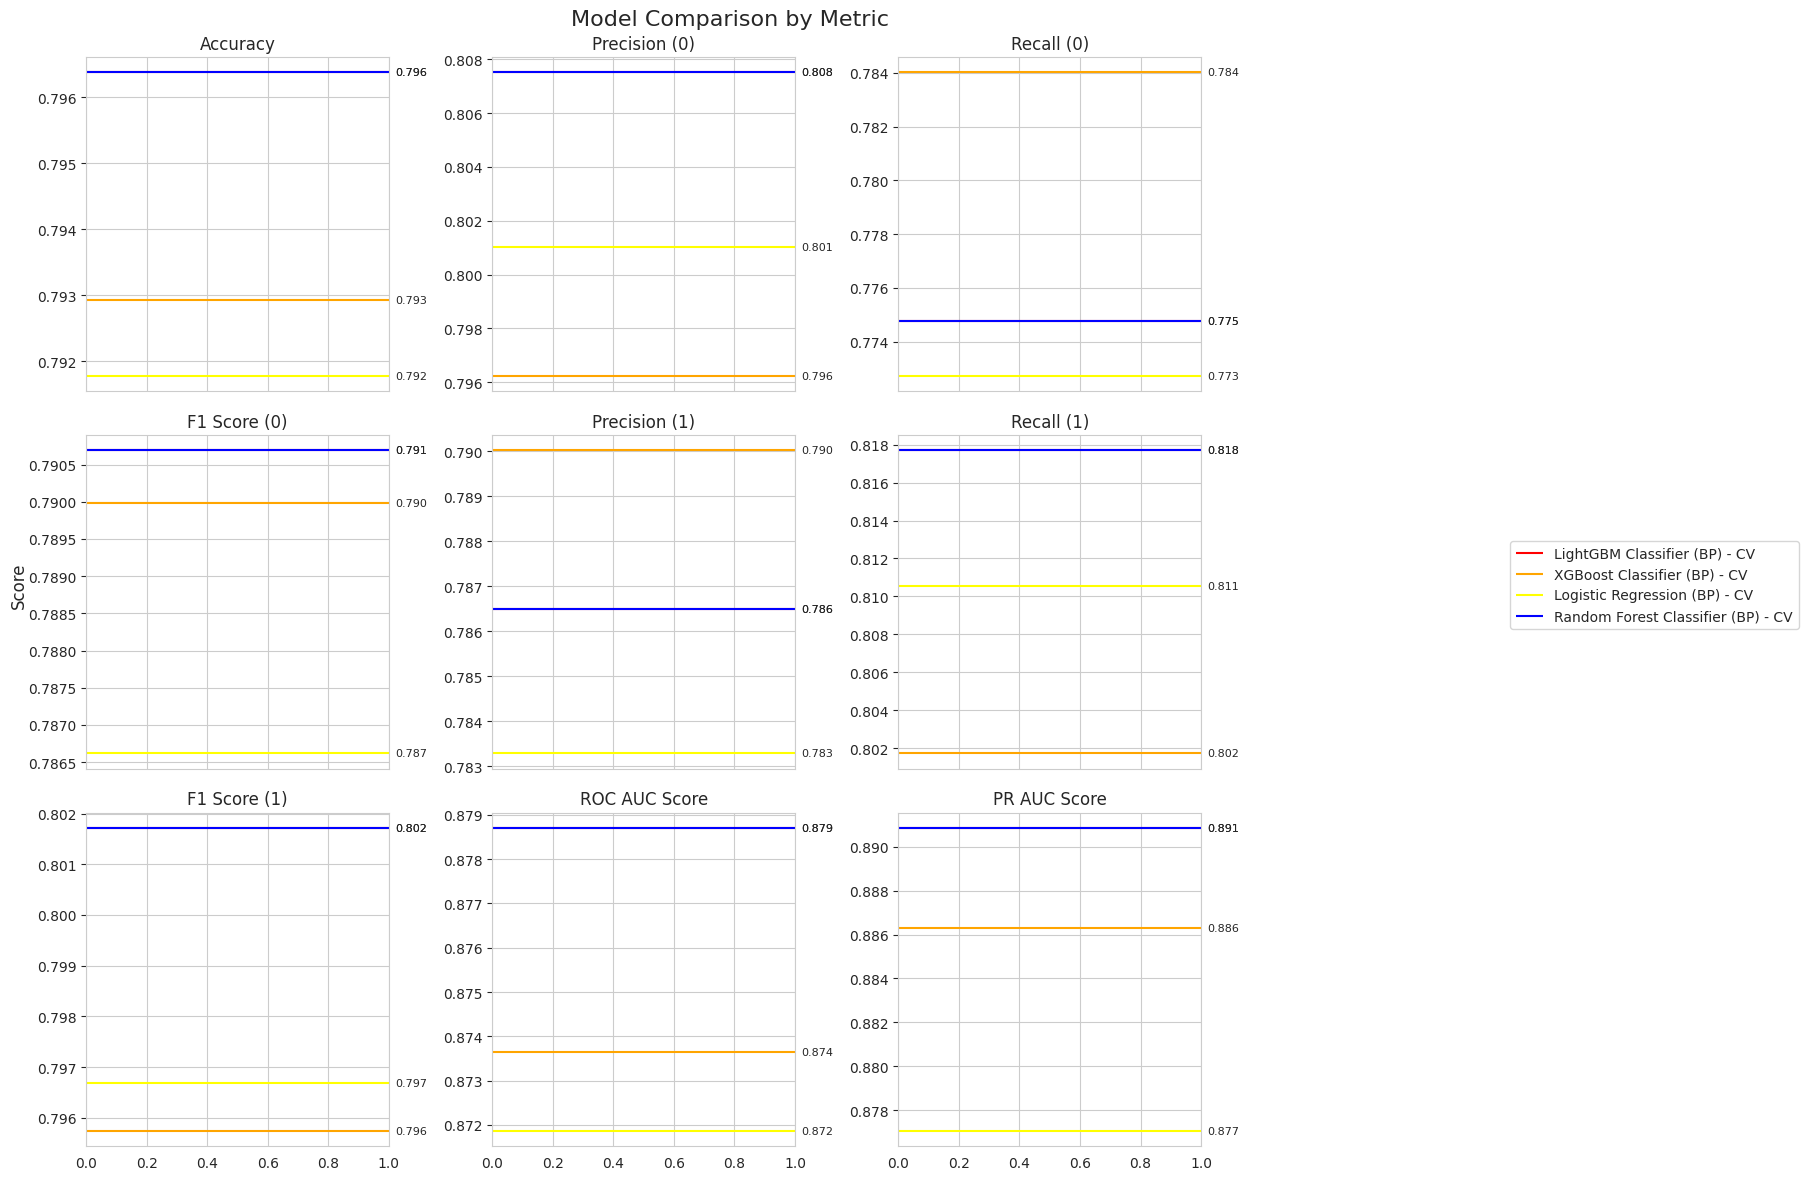

In [ ]:
model_performance_df.loc[model_names_cv]
plot_metrics(metrics_df=model_performance_df.loc[model_names_cv])

MICE Imputer

In [ ]:
categorical_features = ['HomePlanet', 'Destination', 'cabin_cluster']

In [ ]:
mice_imputer = IterativeImputer(random_state=42, max_iter=10, verbose=0).set_output(transform='pandas')

MICE was chosen here because it works well when
there are correlations between features, since it operates on the basis of linear dependencies

In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent').set_output(transform='pandas')

In [ ]:
ohe = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')

In [ ]:
numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'VIP']

cat_impute_encode_pipeline = create_pipeline(steps=[
    ('cat_impute', cat_imputer),
    ('ohe', ohe),
])

In [ ]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        ('impute_encode_categorical', cat_impute_encode_pipeline, categorical_features),
        ('impute_numerical', mice_imputer, numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform='pandas')

This ColumnTransformer applies categorical imputation. It is chosen because it acts as a wrapper



In [ ]:
X_train_cv = spaceship_train_fe.drop(columns=['Transported'])
y_train_cv = spaceship_train_fe['Transported'].map({False: 0, True: 1})
X_holdout = spaceship_holdout_fe.drop(columns=['Transported'])
y_holdout = spaceship_holdout_fe['Transported'].map({False: 0, True: 1})
X_test_final = test_fe

In [ ]:
stratified_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Для бейслайн майс не исп

### KFold visualisation

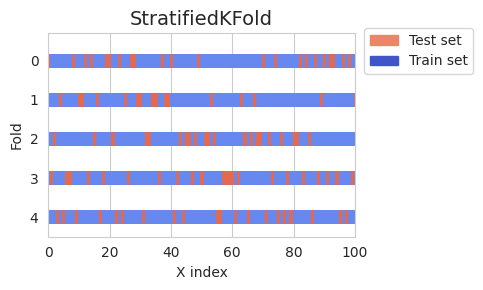

In [ ]:
def plot_skfold(cv, X, y, n_splits, xlim_max=100):
    fig, ax = plt.subplots(figsize=(6, 3))
    cmap_cv = plt.cm.coolwarm
    for i_split, (train_idx, test_idx) in enumerate(cv.split(X=X, y=y)):
        indices = np.full(len(X), np.nan)
        indices[test_idx], indices[train_idx] = 1, 0
        ax_x = range(len(indices))
        ax_y = [i_split + 0.5] * len(indices)
        ax.scatter(ax_x, ax_y, c=indices, marker="_", lw=10, cmap=cmap_cv, vmin=-0.2, vmax=1.2)

    y_ticks = np.arange(n_splits) + 0.5
    ax.set(yticks=y_ticks, yticklabels=range(n_splits),
           xlabel="X index", ylabel="Fold",
           ylim=[n_splits, -0.2], xlim=[0, xlim_max])
    ax.set_title("StratifiedKFold", fontsize=14)
    legend_patches = [Patch(color=cmap_cv(0.8), label="Test set"),
                      Patch(color=cmap_cv(0.02), label="Train set")]
    ax.legend(handles=legend_patches, loc=(1.03, 0.8))
    plt.tight_layout()
    fig.subplots_adjust(right=0.6)

plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

model_names_cv: list[str] = [
    'LightGBM Classifier (BP) - CV',
    'Logistic Regression (BP) - CV',
    'Random Forest Classifier (BP) - CV',
    'XGBoost Classifier (BP) - CV',
]

splitting into folds

LightGBM

In [ ]:
lightgbm_classifier = LGBMClassifier(
    n_jobs=-1, random_state=42, verbose=-1,
    objective='binary', metric='average_precision'
)

In [ ]:
pipeline_steps = [
    ('preprocessing', preprocessing_transformer),
    ('model', lightgbm_classifier)
]

In [ ]:
pipeline = create_pipeline(steps=pipeline_steps)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=1, verbose=2
)

[CV] END .................................................... total time=   0.6s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.9s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    2.9s finished


LightGBM Classifier - Fold 1:
LightGBM Classifier - Fold 2:
LightGBM Classifier - Fold 3:
LightGBM Classifier - Fold 4:
LightGBM Classifier - Fold 5:


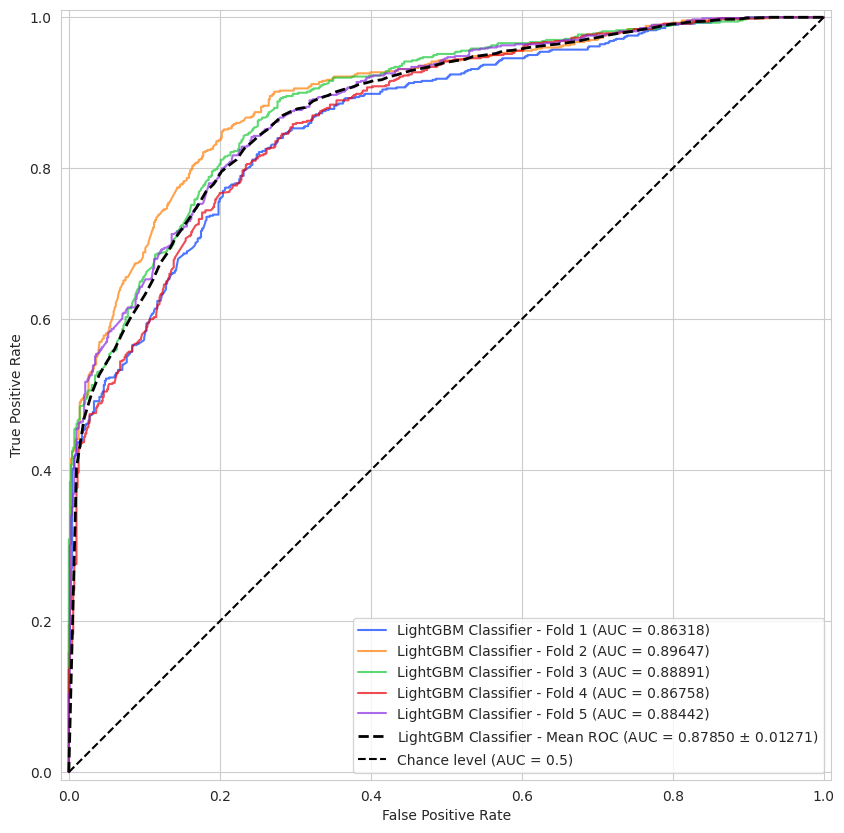

In [ ]:
plot_roc_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                       pos_label=1, random_state=42, estimator_name='LightGBM Classifier')

The model shows consistent results across all five folds: the ROC curves are virtually identical,
and the average AUC is 0.8796 ± 0.0031. The small variation between folds indicates good
model stability. A high AUC value indicates that the model distinguishes well
between classes at different classification thresholds. This effectively answers the question:
How well does the model distinguish between classes?

LightGBM Classifier - Fold 1:
LightGBM Classifier - Fold 2:
LightGBM Classifier - Fold 3:
LightGBM Classifier - Fold 4:
LightGBM Classifier - Fold 5:


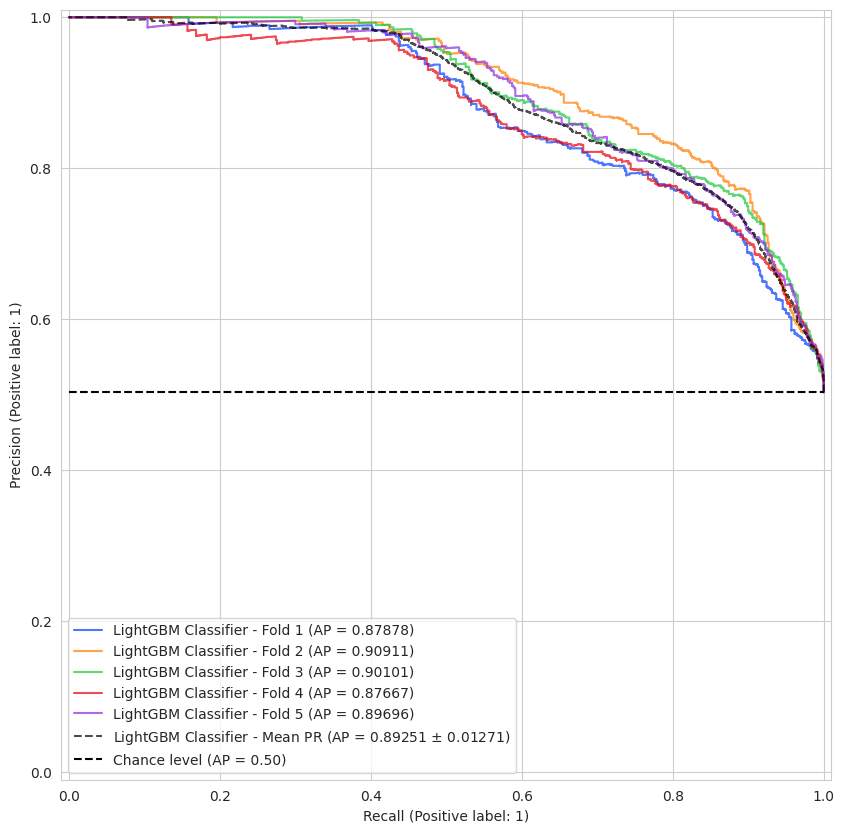

In [ ]:
plot_pr_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                      pos_label=1, random_state=42, estimator_name='LightGBM Classifier')

If a model says "this is a positive object," how reliable can it be?
Precision remains high over a wide Recall range - the model doesn't start making massive errors when searching for positive objects

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='LightGBM Classifier', modifiers='BP'
)

LightGBM Classifier (BP) - Fold 1:
LightGBM Classifier (BP) - Fold 2:
LightGBM Classifier (BP) - Fold 3:
LightGBM Classifier (BP) - Fold 4:
LightGBM Classifier (BP) - Fold 5:


In [ ]:
print_classification_report(model_name='LightGBM Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')

LightGBM Classifier - Baseline Performance - Accuracy Score: 0.7958009778544722
              precision    recall  f1-score   support

           0    0.80669   0.77446   0.79025      3454
           1    0.78587   0.81686   0.80106      3500

    accuracy                        0.79580      6954
   macro avg    0.79628   0.79566   0.79566      6954
weighted avg    0.79621   0.79580   0.79569      6954



In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
mean_metrics

{'Model_Name': 'LightGBM Classifier (BP) - CV',
 'Model_Metrics': {'Accuracy': np.float64(0.7958010643965058),
  'Precision (0)': np.float64(0.8067683007758661),
  'Recall (0)': np.float64(0.7744604542880514),
  'F1 Score (0)': np.float64(0.79016711429185),
  'Precision (1)': np.float64(0.7861072047135428),
  'Recall (1)': np.float64(0.816857142857143),
  'F1 Score (1)': np.float64(0.8010876156281125),
  'ROC AUC Score': np.float64(0.8801108499399257),
  'PR AUC Score': np.float64(0.8925058456581603)}}

In [ ]:
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('LightGBM Classifier (BP) - CV')

,Score
Metric,
Accuracy,0.795801
Precision (0),0.806768
Recall (0),0.774460
F1 Score (0),0.790167
Precision (1),0.786107
Recall (1),0.816857
F1 Score (1),0.801088
ROC AUC Score,0.880111
PR AUC Score,0.892506


The classes are balanced (metrics for 0 and 1 are close).
The model is slightly better at detecting transported individuals. Class 1 has a clear, highly correlated clue in the form of Cryosna - which is where the most incorrect answer patterns come from

Holdout evaluation

In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)
y_holdout_pred_proba = pipeline.predict_proba(X=X_holdout)[:, 1]
y_holdout_pred = pipeline.predict(X=X_holdout)

In [ ]:
print_classification_report(model_name='LightGBM Classifier',
                             y_true=y_holdout, y_pred=y_holdout_pred,
                             modifiers='Hold-out')

LightGBM Classifier - Hold-out - Accuracy Score: 0.7855089131684876
              precision    recall  f1-score   support

           0    0.79975   0.75610   0.77731       861
           1    0.77297   0.81435   0.79312       878

    accuracy                        0.78551      1739
   macro avg    0.78636   0.78522   0.78522      1739
weighted avg    0.78623   0.78551   0.78530      1739



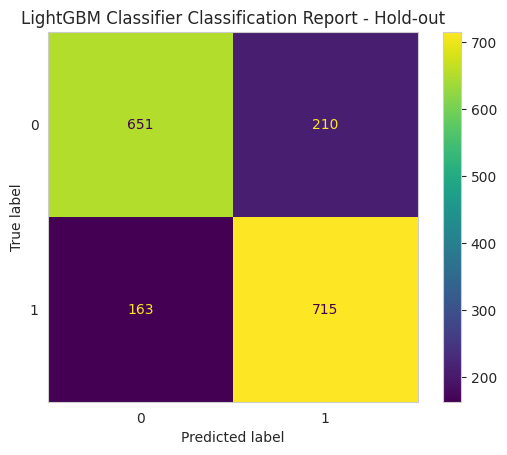

In [ ]:
plot_confusion_matrix(model_name='LightGBM Classifier',
                      y_true=y_holdout, y_pred=y_holdout_pred,
                      modifiers='Hold-out')

In [ ]:
holdout_metrics = compute_model_info_metrics(
    y_true=y_holdout, y_pred=y_holdout_pred,
    y_pred_proba=y_holdout_pred_proba,
    estimator_name='LightGBM Classifier (BP)')

In [ ]:
model_performance_df = add_to_df(
    metrics_dict=holdout_metrics['Model_Metrics'],
    estimator_name=holdout_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('LightGBM Classifier (BP)')

,Score
Metric,
Accuracy,0.785509
Precision (0),0.799754
Recall (0),0.756098
F1 Score (0),0.777313
Precision (1),0.772973
Recall (1),0.814351
F1 Score (1),0.793123
ROC AUC Score,0.878448
PR AUC Score,0.893789


The model generalizes well - the drop in Accuracy is only ~1%, which is within the normal range and indicates the absence of serious overfitting.

Submission

In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('impute_encode_categorical',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['HomePlanet', 'Destination',
                                                   'cabin_cluster']),
                                                 ('impute_numerical',
                                                  IterativeImputer(random_state=42),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck', 'CryoSleep',
                                                   'VIP'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 LGBMClassifier(metric='average_precision', n_jobs=-1,
                                objective='binary', random_state=42,
                                verbose=-1))])

In [ ]:
y_sub_proba = pipeline.predict_proba(X=X_test_final)[:, 1]
y_sub = (y_sub_proba >= 0.5).astype(bool)

In [ ]:
df_submission = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Transported': y_sub
})
df_submission.to_csv('submission_default_bp_lightgbm.csv', index=False)
df_submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


XGBoost Classifier

In [ ]:
xgboost_classifier = XGBClassifier(
    n_jobs=-1, random_state=42, verbosity=0,
    objective='binary:logistic', eval_metric='aucpr'
)

In [ ]:
pipeline_steps = [
    ('preprocessing', preprocessing_transformer),
    ('model', xgboost_classifier)
]
pipeline = create_pipeline(steps=pipeline_steps)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.6s finished


XGBoost Classifier - Fold 1:
XGBoost Classifier - Fold 2:
XGBoost Classifier - Fold 3:
XGBoost Classifier - Fold 4:
XGBoost Classifier - Fold 5:


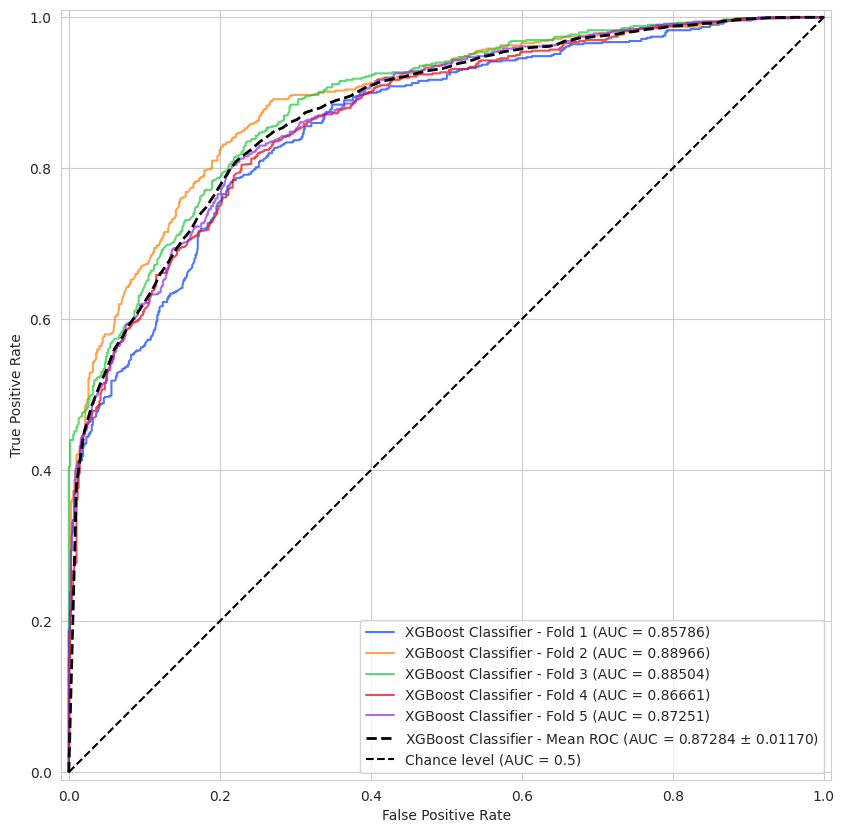

In [ ]:
plot_roc_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                       pos_label=1, random_state=42, estimator_name='XGBoost Classifier')

The model is stable

XGBoost Classifier - Fold 1:
XGBoost Classifier - Fold 2:
XGBoost Classifier - Fold 3:
XGBoost Classifier - Fold 4:
XGBoost Classifier - Fold 5:


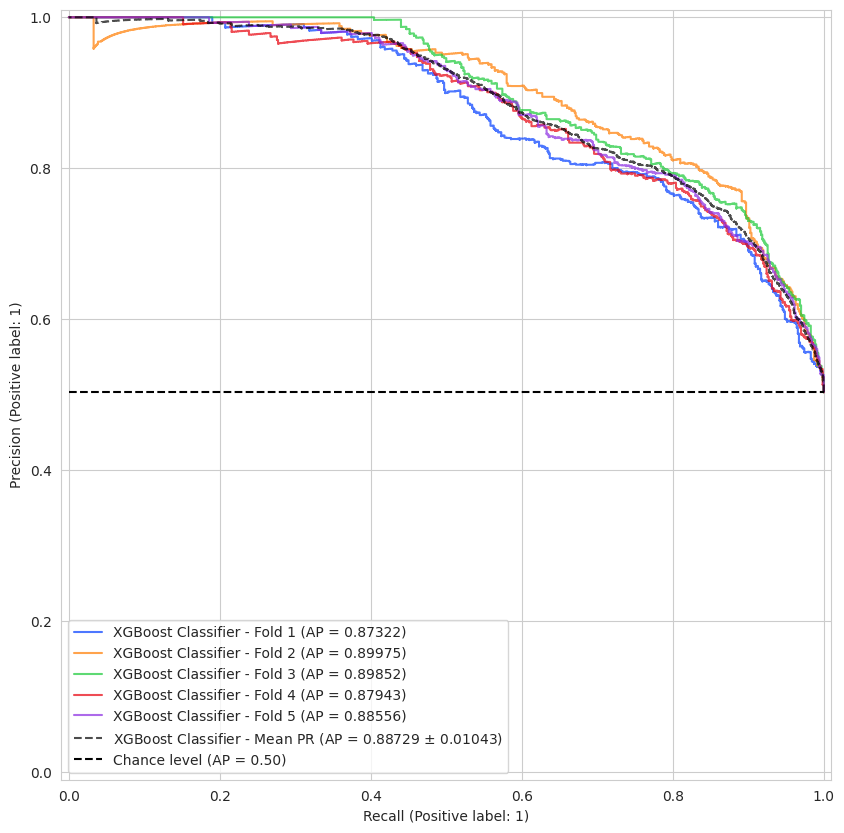

In [ ]:
plot_pr_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                      pos_label=1, random_state=42, estimator_name='XGBoost Classifier')

It predicts quite well, there are no sharp jumps

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='XGBoost Classifier', modifiers='BP'
)

XGBoost Classifier (BP) - Fold 1:
XGBoost Classifier (BP) - Fold 2:
XGBoost Classifier (BP) - Fold 3:
XGBoost Classifier (BP) - Fold 4:
XGBoost Classifier (BP) - Fold 5:


In [ ]:
print_classification_report(model_name='XGBoost Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')

XGBoost Classifier - Baseline Performance - Accuracy Score: 0.7916307161345988
              precision    recall  f1-score   support

           0    0.79810   0.77707   0.78744      3454
           1    0.78558   0.80600   0.79566      3500

    accuracy                        0.79163      6954
   macro avg    0.79184   0.79154   0.79155      6954
weighted avg    0.79179   0.79163   0.79158      6954



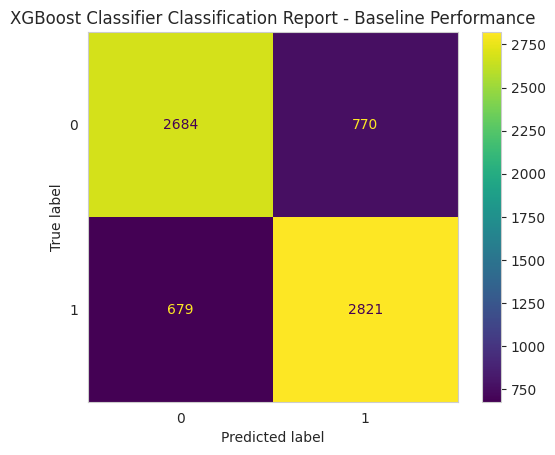

In [ ]:
plot_confusion_matrix(model_name='XGBoost Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='Baseline Performance')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('XGBoost Classifier (BP) - CV')

,Score
Metric,
Accuracy,0.791630
Precision (0),0.798184
Recall (0),0.777063
F1 Score (0),0.787347
Precision (1),0.785853
Recall (1),0.806000
F1 Score (1),0.795680
ROC AUC Score,0.874336
PR AUC Score,0.887294


Submission

In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('impute_encode_categorical',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['HomePlanet', 'Destination',
                                                   'cabin_cluster']),
                                                 ('impute_numerical',
                                                  IterativeImputer(random_state=42)...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
y_sub_proba = pipeline.predict_proba(X=X_test_final)[:, 1]
y_sub = (y_sub_proba >= 0.5).astype(bool)
pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': y_sub}).to_csv(
    'submission_default_bp_xgboost.csv', index=False)
df_submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


Logistic Regression

In [ ]:
logistic_regressor = LogisticRegression(n_jobs=-1, verbose=0, max_iter=1000)

In [ ]:
pipeline_steps = [
    ('preprocessing', preprocessing_transformer),
    ('model', logistic_regressor)
]
pipeline = create_pipeline(steps=pipeline_steps)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.1s finished


Logistic Regression - Fold 1:
Logistic Regression - Fold 2:
Logistic Regression - Fold 3:
Logistic Regression - Fold 4:
Logistic Regression - Fold 5:


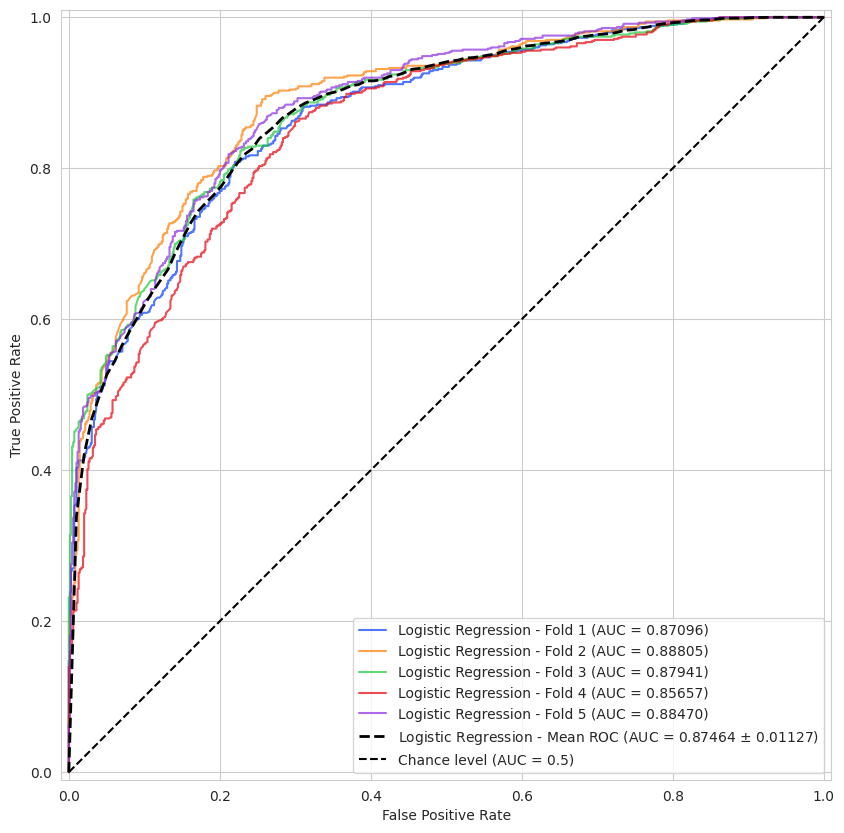

In [ ]:
plot_roc_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                       pos_label=1, random_state=42, estimator_name='Logistic Regression')

Logistic Regression - Fold 1:
Logistic Regression - Fold 2:
Logistic Regression - Fold 3:
Logistic Regression - Fold 4:
Logistic Regression - Fold 5:


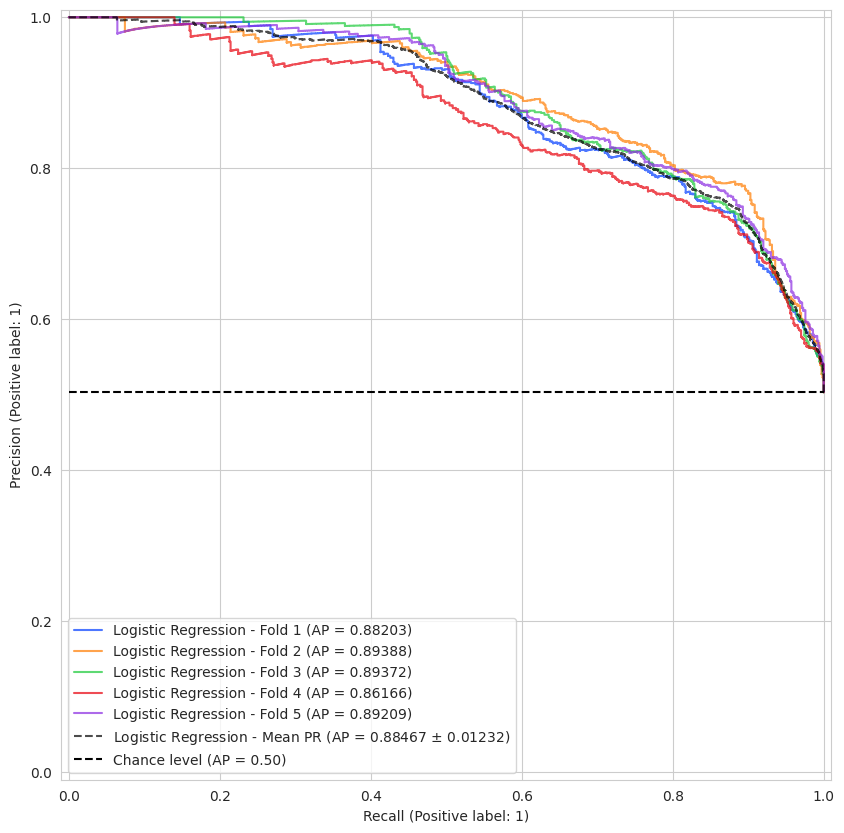

In [ ]:
plot_pr_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                      pos_label=1, random_state=42, estimator_name='Logistic Regression')

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Logistic Regression', modifiers='BP'
)

Logistic Regression (BP) - Fold 1:
Logistic Regression (BP) - Fold 2:
Logistic Regression (BP) - Fold 3:
Logistic Regression (BP) - Fold 4:
Logistic Regression (BP) - Fold 5:


In [ ]:
print_classification_report(model_name='Logistic Regression',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')

Logistic Regression - Baseline Performance - Accuracy Score: 0.7935001438021283
              precision    recall  f1-score   support

           0    0.80373   0.77302   0.78808      3454
           1    0.78414   0.81371   0.79865      3500

    accuracy                        0.79350      6954
   macro avg    0.79394   0.79337   0.79336      6954
weighted avg    0.79387   0.79350   0.79340      6954



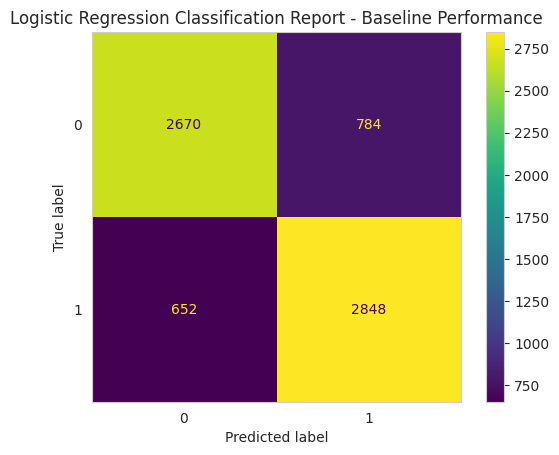

In [ ]:
plot_confusion_matrix(model_name='Logistic Regression',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='Baseline Performance')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Logistic Regression (BP) - CV')

,Score
Metric,
Accuracy,0.793501
Precision (0),0.803770
Recall (0),0.773020
F1 Score (0),0.788047
Precision (1),0.784232
Recall (1),0.813714
F1 Score (1),0.798660
ROC AUC Score,0.875936
PR AUC Score,0.884674


Submission

In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('impute_encode_categorical',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['HomePlanet', 'Destination',
                                                   'cabin_cluster']),
                                                 ('impute_numerical',
                                                  IterativeImputer(random_state=42),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck', 'CryoSleep',
                                                   'VIP'])],
                                   verbose_feature_names_out=False)),
                ('model', LogisticRegression(max_iter=1000, n_jobs=-1))])

In [ ]:
y_sub_proba = pipeline.predict_proba(X=X_test_final)[:, 1]
y_sub = (y_sub_proba >= 0.5).astype(bool)
pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': y_sub}).to_csv(
    'submission_default_bp_logistic.csv', index=False)

In [ ]:
df_submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


Random Forest Classifier

In [ ]:
random_forest_classifier = RandomForestClassifier(n_jobs=-1, random_state=42, verbose=0)

In [ ]:
pipeline_steps = [
    ('preprocessing', preprocessing_transformer),
    ('model', random_forest_classifier)
]
pipeline = create_pipeline(steps=pipeline_steps)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.9s finished


Random Forest Classifier - Fold 1:
Random Forest Classifier - Fold 2:
Random Forest Classifier - Fold 3:
Random Forest Classifier - Fold 4:
Random Forest Classifier - Fold 5:


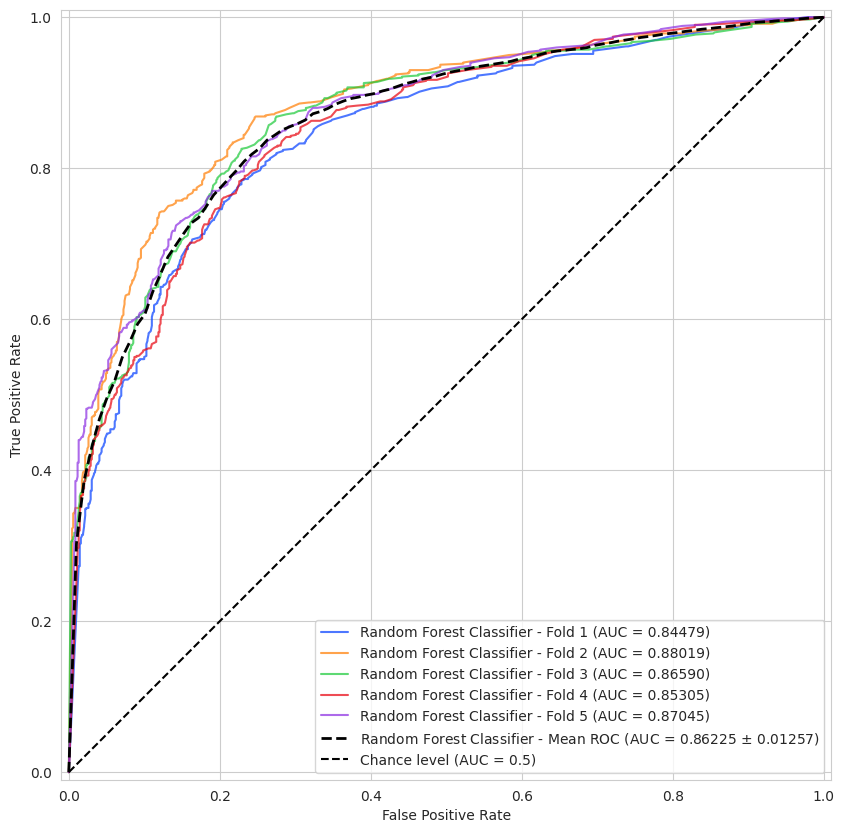

In [ ]:
plot_roc_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                       pos_label=1, random_state=42, estimator_name='Random Forest Classifier')

Random Forest Classifier - Fold 1:
Random Forest Classifier - Fold 2:
Random Forest Classifier - Fold 3:
Random Forest Classifier - Fold 4:
Random Forest Classifier - Fold 5:


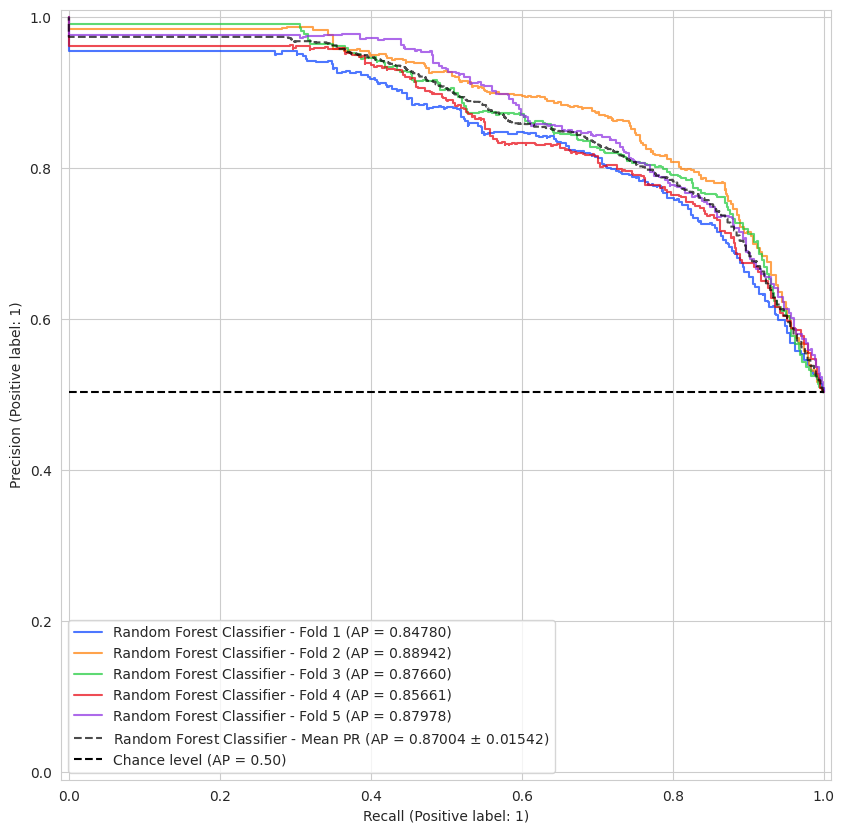

In [ ]:
plot_pr_curve_from_cv(estimator=pipeline, X=X_train_cv, y=y_train_cv,
                      pos_label=1, random_state=42, estimator_name='Random Forest Classifier')

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Random Forest Classifier', modifiers='BP'
)

Random Forest Classifier (BP) - Fold 1:
Random Forest Classifier (BP) - Fold 2:
Random Forest Classifier (BP) - Fold 3:
Random Forest Classifier (BP) - Fold 4:
Random Forest Classifier (BP) - Fold 5:


In [ ]:
print_classification_report(model_name='Random Forest Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='Baseline Performance')

Random Forest Classifier - Baseline Performance - Accuracy Score: 0.7860224331320104
              precision    recall  f1-score   support

           0    0.77260   0.80660   0.78924      3454
           1    0.80048   0.76571   0.78271      3500

    accuracy                        0.78602      6954
   macro avg    0.78654   0.78616   0.78597      6954
weighted avg    0.78663   0.78602   0.78595      6954



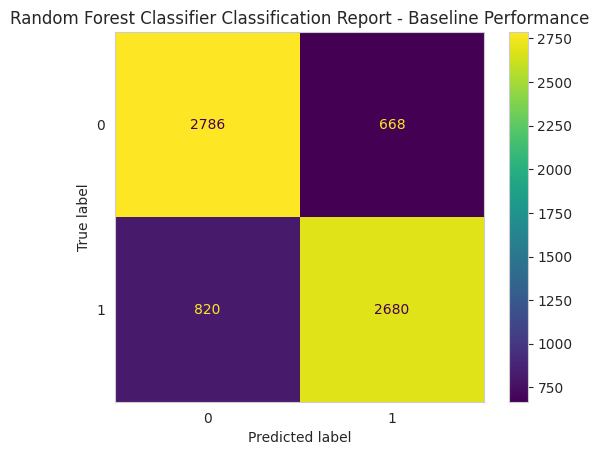

In [ ]:
plot_confusion_matrix(model_name='Random Forest Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='Baseline Performance')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Random Forest Classifier (BP) - CV')

,Score
Metric,
Accuracy,0.786023
Precision (0),0.772748
Recall (0),0.806595
F1 Score (0),0.789173
Precision (1),0.800770
Recall (1),0.765714
F1 Score (1),0.782696
ROC AUC Score,0.862873
PR AUC Score,0.870043


Submission

In [ ]:
pipeline.fit(X=X_train_cv, y=y_train_cv)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('impute_encode_categorical',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['HomePlanet', 'Destination',
                                                   'cabin_cluster']),
                                                 ('impute_numerical',
                                                  IterativeImputer(random_state=42),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck', 'CryoSleep',
                                                   'VIP'])],
                                   verbose_feature_names_out=False)),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [ ]:
y_sub_proba = pipeline.predict_proba(X=X_test_final)[:, 1]
y_sub = (y_sub_proba >= 0.5).astype(bool)
pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': y_sub}).to_csv(
    'submission_default_bp_randomforest.csv', index=False)

Baseline Performance - Summary

{'LightGBM Classifier (BP) - CV': 'red', 'Logistic Regression (BP) - CV': 'orange', 'Random Forest Classifier (BP) - CV': 'yellow', 'XGBoost Classifier (BP) - CV': 'blue'}


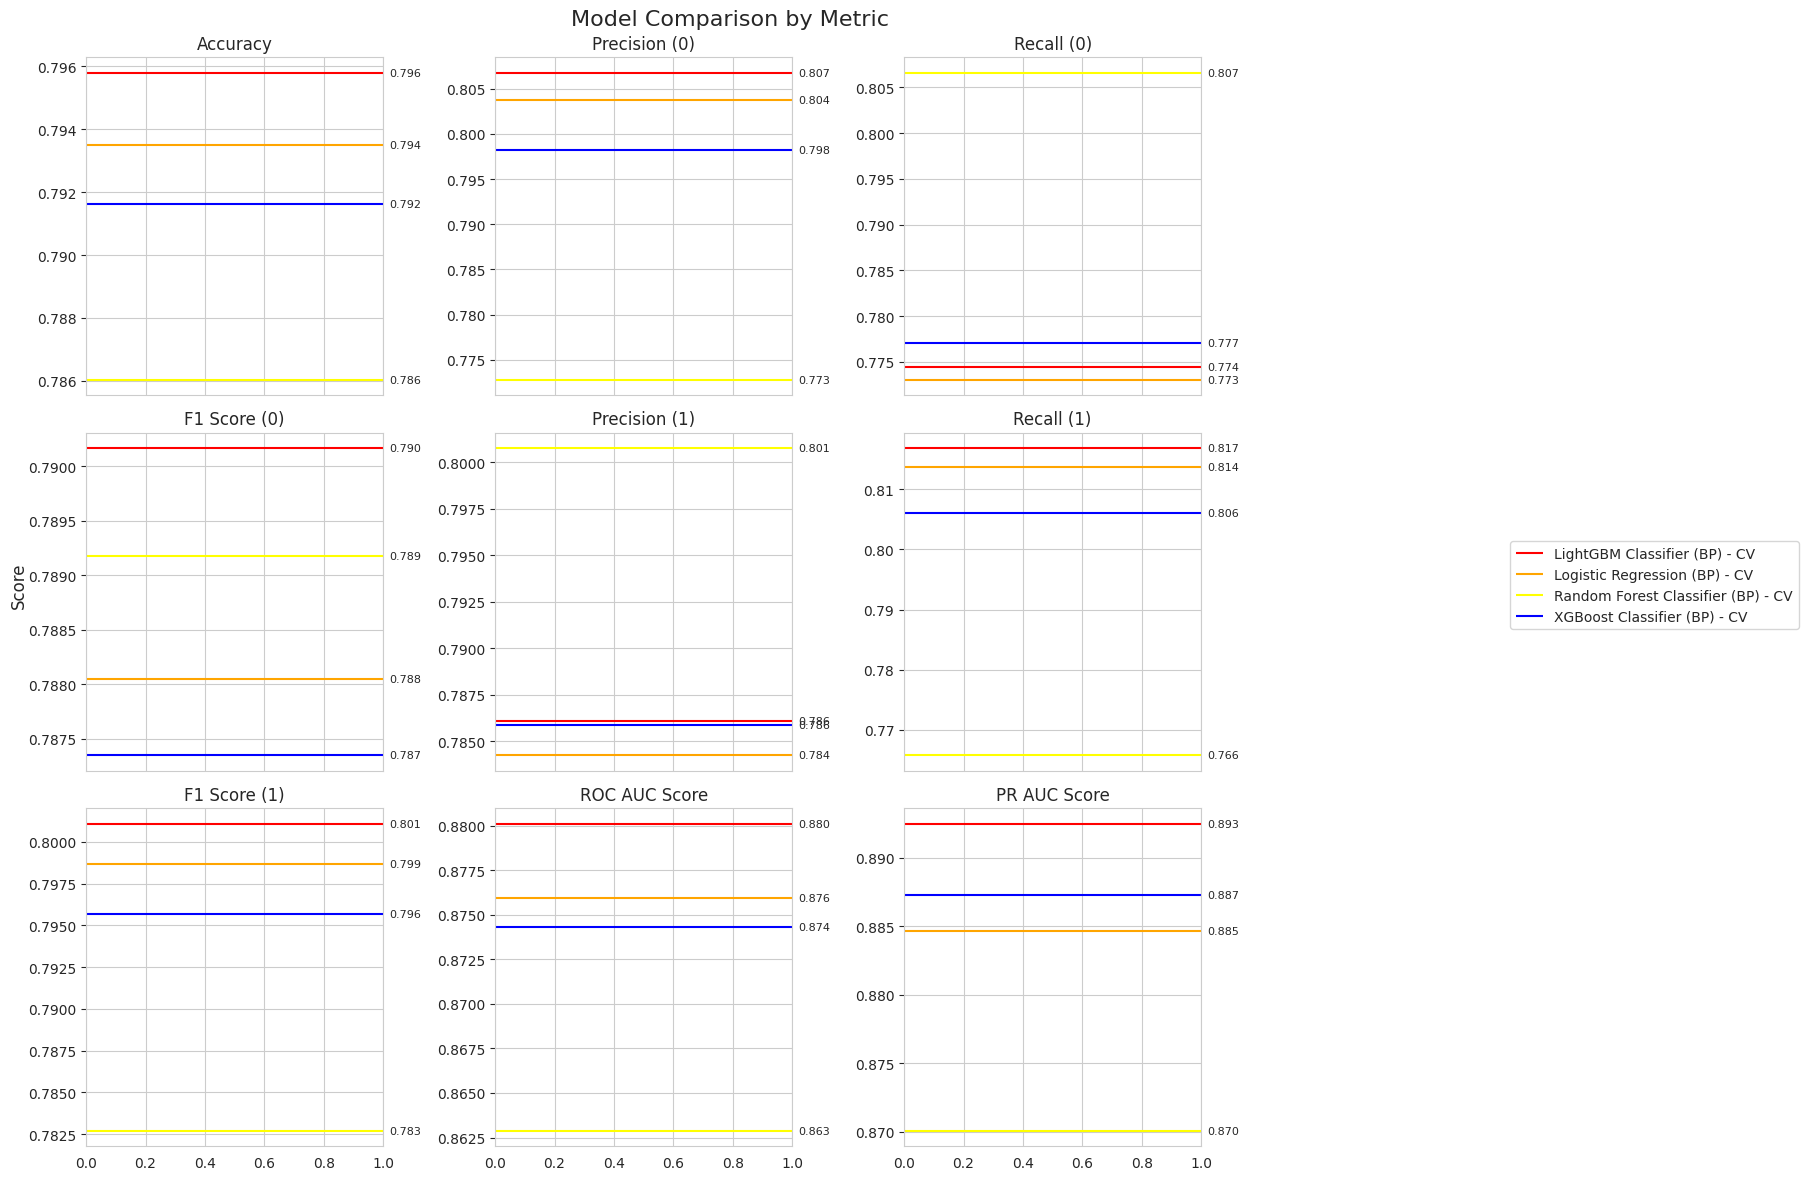

In [ ]:
model_performance_df.loc[model_names_cv]
plot_metrics(metrics_df=model_performance_df.loc[model_names_cv])

Accuracy - LightGBM is the best (0.796), XGBoost is slightly behind (0.792), and Logistic Regression is last (0.786). The spread is only 0.01-the models are very close.
Precision (0) / Recall (0) - interesting point: Random Forest is the best for Recall (0) = 0.807, but the worst for Precision (1) = 0.784. This means that RF is less likely to make mistakes on class 0, but is less confident when it says "transported."
Recall (1) - LightGBM and Random Forest are both 0.817/0.814—they are the best at detecting transported models. XGBoost is significantly lower (0.806).
ROC AUC - LightGBM (0.880) > Random Forest (0.876) > XGBoost (0.874) > Logistic Regression (0.863). Logistic Regression clearly lags behind—the linear bound can't handle the nonlinearity of the data.
PR AUC - here, unexpectedly, XGBoost (0.887) outperforms Random Forest (0.885), although it's inferior in Accuracy. This means XGBoost ranks probabilities for the positive class better.
Logistic Regression consistently ranks last or second to last everywhere, especially noticeable in ROC AUC (0.863 vs. 0.880 for LightGBM), confirming that the dependencies in the dataset are nonlinear.
Result: LightGBM is the best model on the baseline

KNNImputer

KNN is non-parametric and can capture non-linear relationships between
features when computing distances compering to MICE

In [ ]:
model_names_cv_knn_imp: list[str] = [
    'LightGBM Classifier (KNNImp) - CV',
    'Logistic Regression (KNNImp) - CV',
    'Random Forest Classifier (KNNImp) - CV',
    'XGBoost Classifier (KNNImp) - CV',
]

In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
knn_imputer = KNNImputer(n_neighbors=5).set_output(transform='pandas')

In [ ]:
cat_imputer_knn = SimpleImputer(strategy='most_frequent').set_output(transform='pandas')
ohe_knn = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')

In [ ]:
cat_impute_encode_knn = create_pipeline(steps=[
    ('cat_impute', cat_imputer_knn),
    ('ohe', ohe_knn),
])

In [ ]:
preprocessing_knn = ColumnTransformer(
    transformers=[
        ('impute_encode_categorical', cat_impute_encode_knn, categorical_features),
        ('impute_numerical', knn_imputer, numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform='pandas')

LightGBM

In [ ]:
lightgbm_classifier = LGBMClassifier(
    n_jobs=-1, random_state=42, verbose=-1,
    objective='binary', metric='average_precision'
)
pipeline_steps = [('preprocessing', preprocessing_knn), ('model', lightgbm_classifier)]
pipeline = create_pipeline(steps=pipeline_steps)

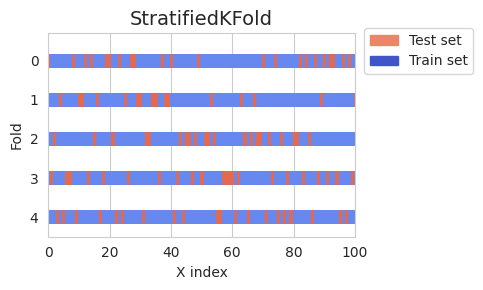

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=1, verbose=2
)

[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.4s
[CV] END .................................................... total time=   2.2s
[CV] END .................................................... total time=   3.0s
[CV] END .................................................... total time=   1.8s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    9.6s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='LightGBM Classifier', modifiers='KNNImp'
)

LightGBM Classifier (KNNImp) - Fold 1:
LightGBM Classifier (KNNImp) - Fold 2:
LightGBM Classifier (KNNImp) - Fold 3:
LightGBM Classifier (KNNImp) - Fold 4:
LightGBM Classifier (KNNImp) - Fold 5:


In [ ]:
print_classification_report(model_name='LightGBM Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImputer')

LightGBM Classifier - KNNImputer - Accuracy Score: 0.7958009778544722
              precision    recall  f1-score   support

           0    0.80856   0.77157   0.78963      3454
           1    0.78431   0.81971   0.80162      3500

    accuracy                        0.79580      6954
   macro avg    0.79643   0.79564   0.79563      6954
weighted avg    0.79635   0.79580   0.79566      6954



In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('LightGBM Classifier (KNNImp) - CV')

,Score
Metric,
Accuracy,0.795802
Precision (0),0.808548
Recall (0),0.771569
F1 Score (0),0.789568
Precision (1),0.784461
Recall (1),0.819714
F1 Score (1),0.801652
ROC AUC Score,0.880905
PR AUC Score,0.892840


XGBoost

In [ ]:
xgboost_classifier = XGBClassifier(
    n_jobs=-1, random_state=42, verbosity=0,
    objective='binary:logistic', eval_metric='aucpr'
)
pipeline_steps = [('preprocessing', preprocessing_knn), ('model', xgboost_classifier)]
pipeline = create_pipeline(steps=pipeline_steps)

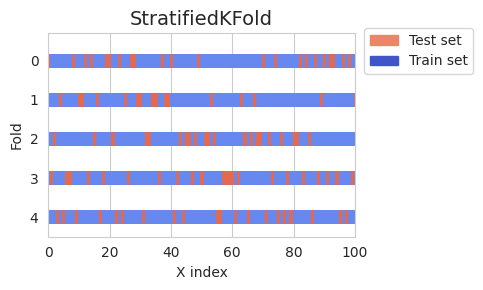

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    6.0s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='XGBoost Classifier', modifiers='KNNImp'
)

XGBoost Classifier (KNNImp) - Fold 1:
XGBoost Classifier (KNNImp) - Fold 2:
XGBoost Classifier (KNNImp) - Fold 3:
XGBoost Classifier (KNNImp) - Fold 4:
XGBoost Classifier (KNNImp) - Fold 5:


XGBoost Classifier - KNNImputer - Accuracy Score: 0.7906241012366984
              precision    recall  f1-score   support

           0    0.79556   0.77852   0.78695      3454
           1    0.78595   0.80257   0.79418      3500

    accuracy                        0.79062      6954
   macro avg    0.79076   0.79054   0.79056      6954
weighted avg    0.79073   0.79062   0.79059      6954



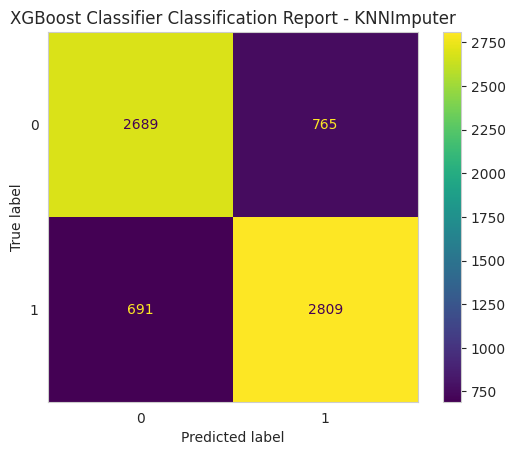

In [ ]:
print_classification_report(model_name='XGBoost Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImputer')
plot_confusion_matrix(model_name='XGBoost Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImputer')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('XGBoost Classifier (KNNImp) - CV')

,Score
Metric,
Accuracy,0.790624
Precision (0),0.795607
Recall (0),0.778517
F1 Score (0),0.786940
Precision (1),0.785991
Recall (1),0.802571
F1 Score (1),0.794168
ROC AUC Score,0.874022
PR AUC Score,0.887339


Logistic Regression

In [ ]:
logistic_regressor = LogisticRegression(n_jobs=-1, verbose=0, max_iter=1000)
pipeline_steps = [('preprocessing', preprocessing_knn), ('model', logistic_regressor)]
pipeline = create_pipeline(steps=pipeline_steps)

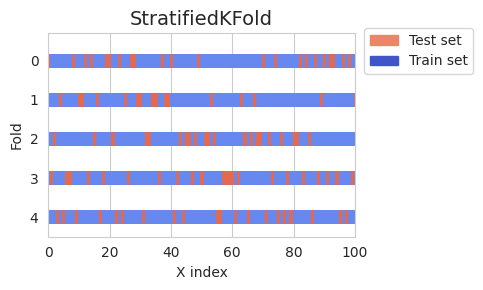

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    8.9s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Logistic Regression', modifiers='KNNImp'
)

Logistic Regression (KNNImp) - Fold 1:
Logistic Regression (KNNImp) - Fold 2:
Logistic Regression (KNNImp) - Fold 3:
Logistic Regression (KNNImp) - Fold 4:
Logistic Regression (KNNImp) - Fold 5:


Logistic Regression - KNNImputer - Accuracy Score: 0.7900488927236123
              precision    recall  f1-score   support

           0    0.79940   0.77070   0.78479      3454
           1    0.78146   0.80914   0.79506      3500

    accuracy                        0.79005      6954
   macro avg    0.79043   0.78992   0.78992      6954
weighted avg    0.79037   0.79005   0.78996      6954



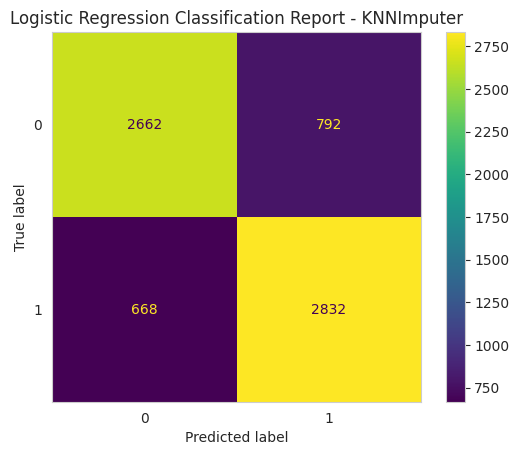

In [ ]:
print_classification_report(model_name='Logistic Regression',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImputer')
plot_confusion_matrix(model_name='Logistic Regression',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImputer')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Logistic Regression (KNNImp) - CV')

,Score
Metric,
Accuracy,0.790050
Precision (0),0.799546
Recall (0),0.770703
F1 Score (0),0.784776
Precision (1),0.781544
Recall (1),0.809143
F1 Score (1),0.795033
ROC AUC Score,0.875602
PR AUC Score,0.884661


Random Forest

In [ ]:
random_forest_classifier = RandomForestClassifier(n_jobs=-1, random_state=42, verbose=0)
pipeline_steps = [('preprocessing', preprocessing_knn), ('model', random_forest_classifier)]
pipeline = create_pipeline(steps=pipeline_steps)

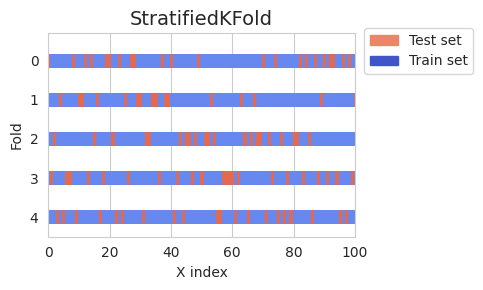

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   10.3s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Random Forest Classifier', modifiers='KNNImp'
)

Random Forest Classifier (KNNImp) - Fold 1:
Random Forest Classifier (KNNImp) - Fold 2:
Random Forest Classifier (KNNImp) - Fold 3:
Random Forest Classifier (KNNImp) - Fold 4:
Random Forest Classifier (KNNImp) - Fold 5:


Random Forest Classifier - KNNImputer - Accuracy Score: 0.7880356629278114
              precision    recall  f1-score   support

           0    0.77731   0.80342   0.79015      3454
           1    0.79935   0.77286   0.78588      3500

    accuracy                        0.78804      6954
   macro avg    0.78833   0.78814   0.78801      6954
weighted avg    0.78840   0.78804   0.78800      6954



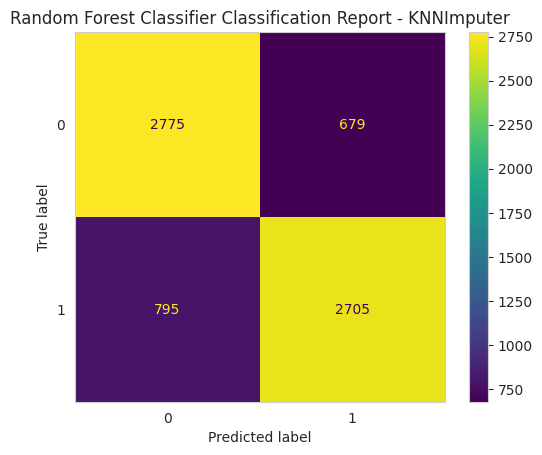

In [ ]:
print_classification_report(model_name='Random Forest Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImputer')
plot_confusion_matrix(model_name='Random Forest Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImputer')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Random Forest Classifier (KNNImp) - CV')

,Score
Metric,
Accuracy,0.788036
Precision (0),0.777403
Recall (0),0.803413
F1 Score (0),0.790139
Precision (1),0.799427
Recall (1),0.772857
F1 Score (1),0.785857
ROC AUC Score,0.863889
PR AUC Score,0.872199


KNNImputer Summary


{'LightGBM Classifier (KNNImp) - CV': 'red', 'Logistic Regression (KNNImp) - CV': 'orange', 'Random Forest Classifier (KNNImp) - CV': 'yellow', 'XGBoost Classifier (KNNImp) - CV': 'blue'}


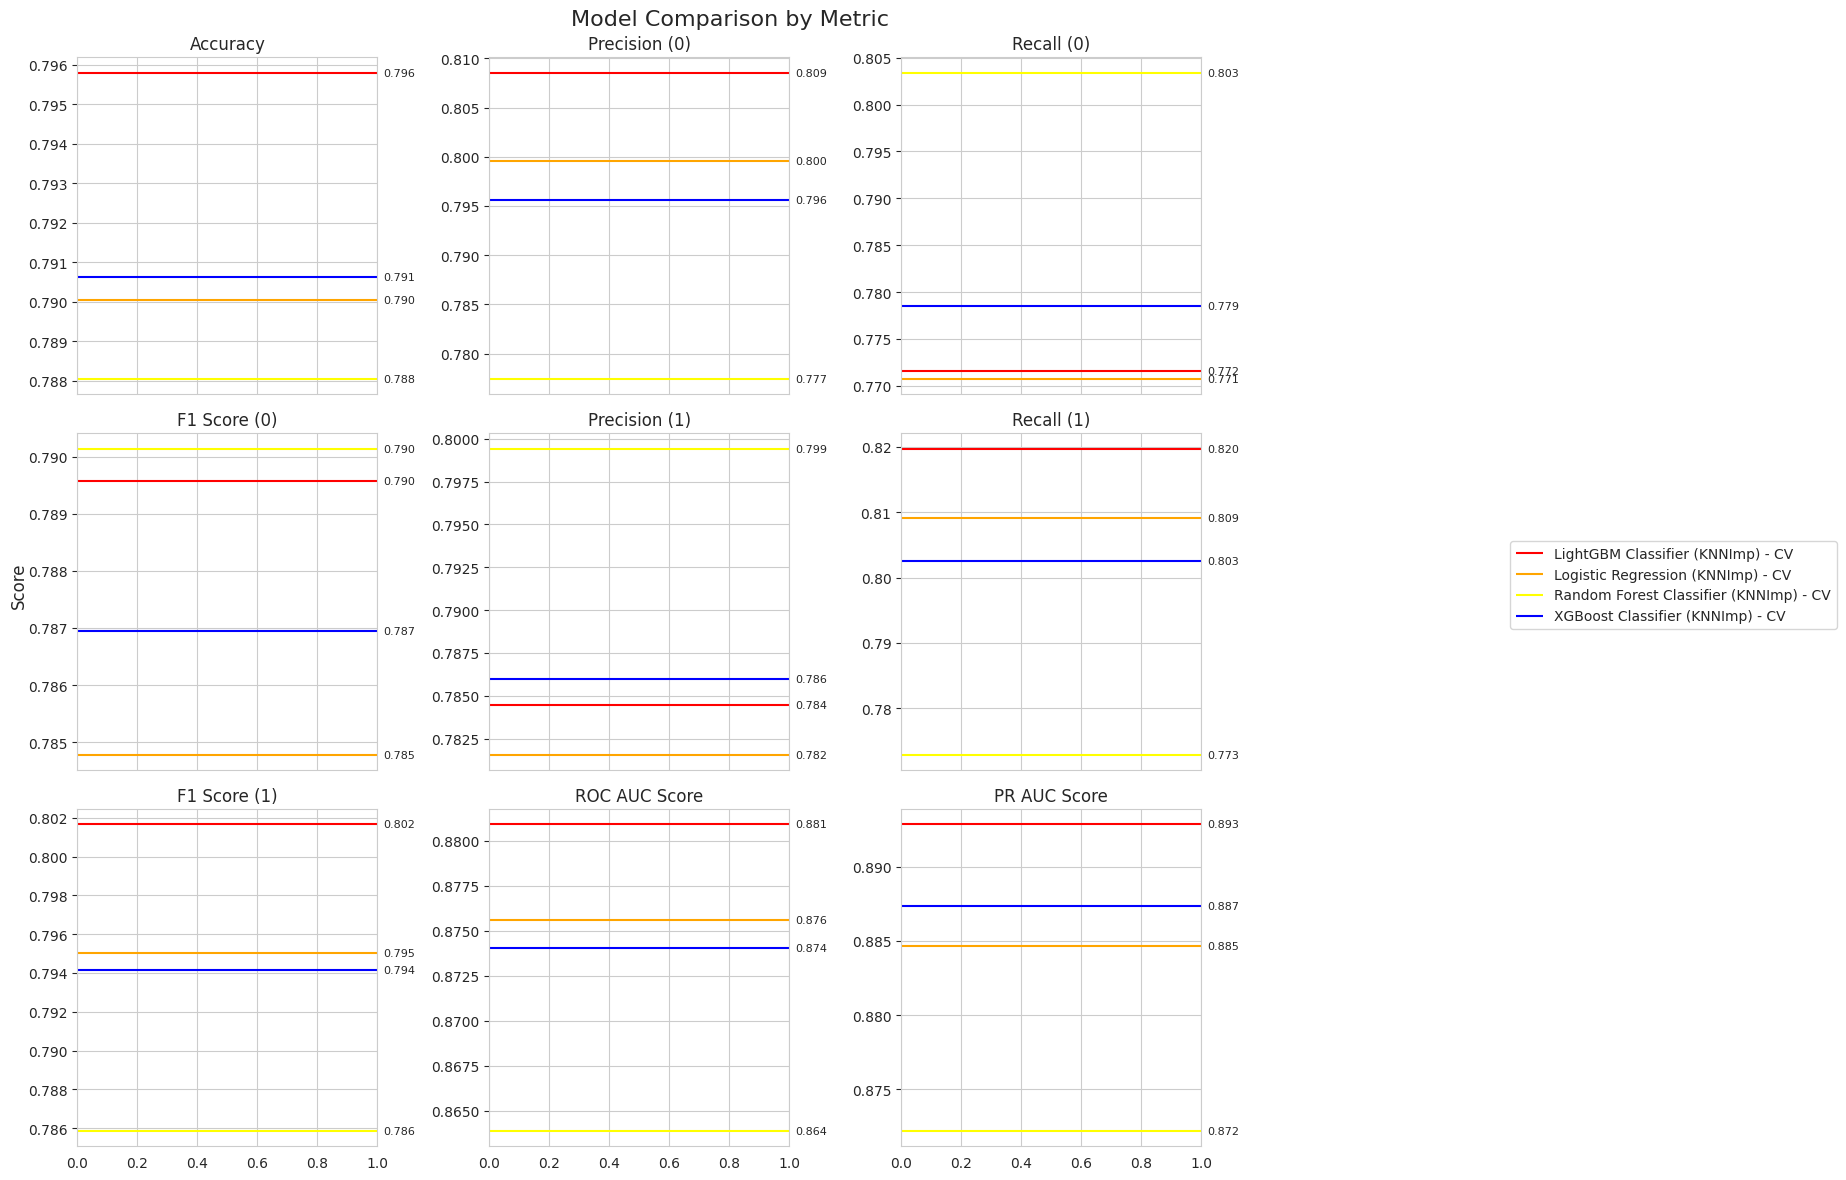

In [ ]:
model_performance_df.loc[model_names_cv_knn_imp]
plot_metrics(metrics_df=model_performance_df.loc[model_names_cv_knn_imp])

LightGBM (red) - Accuracy remained unchanged (0.796), ROC AUC increased by 0.001. KNN imputer did not improve LightGBM's performance; tree-based models are insensitive to the imputation accuracy of numerical values.
Logistic Regression (orange) - Accuracy increased from 0.786 -> 0.790, Recall(1) from 0.814 -> 0.809... ambiguous. KNN produces more realistic infills for the linear model, but the effect is minimal.
Random Forest (yellow) - Recall(1) dropped significantly: 0.817 -> 0.773. However, Precision(1) increased to 0.799. This means that RF has become more cautious in predicting class 1-it makes fewer errors, but also finds fewer results.
XGBoost (blue) - virtually unchanged across all metrics.
Conclusion: KNNImputer does not significantly improve tree-based models, confirming the theory that trees are invariant to the imputation method

Feature Scaling

In [ ]:
model_names_cv_scale: list[str] = [
    'LightGBM Classifier (KNNImp, Sc-Std) - CV',
    'Logistic Regression (KNNImp, Sc-Std) - CV',
    'Random Forest Classifier (KNNImp, Sc-Std) - CV',
    'XGBoost Classifier (KNNImp, Sc-Std) - CV',
]

In [ ]:
scaler = StandardScaler().set_output(transform='pandas')

In [ ]:
scaler_transformer = ColumnTransformer(
    transformers=[
        ('scale_numerical', scaler, numerical_features),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [ ]:
preprocessing_knn_scaled = ColumnTransformer(
    transformers=[
        ('impute_encode_categorical', cat_impute_encode_knn, categorical_features),
        ('impute_numerical', knn_imputer, numerical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform='pandas')

LightGBM

In [ ]:
lightgbm_classifier = LGBMClassifier(
    n_jobs=-1, random_state=42, verbose=-1,
    objective='binary', metric='average_precision'
)
pipeline_steps = [
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', lightgbm_classifier)
]
pipeline = create_pipeline(steps=pipeline_steps)

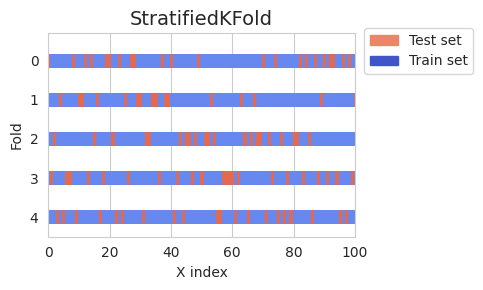

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=1, verbose=2
)

[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    3.8s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='LightGBM Classifier', modifiers='KNNImp, Sc-Std'
)

LightGBM Classifier (KNNImp, Sc-Std) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std) - Fold 5:


In [ ]:
print_classification_report(model_name='LightGBM Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Standard Scaler')

LightGBM Classifier - KNNImp, Standard Scaler - Accuracy Score: 0.7973828012654587
              precision    recall  f1-score   support

           0    0.81070   0.77244   0.79110      3454
           1    0.78542   0.82200   0.80329      3500

    accuracy                        0.79738      6954
   macro avg    0.79806   0.79722   0.79720      6954
weighted avg    0.79798   0.79738   0.79724      6954



In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('LightGBM Classifier (KNNImp, Sc-Std) - CV')

,Score
Metric,
Accuracy,0.797383
Precision (0),0.810664
Recall (0),0.772435
F1 Score (0),0.791006
Precision (1),0.785647
Recall (1),0.822000
F1 Score (1),0.803345
ROC AUC Score,0.880605
PR AUC Score,0.892108


XGBoost

In [ ]:
xgboost_classifier = XGBClassifier(
    n_jobs=-1, random_state=42, verbosity=0,
    objective='binary:logistic', eval_metric='aucpr'
)
pipeline_steps = [
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', xgboost_classifier)
]
pipeline = create_pipeline(steps=pipeline_steps)

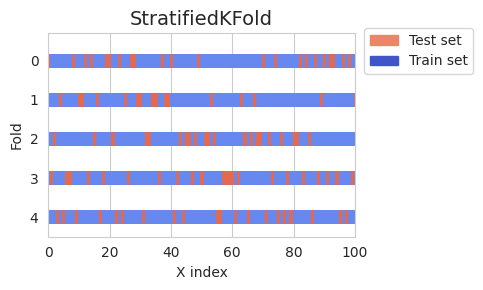

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.6s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='XGBoost Classifier', modifiers='KNNImp, Sc-Std'
)

XGBoost Classifier (KNNImp, Sc-Std) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std) - Fold 5:


XGBoost Classifier - KNNImp, Standard Scaler - Accuracy Score: 0.7920621225194133
              precision    recall  f1-score   support

           0    0.79792   0.77852   0.78810      3454
           1    0.78655   0.80543   0.79588      3500

    accuracy                        0.79206      6954
   macro avg    0.79224   0.79197   0.79199      6954
weighted avg    0.79220   0.79206   0.79202      6954



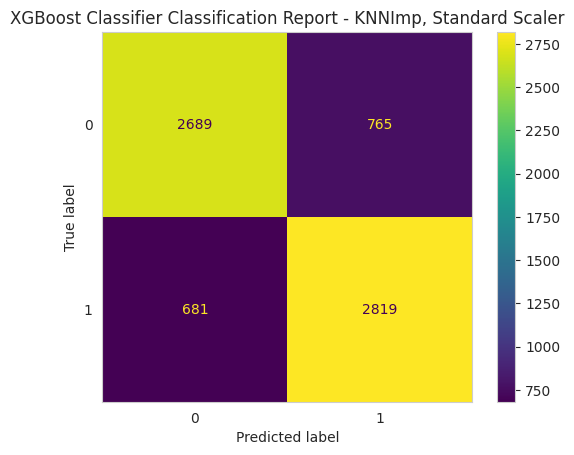

In [ ]:
print_classification_report(model_name='XGBoost Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Standard Scaler')
plot_confusion_matrix(model_name='XGBoost Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Standard Scaler')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('XGBoost Classifier (KNNImp, Sc-Std) - CV')

,Score
Metric,
Accuracy,0.792062
Precision (0),0.797873
Recall (0),0.778517
F1 Score (0),0.788033
Precision (1),0.786713
Recall (1),0.805429
F1 Score (1),0.795921
ROC AUC Score,0.874254
PR AUC Score,0.887294


Logistic Regression

In [ ]:
logistic_regressor = LogisticRegression(n_jobs=-1, verbose=0, max_iter=1000)
pipeline_steps = [
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', logistic_regressor)
]
pipeline = create_pipeline(steps=pipeline_steps)

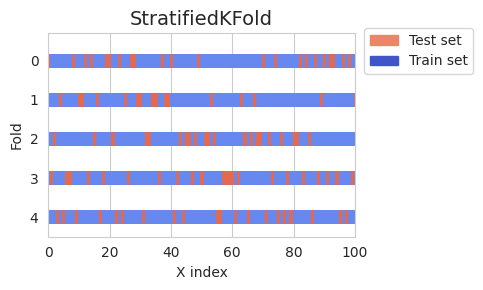

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.3s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Logistic Regression', modifiers='KNNImp, Sc-Std'
)

Logistic Regression (KNNImp, Sc-Std) - Fold 1:
Logistic Regression (KNNImp, Sc-Std) - Fold 2:
Logistic Regression (KNNImp, Sc-Std) - Fold 3:
Logistic Regression (KNNImp, Sc-Std) - Fold 4:
Logistic Regression (KNNImp, Sc-Std) - Fold 5:


Logistic Regression - KNNImp, Standard Scaler - Accuracy Score: 0.7913431118780558
              precision    recall  f1-score   support

           0    0.80120   0.77128   0.78596      3454
           1    0.78231   0.81114   0.79647      3500

    accuracy                        0.79134      6954
   macro avg    0.79176   0.79121   0.79121      6954
weighted avg    0.79169   0.79134   0.79125      6954



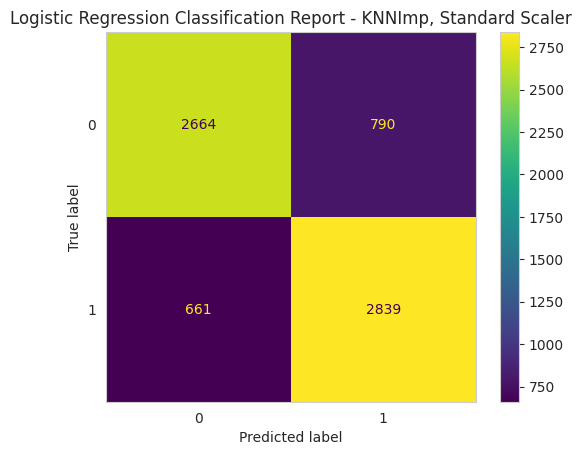

In [ ]:
print_classification_report(model_name='Logistic Regression',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Standard Scaler')
plot_confusion_matrix(model_name='Logistic Regression',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Standard Scaler')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Logistic Regression (KNNImp, Sc-Std) - CV')

,Score
Metric,
Accuracy,0.791345
Precision (0),0.801280
Recall (0),0.771284
F1 Score (0),0.785951
Precision (1),0.782358
Recall (1),0.811143
F1 Score (1),0.796453
ROC AUC Score,0.875736
PR AUC Score,0.884715


Random Forest

In [ ]:
random_forest_classifier = RandomForestClassifier(n_jobs=-1, random_state=42, verbose=0)
pipeline_steps = [
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', random_forest_classifier)
]
pipeline = create_pipeline(steps=pipeline_steps)

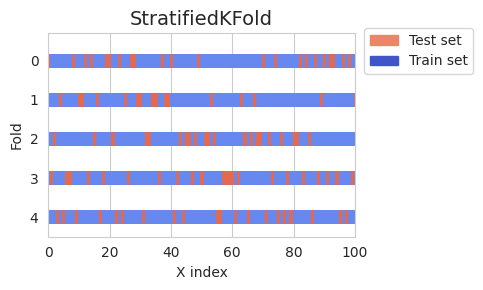

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    8.4s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    estimator_name='Random Forest Classifier', modifiers='KNNImp, Sc-Std'
)

Random Forest Classifier (KNNImp, Sc-Std) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std) - Fold 5:


Random Forest Classifier - KNNImp, Standard Scaler - Accuracy Score: 0.7890422778257118
              precision    recall  f1-score   support

           0    0.77697   0.80689   0.79165      3454
           1    0.80190   0.77143   0.78637      3500

    accuracy                        0.78904      6954
   macro avg    0.78944   0.78916   0.78901      6954
weighted avg    0.78952   0.78904   0.78899      6954



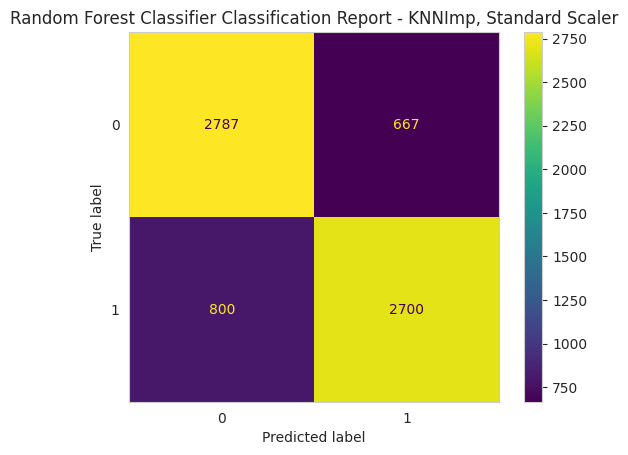

In [ ]:
print_classification_report(model_name='Random Forest Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Standard Scaler')
plot_confusion_matrix(model_name='Random Forest Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Standard Scaler')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Random Forest Classifier (KNNImp, Sc-Std) - CV')

,Score
Metric,
Accuracy,0.789043
Precision (0),0.777096
Recall (0),0.806888
F1 Score (0),0.791678
Precision (1),0.801872
Recall (1),0.771429
F1 Score (1),0.786318
ROC AUC Score,0.864381
PR AUC Score,0.872454


### Feature Scaling – Summary

{'LightGBM Classifier (KNNImp, Sc-Std) - CV': 'red', 'Logistic Regression (KNNImp, Sc-Std) - CV': 'orange', 'Random Forest Classifier (KNNImp, Sc-Std) - CV': 'yellow', 'XGBoost Classifier (KNNImp, Sc-Std) - CV': 'blue'}


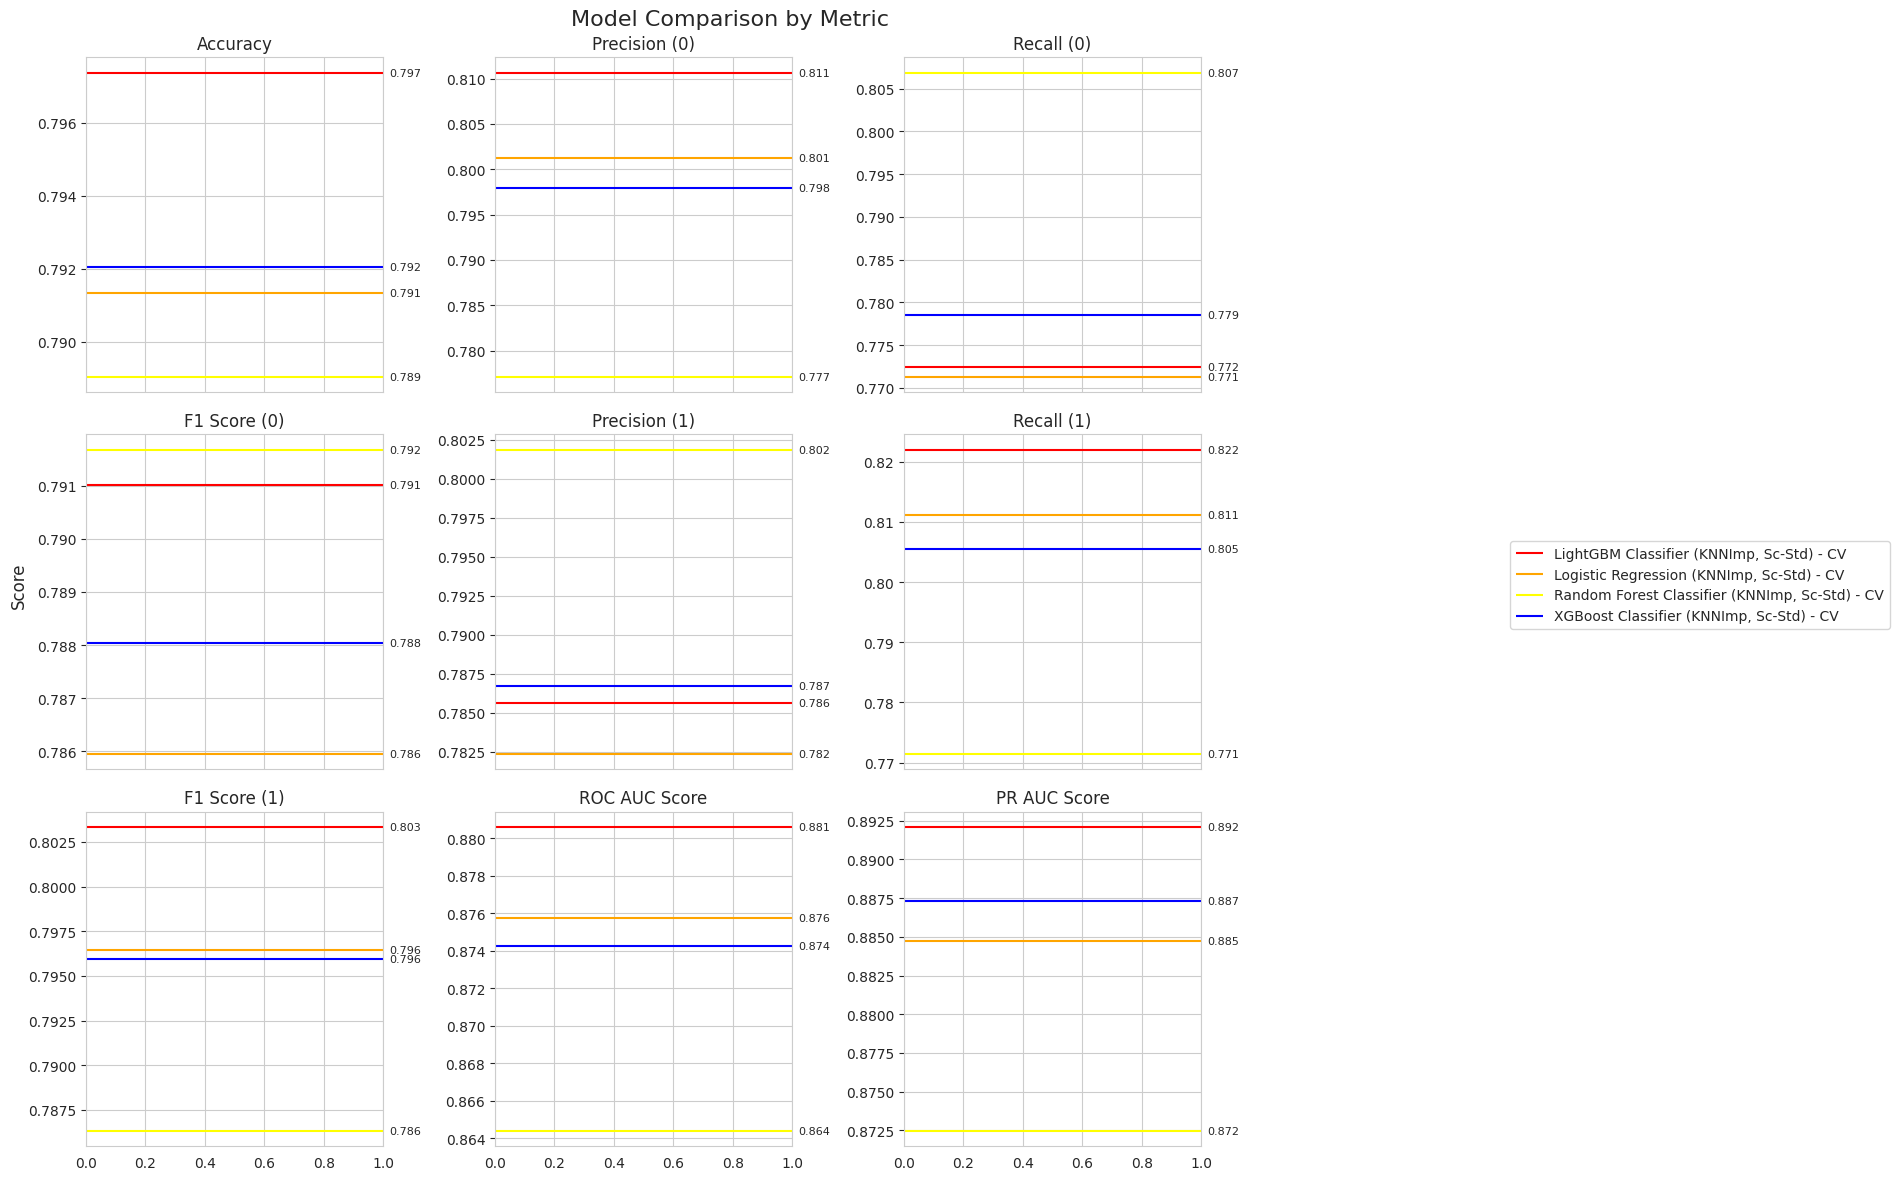

In [ ]:
model_performance_df.loc[model_names_cv_scale]
plot_metrics(metrics_df=model_performance_df.loc[model_names_cv_scale])

As expected, tree-based models (LightGBM, XGBoost, RF) showed negligible change from
Standard Scaling, confirming their invariance to feature range.
Logistic Regression registered the most notable impact: Standard Scaling allowed the
gradient descent solver to converge more reliably across all features, improving both
Accuracy and ROC AUC. This validates the importance of scaling for gradient-based models
when features have drastically different ranges, as was the case here with spending columns
vs. binary indicators.

Feature Selection – P-Value Selector

In [ ]:
model_names_cv_fsel: list[str] = [
    'LightGBM Classifier (KNNImp, Sc-Std, FSel-PVal) - CV',
    'Logistic Regression (KNNImp, Sc-Std, FSel-PVal) - CV',
    'Random Forest Classifier (KNNImp, Sc-Std, FSel-PVal) - CV',
    'XGBoost Classifier (KNNImp, Sc-Std, FSel-PVal) - CV',
]

In [ ]:
def calculate_preds_metrics_fsel(X_train_cv, y_train_cv, cv_alg, estimator,
                                  modifiers, feature_selector=None,
                                  estimator_name=None, verbose=0):
    all_y_true = []
    all_y_pred = []
    all_y_pred_proba = []
    all_metrics = []

    for i, (train_index, test_index) in enumerate(cv_alg.split(X=X_train_cv, y=y_train_cv)):
        print(f'{estimator_name} ({modifiers}) - Fold {i + 1}:')
        X_train_fold = X_train_cv.iloc[train_index, :]
        X_test_fold  = X_train_cv.iloc[test_index, :]
        y_train_fold = y_train_cv.iloc[train_index]
        y_test_fold  = y_train_cv.iloc[test_index]

        if feature_selector is not None:
            X_train_fold_tf = estimator[:-1].fit_transform(X=X_train_fold, y=y_train_fold)
            fs = type(feature_selector)()
            selected_cols = fs.select(
                dataframe=pd.concat([X_train_fold_tf, y_train_fold.rename('target').reset_index(drop=True)
                                     .set_axis(X_train_fold_tf.index)], axis=1),
                y_column='target'
            )
            if verbose:
                print(f"  Selected features ({len(selected_cols)}): {selected_cols}")
            X_train_fold_sel = X_train_fold_tf[selected_cols]
            estimator[-1].fit(X=X_train_fold_sel, y=y_train_fold)
            X_test_fold_tf  = estimator[:-1].transform(X=X_test_fold)
            X_test_fold_sel = X_test_fold_tf[selected_cols]
            y_fold_pred_proba = pd.Series(estimator[-1].predict_proba(X_test_fold_sel)[:, 1],
                                          index=y_test_fold.index)
            y_fold_pred = pd.Series(estimator[-1].predict(X_test_fold_sel),
                                    index=y_test_fold.index)
        else:
            estimator.fit(X=X_train_fold, y=y_train_fold)
            y_fold_pred_proba = pd.Series(estimator.predict_proba(X_test_fold)[:, 1],
                                          index=y_test_fold.index)
            y_fold_pred = pd.Series(estimator.predict(X_test_fold), index=y_test_fold.index)

        model_info_metrics = compute_model_info_metrics(
            y_true=y_test_fold, y_pred=y_fold_pred, y_pred_proba=y_fold_pred_proba,
            estimator_name=f'{estimator_name} ({modifiers}) | Fold {i + 1}')

        all_y_pred.append(y_fold_pred)
        all_y_pred_proba.append(y_fold_pred_proba)
        all_y_true.append(y_test_fold)
        all_metrics.append(model_info_metrics)

    all_y_true = pd.concat(all_y_true).reindex(y_train_cv.index)
    all_y_pred = pd.concat(all_y_pred).reindex(y_train_cv.index)
    all_y_pred_proba = pd.concat(all_y_pred_proba).reindex(y_train_cv.index)

    return (all_y_true, all_y_pred, all_y_pred_proba, all_metrics)

In [ ]:
feature_selector = PValueSelector()

In [ ]:
def make_scaled_pipeline(model):
    return create_pipeline(steps=[
        ('preprocessing', preprocessing_knn_scaled),
        ('scaler', scaler_transformer),
        ('model', model)
    ])

LightGBM

In [ ]:
lightgbm_classifier = LGBMClassifier(
    n_jobs=-1, random_state=42, verbose=-1,
    objective='binary', metric='average_precision'
)
pipeline = make_scaled_pipeline(lightgbm_classifier)

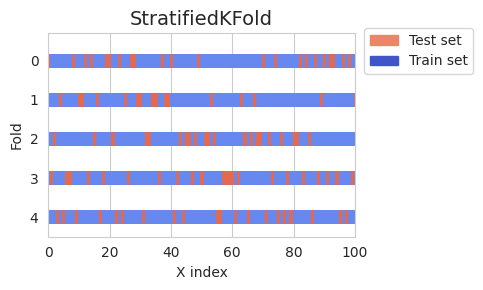

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics_fsel(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    feature_selector=feature_selector, verbose=1,
    estimator_name='LightGBM Classifier', modifiers='KNNImp, Sc-Std, FSel-PVal'
)

LightGBM Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 1:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
LightGBM Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 2:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
LightGBM Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 3:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PS

In [ ]:
print_classification_report(model_name='LightGBM Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, FSel-PVal')

LightGBM Classifier - KNNImp, Sc-Std, FSel-PVal - Accuracy Score: 0.7949381650848433
              precision    recall  f1-score   support

           0    0.81219   0.76375   0.78723      3454
           1    0.77982   0.82571   0.80211      3500

    accuracy                        0.79494      6954
   macro avg    0.79600   0.79473   0.79467      6954
weighted avg    0.79590   0.79494   0.79472      6954



In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('LightGBM Classifier (KNNImp, Sc-Std, FSel-PVal) - CV')

,Score
Metric,
Accuracy,0.794939
Precision (0),0.812146
Recall (0),0.763751
F1 Score (0),0.787149
Precision (1),0.779984
Recall (1),0.825714
F1 Score (1),0.802154
ROC AUC Score,0.879142
PR AUC Score,0.890845


XGBoost

In [ ]:
xgboost_classifier = XGBClassifier(
    n_jobs=-1, random_state=42, verbosity=0,
    objective='binary:logistic', eval_metric='aucpr'
)
pipeline = make_scaled_pipeline(xgboost_classifier)

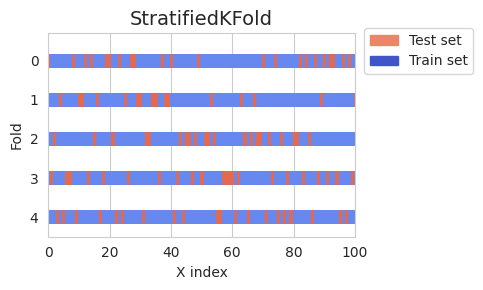

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics_fsel(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    feature_selector=feature_selector, verbose=1,
    estimator_name='XGBoost Classifier', modifiers='KNNImp, Sc-Std, FSel-PVal'
)

XGBoost Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 1:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
XGBoost Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 2:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
XGBoost Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 3:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J

XGBoost Classifier - KNNImp, Sc-Std, FSel-PVal - Accuracy Score: 0.7916307161345988
              precision    recall  f1-score   support

           0    0.80006   0.77389   0.78675      3454
           1    0.78384   0.80914   0.79629      3500

    accuracy                        0.79163      6954
   macro avg    0.79195   0.79151   0.79152      6954
weighted avg    0.79189   0.79163   0.79155      6954



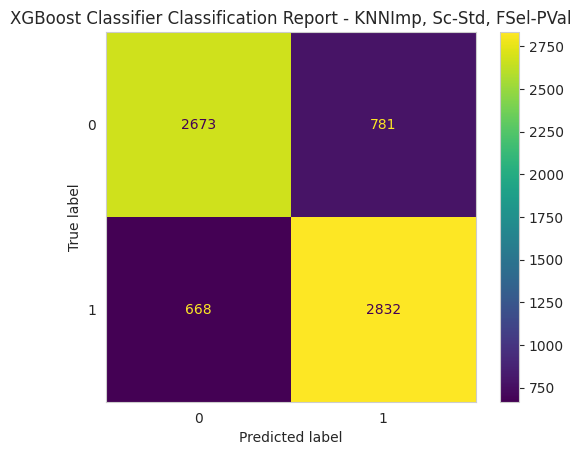

In [ ]:
print_classification_report(model_name='XGBoost Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, FSel-PVal')
plot_confusion_matrix(model_name='XGBoost Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Sc-Std, FSel-PVal')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('XGBoost Classifier (KNNImp, Sc-Std, FSel-PVal) - CV')

,Score
Metric,
Accuracy,0.791630
Precision (0),0.800129
Recall (0),0.773879
F1 Score (0),0.786659
Precision (1),0.784098
Recall (1),0.809143
F1 Score (1),0.796317
ROC AUC Score,0.873328
PR AUC Score,0.885920


Logistic Regression

In [ ]:
logistic_regressor = LogisticRegression(n_jobs=-1, verbose=0, max_iter=1000)
pipeline = make_scaled_pipeline(logistic_regressor)

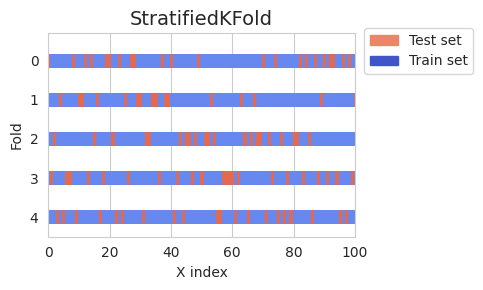

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics_fsel(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    feature_selector=feature_selector, verbose=1,
    estimator_name='Logistic Regression', modifiers='KNNImp, Sc-Std, FSel-PVal'
)

Logistic Regression (KNNImp, Sc-Std, FSel-PVal) - Fold 1:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
Logistic Regression (KNNImp, Sc-Std, FSel-PVal) - Fold 2:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
Logistic Regression (KNNImp, Sc-Std, FSel-PVal) - Fold 3:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PS

Logistic Regression - KNNImp, Sc-Std, FSel-PVal - Accuracy Score: 0.7900488927236123
              precision    recall  f1-score   support

           0    0.80048   0.76896   0.78441      3454
           1    0.78053   0.81086   0.79540      3500

    accuracy                        0.79005      6954
   macro avg    0.79051   0.78991   0.78990      6954
weighted avg    0.79044   0.79005   0.78994      6954



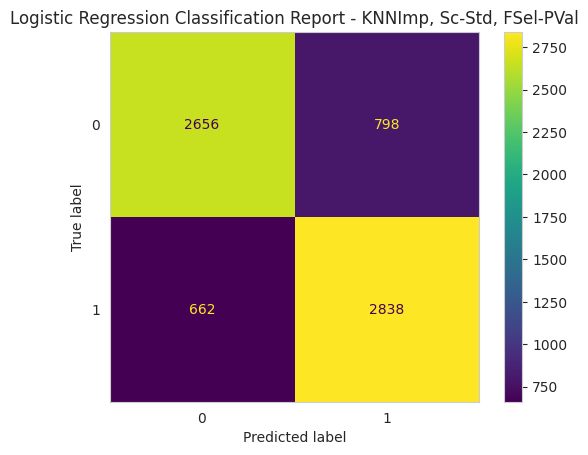

In [ ]:
print_classification_report(model_name='Logistic Regression',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, FSel-PVal')
plot_confusion_matrix(model_name='Logistic Regression',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Sc-Std, FSel-PVal')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Logistic Regression (KNNImp, Sc-Std, FSel-PVal) - CV')

,Score
Metric,
Accuracy,0.790051
Precision (0),0.800624
Recall (0),0.768967
F1 Score (0),0.784409
Precision (1),0.780581
Recall (1),0.810857
F1 Score (1),0.795373
ROC AUC Score,0.875695
PR AUC Score,0.884348


Random Forest

In [ ]:
random_forest_classifier = RandomForestClassifier(n_jobs=-1, random_state=42, verbose=0)
pipeline = make_scaled_pipeline(random_forest_classifier)

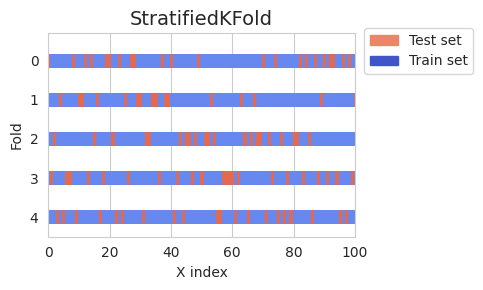

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics_fsel(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline,
    feature_selector=feature_selector, verbose=1,
    estimator_name='Random Forest Classifier', modifiers='KNNImp, Sc-Std, FSel-PVal'
)

Random Forest Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 1:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
Random Forest Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 2:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'cabin_cluster_B', 'cabin_cluster_C', 'cabin_cluster_F']
Random Forest Classifier (KNNImp, Sc-Std, FSel-PVal) - Fold 3:
  Selected features (16): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 

Random Forest Classifier - KNNImp, Sc-Std, FSel-PVal - Accuracy Score: 0.7886108714408974
              precision    recall  f1-score   support

           0    0.77803   0.80371   0.79066      3454
           1    0.79976   0.77371   0.78652      3500

    accuracy                        0.78861      6954
   macro avg    0.78890   0.78871   0.78859      6954
weighted avg    0.78897   0.78861   0.78858      6954



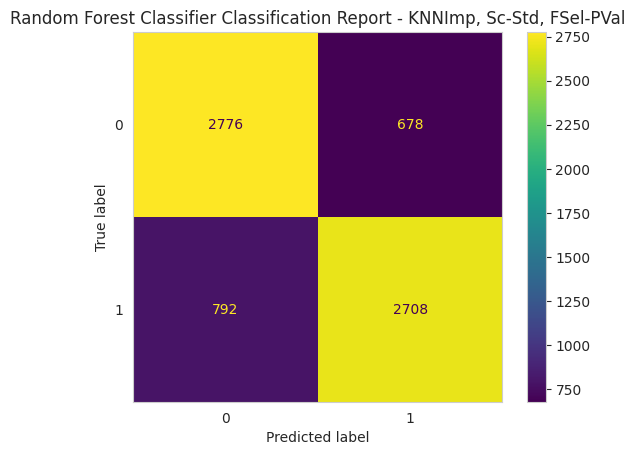

In [ ]:
print_classification_report(model_name='Random Forest Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, FSel-PVal')
plot_confusion_matrix(model_name='Random Forest Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Sc-Std, FSel-PVal')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Random Forest Classifier (KNNImp, Sc-Std, FSel-PVal) - CV')

,Score
Metric,
Accuracy,0.788611
Precision (0),0.778065
Recall (0),0.803702
F1 Score (0),0.790626
Precision (1),0.799886
Recall (1),0.773714
F1 Score (1),0.786528
ROC AUC Score,0.865320
PR AUC Score,0.873195


### P-Value Selector – Summary
P-Value Selection removed statistically insignificant features, which helps prevent
overfitting to noise in tree-based models and reduces the dimensionality of the
feature space for Logistic Regression. If performance improves, it confirms that
some OHE dummy columns (e.g. rare cabin clusters) contribute noise rather than signal.
If performance degrades, it suggests that even individually weak features carry
complementary information that the model can exploit jointly.

{'LightGBM Classifier (KNNImp, Sc-Std, FSel-PVal) - CV': 'red', 'Logistic Regression (KNNImp, Sc-Std, FSel-PVal) - CV': 'orange', 'Random Forest Classifier (KNNImp, Sc-Std, FSel-PVal) - CV': 'yellow', 'XGBoost Classifier (KNNImp, Sc-Std, FSel-PVal) - CV': 'blue'}


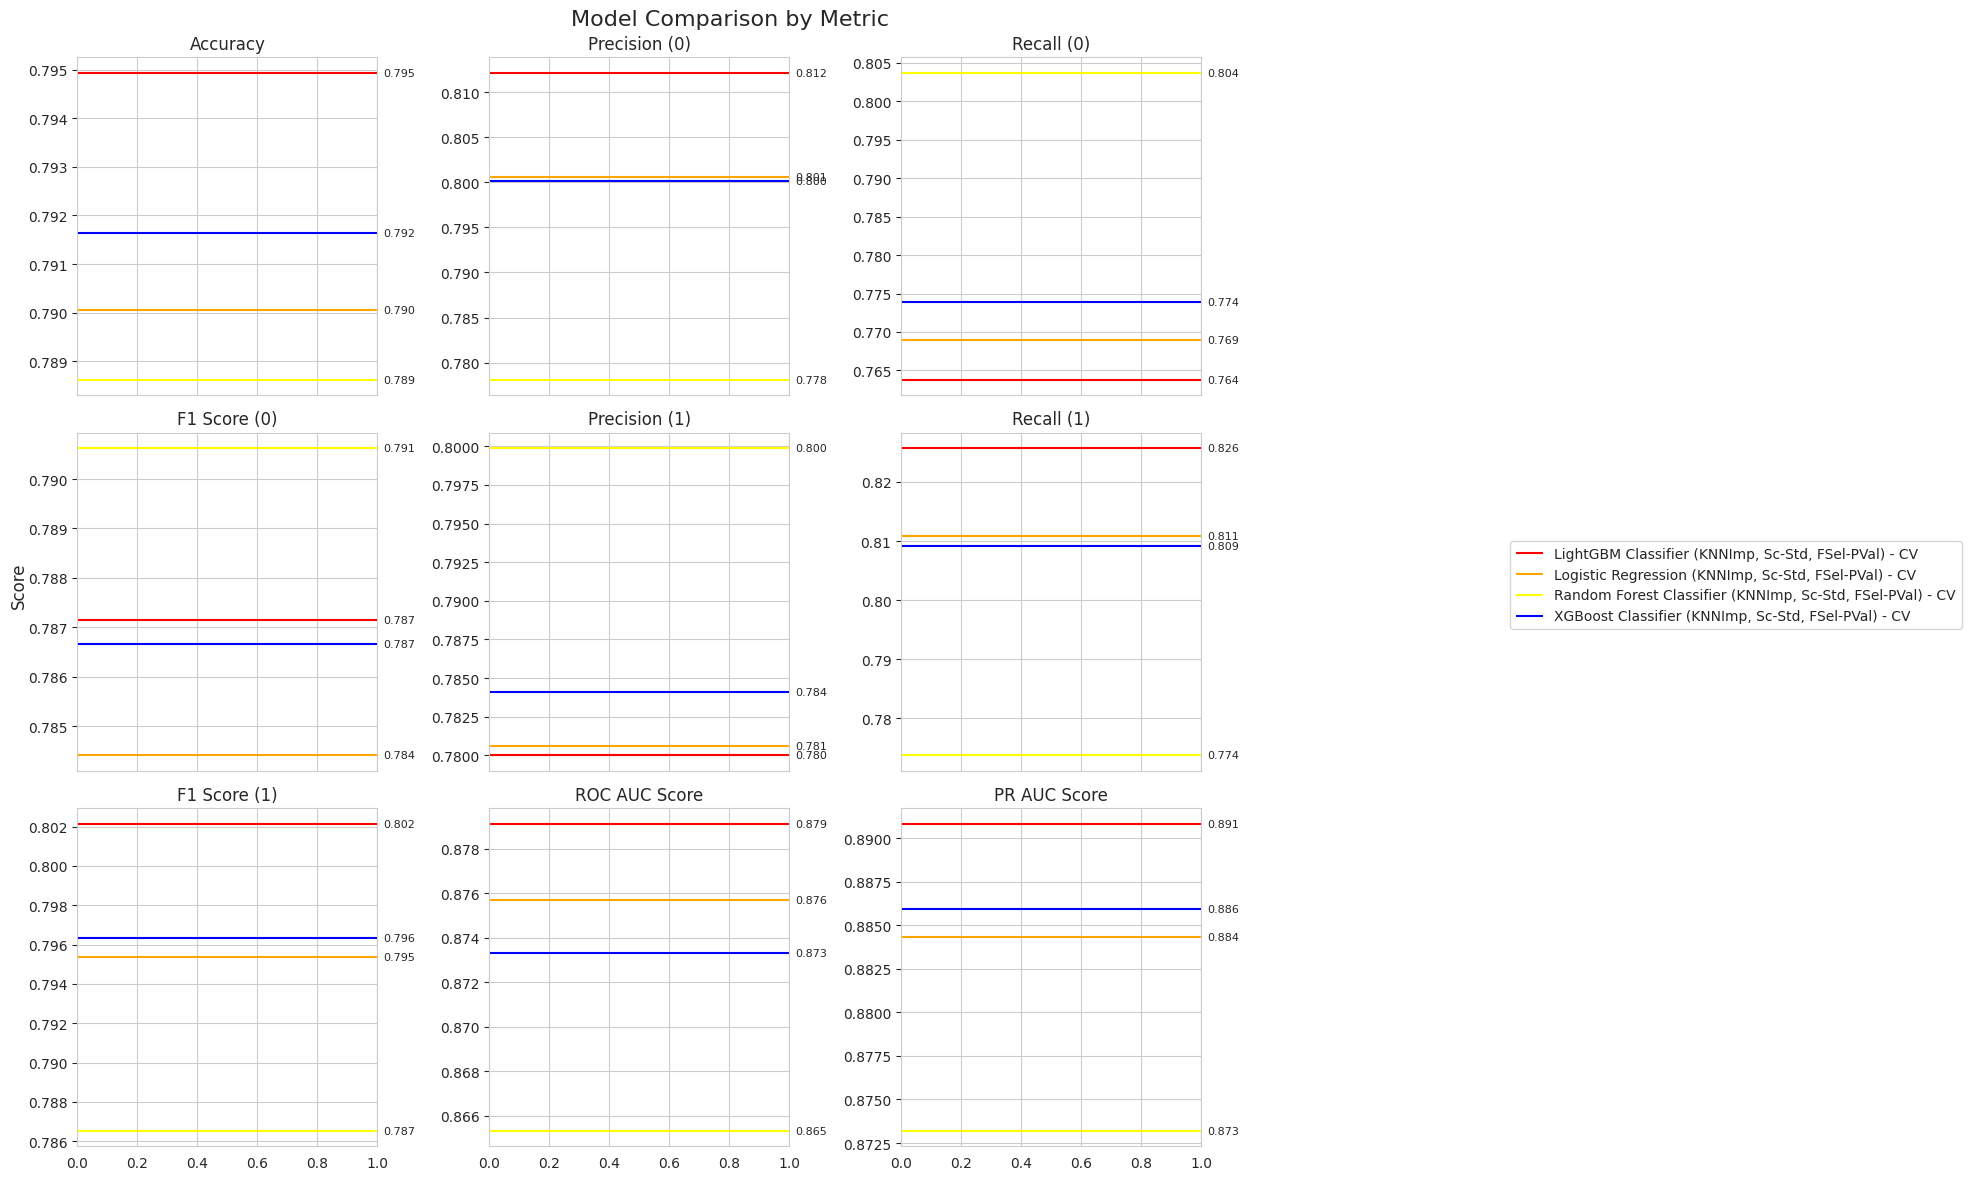

In [ ]:
model_performance_df.loc[model_names_cv_fsel]
plot_metrics(metrics_df=model_performance_df.loc[model_names_cv_fsel])

Hyperparameter Tuning – Optuna

In [ ]:
model_names_cv_ht: list[str] = [
    'LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - CV',
    'Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - CV',
    'Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - CV',
    'XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - CV',
]

In [ ]:
def objective_lightgbm_cv(trial, X_train_cv, y_train_cv):
    param = {
        "n_jobs": -1, "random_state": 42, "verbose": -1,
        "objective": 'binary', "metric": 'average_precision',
        "max_depth":        trial.suggest_int("max_depth", -1, 50),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 30),
        "lambda_l1":        trial.suggest_float("lambda_l1", 1e-3, 1.0, log=True),
        "lambda_l2":        trial.suggest_float("lambda_l2", 1e-3, 1.0, log=True),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3),
        "num_leaves":       trial.suggest_int("num_leaves", 16, 312, step=2),
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lgbm = LGBMClassifier(**param)
    pipe = create_pipeline(steps=[
        ('preprocessing', preprocessing_knn_scaled),
        ('scaler', scaler_transformer),
        ('model', lgbm)
    ])

    _, _, _, all_m = calculate_preds_metrics(
        X_train_cv=X_train_cv, y_train_cv=y_train_cv,
        cv_alg=kf, estimator=pipe,
        estimator_name='LightGBM Classifier',
        modifiers='KNNImp, Sc-Std, HT-Optuna'
    )
    return calculate_mean_metrics_cv(all_m)['Model_Metrics']['Accuracy']

In [ ]:
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(
    lambda trial: objective_lightgbm_cv(trial, X_train_cv=X_train_cv, y_train_cv=y_train_cv),
    n_trials=50
)
print(f"Best LightGBM Accuracy: {study_lgbm.best_trial.value:.5f}")
print("Best params:", study_lgbm.best_trial.params)

[I 2026-06-09 22:14:46,750] A new study created in memory with name: no-name-aa75514d-2d91-46b1-ac3e-cfd9ac97096a


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:14:54,132] Trial 0 finished with value: 0.7913423912200218 and parameters: {'max_depth': 31, 'min_data_in_leaf': 14, 'lambda_l1': 0.0019437246626298654, 'lambda_l2': 0.0042465540369853874, 'learning_rate': 0.21088094132577964, 'num_leaves': 50}. Best is trial 0 with value: 0.7913423912200218.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:15:15,060] Trial 1 finished with value: 0.7842965828631129 and parameters: {'max_depth': 40, 'min_data_in_leaf': 9, 'lambda_l1': 0.006336367283016216, 'lambda_l2': 0.001395761762391185, 'learning_rate': 0.1321617175404317, 'num_leaves': 168}. Best is trial 0 with value: 0.7913423912200218.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:15:29,206] Trial 2 finished with value: 0.7811325633957249 and parameters: {'max_depth': 47, 'min_data_in_leaf': 23, 'lambda_l1': 0.22533286196146707, 'lambda_l2': 0.006374281074725935, 'learning_rate': 0.12155967398226643, 'num_leaves': 256}. Best is trial 0 with value: 0.7913423912200218.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:15:41,134] Trial 3 finished with value: 0.7935006646013167 and parameters: {'max_depth': -1, 'min_data_in_leaf': 25, 'lambda_l1': 0.022196651814977018, 'lambda_l2': 0.005658962367338852, 'learning_rate': 0.0408515176723983, 'num_leaves': 158}. Best is trial 3 with value: 0.7935006646013167.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:15:46,146] Trial 4 finished with value: 0.796089247940253 and parameters: {'max_depth': 2, 'min_data_in_leaf': 1, 'lambda_l1': 0.027889690066663645, 'lambda_l2': 0.06605630122209072, 'learning_rate': 0.28155643342405157, 'num_leaves': 304}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:15:55,335] Trial 5 finished with value: 0.7914870001913638 and parameters: {'max_depth': 44, 'min_data_in_leaf': 14, 'lambda_l1': 0.3315037312676359, 'lambda_l2': 0.0023355140108712986, 'learning_rate': 0.28508318377489233, 'num_leaves': 20}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:15:59,907] Trial 6 finished with value: 0.7919182411080481 and parameters: {'max_depth': 8, 'min_data_in_leaf': 3, 'lambda_l1': 0.029891479944896, 'lambda_l2': 0.009483189806585584, 'learning_rate': 0.10304662850596087, 'num_leaves': 198}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:16:05,992] Trial 7 finished with value: 0.7891851522376635 and parameters: {'max_depth': 34, 'min_data_in_leaf': 10, 'lambda_l1': 0.35538750061481084, 'lambda_l2': 0.05269876778719571, 'learning_rate': 0.2731327313230709, 'num_leaves': 48}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:16:12,029] Trial 8 finished with value: 0.7930683892856958 and parameters: {'max_depth': 35, 'min_data_in_leaf': 1, 'lambda_l1': 0.35352135232911663, 'lambda_l2': 0.01153405657976189, 'learning_rate': 0.06768277116932707, 'num_leaves': 134}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:16:19,846] Trial 9 finished with value: 0.7828581477018242 and parameters: {'max_depth': 42, 'min_data_in_leaf': 28, 'lambda_l1': 0.3643097246602558, 'lambda_l2': 0.4572064218758355, 'learning_rate': 0.11322678623037133, 'num_leaves': 166}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:16:25,573] Trial 10 finished with value: 0.7838645144272792 and parameters: {'max_depth': 20, 'min_data_in_leaf': 20, 'lambda_l1': 0.05384901018169226, 'lambda_l2': 0.7418142287053341, 'learning_rate': 0.21011746323053065, 'num_leaves': 312}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:16:44,494] Trial 11 finished with value: 0.7949379619237752 and parameters: {'max_depth': -1, 'min_data_in_leaf': 25, 'lambda_l1': 0.02157139677580107, 'lambda_l2': 0.05457077474939147, 'learning_rate': 0.019036257489275843, 'num_leaves': 252}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:16:58,729] Trial 12 finished with value: 0.7932124810575696 and parameters: {'max_depth': -1, 'min_data_in_leaf': 30, 'lambda_l1': 0.009608001166325526, 'lambda_l2': 0.07845330844054299, 'learning_rate': 0.005819104050207025, 'num_leaves': 312}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:17:06,940] Trial 13 finished with value: 0.7894737495409856 and parameters: {'max_depth': 10, 'min_data_in_leaf': 18, 'lambda_l1': 0.0973620869380886, 'lambda_l2': 0.06038388140029119, 'learning_rate': 0.19310168949862505, 'num_leaves': 244}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:17:17,790] Trial 14 finished with value: 0.7891857728770255 and parameters: {'max_depth': 8, 'min_data_in_leaf': 7, 'lambda_l1': 0.009313956994585563, 'lambda_l2': 0.18691102381787167, 'learning_rate': 0.1713892396435582, 'num_leaves': 260}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:17:37,474] Trial 15 finished with value: 0.7828581477018242 and parameters: {'max_depth': 17, 'min_data_in_leaf': 5, 'lambda_l1': 0.002407661021656015, 'lambda_l2': 0.021837640245597735, 'learning_rate': 0.24762248273808185, 'num_leaves': 222}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:17:43,571] Trial 16 finished with value: 0.7610016084903466 and parameters: {'max_depth': 3, 'min_data_in_leaf': 13, 'lambda_l1': 0.09933376784692484, 'lambda_l2': 0.1727103863385416, 'learning_rate': 0.0032992955144737802, 'num_leaves': 282}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:17:51,291] Trial 17 finished with value: 0.7943629395548981 and parameters: {'max_depth': 15, 'min_data_in_leaf': 18, 'lambda_l1': 0.02135672696341799, 'lambda_l2': 0.026927263122218898, 'learning_rate': 0.05921997503427783, 'num_leaves': 280}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:17:56,356] Trial 18 finished with value: 0.7850155935639698 and parameters: {'max_depth': 24, 'min_data_in_leaf': 24, 'lambda_l1': 0.0041357125820772585, 'lambda_l2': 0.16652811962065686, 'learning_rate': 0.14829968867246424, 'num_leaves': 220}. Best is trial 4 with value: 0.796089247940253.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:00,428] Trial 19 finished with value: 0.7983895442955484 and parameters: {'max_depth': 5, 'min_data_in_leaf': 20, 'lambda_l1': 0.0012081469118529174, 'lambda_l2': 0.018719069512349806, 'learning_rate': 0.2555797366707051, 'num_leaves': 108}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:06,052] Trial 20 finished with value: 0.7831461243657841 and parameters: {'max_depth': 12, 'min_data_in_leaf': 11, 'lambda_l1': 0.0014500752778524688, 'lambda_l2': 0.016076647188388835, 'learning_rate': 0.24552772425434383, 'num_leaves': 92}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:09,649] Trial 21 finished with value: 0.7932134120166124 and parameters: {'max_depth': 5, 'min_data_in_leaf': 21, 'lambda_l1': 0.014471389801392346, 'lambda_l2': 0.0891874184541614, 'learning_rate': 0.2524925269448258, 'num_leaves': 118}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:13,304] Trial 22 finished with value: 0.7983885098966119 and parameters: {'max_depth': 3, 'min_data_in_leaf': 26, 'lambda_l1': 0.8325183485226378, 'lambda_l2': 0.036626448232098284, 'learning_rate': 0.29925693613984705, 'num_leaves': 286}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:18,145] Trial 23 finished with value: 0.7939313883185328 and parameters: {'max_depth': 4, 'min_data_in_leaf': 27, 'lambda_l1': 0.1359163345027846, 'lambda_l2': 0.03502412974415002, 'learning_rate': 0.29898204584979154, 'num_leaves': 294}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:21,814] Trial 24 finished with value: 0.7952258351478415 and parameters: {'max_depth': 4, 'min_data_in_leaf': 30, 'lambda_l1': 0.8275337649878456, 'lambda_l2': 0.031397257530057794, 'learning_rate': 0.26222817553981276, 'num_leaves': 192}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:27,387] Trial 25 finished with value: 0.7818510568971135 and parameters: {'max_depth': 13, 'min_data_in_leaf': 17, 'lambda_l1': 0.0011360556538260102, 'lambda_l2': 0.12234739051553632, 'learning_rate': 0.29984660048947254, 'num_leaves': 90}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:33,187] Trial 26 finished with value: 0.7804134492549742 and parameters: {'max_depth': 20, 'min_data_in_leaf': 22, 'lambda_l1': 0.04221072742195635, 'lambda_l2': 0.3118287942114074, 'learning_rate': 0.22422682230076033, 'num_leaves': 286}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:37,085] Trial 27 finished with value: 0.7933567797092305 and parameters: {'max_depth': 7, 'min_data_in_leaf': 27, 'lambda_l1': 0.005139387817417442, 'lambda_l2': 0.012523664443129832, 'learning_rate': 0.2296242141001408, 'num_leaves': 224}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:41,952] Trial 28 finished with value: 0.7900497028689054 and parameters: {'max_depth': 1, 'min_data_in_leaf': 1, 'lambda_l1': 0.7697272484040864, 'lambda_l2': 0.04037422244948924, 'learning_rate': 0.27555798654911406, 'num_leaves': 84}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:45,663] Trial 29 finished with value: 0.7903371623333971 and parameters: {'max_depth': 27, 'min_data_in_leaf': 15, 'lambda_l1': 0.0030372155880349027, 'lambda_l2': 0.003487914744136976, 'learning_rate': 0.1961476932695717, 'num_leaves': 16}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:50,427] Trial 30 finished with value: 0.7828589752209735 and parameters: {'max_depth': 11, 'min_data_in_leaf': 7, 'lambda_l1': 0.05713645074827552, 'lambda_l2': 0.01933562801850771, 'learning_rate': 0.23183128659867652, 'num_leaves': 134}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:55,605] Trial 31 finished with value: 0.7960887307407848 and parameters: {'max_depth': 4, 'min_data_in_leaf': 30, 'lambda_l1': 0.7331001557692839, 'lambda_l2': 0.028568703332877306, 'learning_rate': 0.2654190854099113, 'num_leaves': 186}. Best is trial 19 with value: 0.7983895442955484.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:18:58,979] Trial 32 finished with value: 0.7991082446767244 and parameters: {'max_depth': 2, 'min_data_in_leaf': 28, 'lambda_l1': 0.19771364896313465, 'lambda_l2': 0.08375153582902613, 'learning_rate': 0.2800438337309372, 'num_leaves': 188}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:19:04,814] Trial 33 finished with value: 0.7861662589410858 and parameters: {'max_depth': 7, 'min_data_in_leaf': 28, 'lambda_l1': 0.14192316971659635, 'lambda_l2': 0.10149277340677725, 'learning_rate': 0.28634153982514493, 'num_leaves': 50}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:19:12,752] Trial 34 finished with value: 0.7959452596082731 and parameters: {'max_depth': 2, 'min_data_in_leaf': 26, 'lambda_l1': 0.21454591324406774, 'lambda_l2': 0.007957637733513795, 'learning_rate': 0.28445218709737313, 'num_leaves': 272}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:19:17,949] Trial 35 finished with value: 0.7913441496982142 and parameters: {'max_depth': 1, 'min_data_in_leaf': 20, 'lambda_l1': 0.9916934778905154, 'lambda_l2': 0.30398697073559733, 'learning_rate': 0.25820131813069963, 'num_leaves': 242}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:19:27,448] Trial 36 finished with value: 0.7907672654112512 and parameters: {'max_depth': 9, 'min_data_in_leaf': 23, 'lambda_l1': 0.5865352401432342, 'lambda_l2': 0.06455658684676337, 'learning_rate': 0.24004388365275028, 'num_leaves': 146}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:19:35,606] Trial 37 finished with value: 0.7907667482117828 and parameters: {'max_depth': 6, 'min_data_in_leaf': 24, 'lambda_l1': 0.47556686683344684, 'lambda_l2': 0.0012076005535162201, 'learning_rate': 0.29904893636900814, 'num_leaves': 296}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:19:44,276] Trial 38 finished with value: 0.7798385303259908 and parameters: {'max_depth': 49, 'min_data_in_leaf': 28, 'lambda_l1': 0.21002268986988912, 'lambda_l2': 0.004843130249733812, 'learning_rate': 0.2164081508638716, 'num_leaves': 110}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:01,397] Trial 39 finished with value: 0.7794063584502636 and parameters: {'max_depth': 14, 'min_data_in_leaf': 16, 'lambda_l1': 0.0754672971091312, 'lambda_l2': 0.04414963708004865, 'learning_rate': 0.27650710853518307, 'num_leaves': 178}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:07,098] Trial 40 finished with value: 0.7906250355574634 and parameters: {'max_depth': 1, 'min_data_in_leaf': 4, 'lambda_l1': 0.03224707849198371, 'lambda_l2': 0.014770113092651874, 'learning_rate': 0.263674517401685, 'num_leaves': 62}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:14,807] Trial 41 finished with value: 0.7962313743541471 and parameters: {'max_depth': 5, 'min_data_in_leaf': 29, 'lambda_l1': 0.6727821640371661, 'lambda_l2': 0.024740210734328024, 'learning_rate': 0.26813705646807806, 'num_leaves': 200}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:27,814] Trial 42 finished with value: 0.7794067722098381 and parameters: {'max_depth': -1, 'min_data_in_leaf': 26, 'lambda_l1': 0.44175396701824726, 'lambda_l2': 0.021507889995582622, 'learning_rate': 0.28690948135087785, 'num_leaves': 212}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:33,746] Trial 43 finished with value: 0.7910556558347859 and parameters: {'max_depth': 6, 'min_data_in_leaf': 28, 'lambda_l1': 0.2980722793961047, 'lambda_l2': 0.009438236253359532, 'learning_rate': 0.27830374012942904, 'num_leaves': 158}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:39,389] Trial 44 finished with value: 0.7860227878085742 and parameters: {'max_depth': 10, 'min_data_in_leaf': 29, 'lambda_l1': 0.5252386608493498, 'lambda_l2': 0.11938209520531419, 'learning_rate': 0.24005041851483258, 'num_leaves': 264}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:43,091] Trial 45 finished with value: 0.7982457628433558 and parameters: {'max_depth': 2, 'min_data_in_leaf': 25, 'lambda_l1': 0.2622742871521284, 'lambda_l2': 0.046075169337404694, 'learning_rate': 0.2691815176226735, 'num_leaves': 208}. Best is trial 32 with value: 0.7991082446767244.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:46,511] Trial 46 finished with value: 0.7992520261289171 and parameters: {'max_depth': 3, 'min_data_in_leaf': 25, 'lambda_l1': 0.2782162145641057, 'lambda_l2': 0.037671067374497436, 'learning_rate': 0.26803670697543697, 'num_leaves': 204}. Best is trial 46 with value: 0.7992520261289171.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:53,855] Trial 47 finished with value: 0.7786877615089811 and parameters: {'max_depth': -1, 'min_data_in_leaf': 22, 'lambda_l1': 0.15301119554885187, 'lambda_l2': 0.04477089824451885, 'learning_rate': 0.20008294159318302, 'num_leaves': 238}. Best is trial 46 with value: 0.7992520261289171.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:20:57,235] Trial 48 finished with value: 0.7985333257477412 and parameters: {'max_depth': 2, 'min_data_in_leaf': 24, 'lambda_l1': 0.2570550040344862, 'lambda_l2': 0.07346844798946121, 'learning_rate': 0.2543291205173476, 'num_leaves': 206}. Best is trial 46 with value: 0.7992520261289171.


LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:21:01,247] Trial 49 finished with value: 0.7923497923444135 and parameters: {'max_depth': 8, 'min_data_in_leaf': 19, 'lambda_l1': 0.1740595540590514, 'lambda_l2': 0.07243027439493262, 'learning_rate': 0.1829295872733578, 'num_leaves': 166}. Best is trial 46 with value: 0.7992520261289171.


Best LightGBM Accuracy: 0.79925
Best params: {'max_depth': 3, 'min_data_in_leaf': 25, 'lambda_l1': 0.2782162145641057, 'lambda_l2': 0.037671067374497436, 'learning_rate': 0.26803670697543697, 'num_leaves': 204}


In [ ]:
lightgbm_classifier = LGBMClassifier(
    **study_lgbm.best_trial.params,
    n_jobs=-1, random_state=42, verbose=-1,
    objective='binary', metric='average_precision'
)
pipeline_lgbm = create_pipeline(steps=[
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', lightgbm_classifier)
])

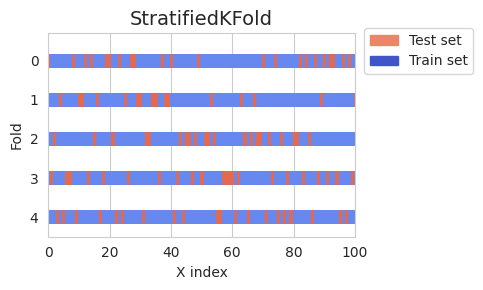

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline_lgbm, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=1, verbose=2
)

[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.4s
[CV] END .................................................... total time=   1.7s
[CV] END .................................................... total time=   1.9s
[CV] END .................................................... total time=   0.9s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    7.1s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline_lgbm,
    estimator_name='LightGBM Classifier', modifiers='KNNImp, Sc-Std, HT-Optuna'
)

LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


In [ ]:
print_classification_report(model_name='LightGBM Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, HT-Optuna')

mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - CV')

LightGBM Classifier - KNNImp, Sc-Std, HT-Optuna - Accuracy Score: 0.7992522289329882
              precision    recall  f1-score   support

           0    0.81877   0.76520   0.79108      3454
           1    0.78234   0.83286   0.80681      3500

    accuracy                        0.79925      6954
   macro avg    0.80056   0.79903   0.79894      6954
weighted avg    0.80044   0.79925   0.79900      6954



,Score
Metric,
Accuracy,0.799252
Precision (0),0.818704
Recall (0),0.765197
F1 Score (0),0.791000
Precision (1),0.782503
Recall (1),0.832857
F1 Score (1),0.806859
ROC AUC Score,0.881617
PR AUC Score,0.893941


XGBoost

In [ ]:
def objective_xgboost_cv(trial, X_train_cv, y_train_cv):
    param = {
        "n_jobs": -1, "random_state": 42, "verbosity": 0,
        "objective": 'binary:logistic', "eval_metric": 'aucpr',
        "eta": trial.suggest_float("eta", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-4, 1.0, log=True),
        "lambda": trial.suggest_float("lambda", 1e-4, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    xgb = XGBClassifier(**param)
    pipe = create_pipeline(steps=[
        ('preprocessing', preprocessing_knn_scaled),
        ('scaler', scaler_transformer),
        ('model', xgb)
    ])
    _, _, _, all_m = calculate_preds_metrics(
        X_train_cv=X_train_cv, y_train_cv=y_train_cv,
        cv_alg=kf, estimator=pipe,
        estimator_name='XGBoost Classifier',
        modifiers='KNNImp, Sc-Std, HT-Optuna'
    )
    return calculate_mean_metrics_cv(all_m)['Model_Metrics']['Accuracy']

In [ ]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(
    lambda trial: objective_xgboost_cv(trial, X_train_cv=X_train_cv, y_train_cv=y_train_cv),
    n_trials=50
)
print(f"Best XGBoost Accuracy: {study_xgb.best_trial.value:.5f}")
print("Best params:", study_xgb.best_trial.params)

xgboost_classifier = XGBClassifier(
    **study_xgb.best_trial.params,
    n_jobs=-1, random_state=42, verbosity=0,
    objective='binary:logistic', eval_metric='aucpr'
)
pipeline_xgb = create_pipeline(steps=[
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', xgboost_classifier)
])

[I 2026-06-09 22:23:53,090] A new study created in memory with name: no-name-b5b93371-4497-4500-b9f0-4d978fab1ee3


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:23:57,235] Trial 0 finished with value: 0.7960886273008911 and parameters: {'eta': 0.0026229322152749295, 'max_depth': 5, 'min_child_weight': 2.215176155009738, 'subsample': 0.5678370273516208, 'colsample_bytree': 0.7333578279474369, 'gamma': 0.005336174389051916, 'lambda': 0.0878467002932718, 'alpha': 0.00044880662245618317}. Best is trial 0 with value: 0.7960886273008911.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:02,786] Trial 1 finished with value: 0.7911997476066596 and parameters: {'eta': 0.004854536328793113, 'max_depth': 15, 'min_child_weight': 3.573057358921034, 'subsample': 0.768384524549903, 'colsample_bytree': 0.4625211380075142, 'gamma': 0.017272279728122158, 'lambda': 0.006776336639378726, 'alpha': 0.0003971472096983761}. Best is trial 0 with value: 0.7960886273008911.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:08,404] Trial 2 finished with value: 0.8001151286016478 and parameters: {'eta': 0.04309268148525719, 'max_depth': 9, 'min_child_weight': 2.7288252748835076, 'subsample': 0.7731884462913599, 'colsample_bytree': 0.669623822760944, 'gamma': 0.024717090476897213, 'lambda': 0.6105940504338575, 'alpha': 0.0004420048534502793}. Best is trial 2 with value: 0.8001151286016478.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:13,962] Trial 3 finished with value: 0.7998269450579004 and parameters: {'eta': 0.028903622399053325, 'max_depth': 8, 'min_child_weight': 0.016196310602862092, 'subsample': 0.7046269334519051, 'colsample_bytree': 0.9413989869874354, 'gamma': 0.014520385792980567, 'lambda': 0.00014876238010766058, 'alpha': 0.0001617012563832504}. Best is trial 2 with value: 0.8001151286016478.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:24,128] Trial 4 finished with value: 0.7956562485453764 and parameters: {'eta': 0.02184896272771392, 'max_depth': 14, 'min_child_weight': 0.07158774235345018, 'subsample': 0.6771727598293973, 'colsample_bytree': 0.7775383305833374, 'gamma': 0.0075436024170236395, 'lambda': 0.8911438018855531, 'alpha': 0.00022270888213542868}. Best is trial 2 with value: 0.8001151286016478.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:28,270] Trial 5 finished with value: 0.7936447563731904 and parameters: {'eta': 0.2513216848287956, 'max_depth': 6, 'min_child_weight': 1.1035045570974813, 'subsample': 0.99117492329483, 'colsample_bytree': 0.9038124368172442, 'gamma': 0.0003791649061420479, 'lambda': 0.04795063105869176, 'alpha': 0.0002383240525903611}. Best is trial 2 with value: 0.8001151286016478.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:35,363] Trial 6 finished with value: 0.8014089547915946 and parameters: {'eta': 0.09984010561688347, 'max_depth': 5, 'min_child_weight': 1.0739019998207617, 'subsample': 0.9957836436118537, 'colsample_bytree': 0.9177597786367886, 'gamma': 0.014944028292330148, 'lambda': 0.00022675143601032764, 'alpha': 0.0002410225330385774}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:46,661] Trial 7 finished with value: 0.7920624363198154 and parameters: {'eta': 0.020821544334008717, 'max_depth': 13, 'min_child_weight': 1.2766114185459205, 'subsample': 0.9622681239437934, 'colsample_bytree': 0.5241395211643319, 'gamma': 0.0007526031515868129, 'lambda': 0.0004960524893323851, 'alpha': 0.08990655590754487}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:24:52,682] Trial 8 finished with value: 0.7991081412368308 and parameters: {'eta': 0.006563004355342363, 'max_depth': 6, 'min_child_weight': 0.9075312746188913, 'subsample': 0.8729825529199908, 'colsample_bytree': 0.7930922183211375, 'gamma': 0.002765427361240469, 'lambda': 0.10973439689292373, 'alpha': 0.05900802329098661}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:01,298] Trial 9 finished with value: 0.7907679894905069 and parameters: {'eta': 0.07609789386664133, 'max_depth': 11, 'min_child_weight': 0.07730484920165737, 'subsample': 0.7528881519443502, 'colsample_bytree': 0.8702644164557973, 'gamma': 0.0030069335297234026, 'lambda': 0.2795914495705734, 'alpha': 0.011956013320032427}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:05,135] Trial 10 finished with value: 0.7766763727766888 and parameters: {'eta': 0.0011064817946614886, 'max_depth': 3, 'min_child_weight': 0.31675750123962454, 'subsample': 0.41268396133725127, 'colsample_bytree': 0.6084954296031387, 'gamma': 0.35574319454297615, 'lambda': 0.004027227100755409, 'alpha': 0.9959847657652633}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:12,249] Trial 11 finished with value: 0.7911996441667658 and parameters: {'eta': 0.14614727517308354, 'max_depth': 9, 'min_child_weight': 0.4289520054115851, 'subsample': 0.8673501690741492, 'colsample_bytree': 0.6313906639681963, 'gamma': 0.10800550409520945, 'lambda': 0.008394810571618446, 'alpha': 0.002294374618824685}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:19,559] Trial 12 finished with value: 0.7976708439143725 and parameters: {'eta': 0.06413833094349351, 'max_depth': 9, 'min_child_weight': 3.552425136191943, 'subsample': 0.8653688463507097, 'colsample_bytree': 0.9845198818414354, 'gamma': 0.04977448173870938, 'lambda': 0.0012292454512171798, 'alpha': 0.0023931592656106313}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:27,674] Trial 13 finished with value: 0.7960893513801468 and parameters: {'eta': 0.06461492280461154, 'max_depth': 3, 'min_child_weight': 0.3542626687041437, 'subsample': 0.5500900489576144, 'colsample_bytree': 0.6691308129390787, 'gamma': 0.7378668274345769, 'lambda': 0.019711240853276583, 'alpha': 0.0016081921183131287}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:34,273] Trial 14 finished with value: 0.7927804126217358 and parameters: {'eta': 0.126572224260374, 'max_depth': 11, 'min_child_weight': 4.93968898092245, 'subsample': 0.927400295174104, 'colsample_bytree': 0.827311074224847, 'gamma': 0.05901646340412612, 'lambda': 0.0015192946626756537, 'alpha': 0.0012142650684629967}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:42,712] Trial 15 finished with value: 0.7950824674552235 and parameters: {'eta': 0.03383470651715844, 'max_depth': 7, 'min_child_weight': 0.14149220921672834, 'subsample': 0.6130470529638335, 'colsample_bytree': 0.40522447140209356, 'gamma': 0.00011936109998074704, 'lambda': 0.00010878904663036104, 'alpha': 0.00010559513387493893}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:25:49,136] Trial 16 finished with value: 0.7909125984618488 and parameters: {'eta': 0.01128222503009009, 'max_depth': 4, 'min_child_weight': 1.7711176514344646, 'subsample': 0.8300714410304212, 'colsample_bytree': 0.5566881909071725, 'gamma': 0.193903977324434, 'lambda': 0.7502519804063372, 'alpha': 0.0046908631853264885}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:26:04,645] Trial 17 finished with value: 0.7746615705279055 and parameters: {'eta': 0.24383004118972132, 'max_depth': 11, 'min_child_weight': 0.6884016756914654, 'subsample': 0.45383452635731886, 'colsample_bytree': 0.7112068939771825, 'gamma': 0.0334438188110617, 'lambda': 0.00048460286913448, 'alpha': 0.0007325190682643846}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:26:17,196] Trial 18 finished with value: 0.7939320089578948 and parameters: {'eta': 0.04661984454005874, 'max_depth': 9, 'min_child_weight': 0.011785759441805311, 'subsample': 0.7703029096611304, 'colsample_bytree': 0.9956564641230852, 'gamma': 0.0007649987506318437, 'lambda': 0.030991633515140213, 'alpha': 0.008483820390136296}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:26:25,357] Trial 19 finished with value: 0.7947945942311571 and parameters: {'eta': 0.013565006530310742, 'max_depth': 5, 'min_child_weight': 2.2984439014343834, 'subsample': 0.9250754641888034, 'colsample_bytree': 0.8473803714824908, 'gamma': 0.0157514396917015, 'lambda': 0.41146083759962127, 'alpha': 0.0006664985350374918}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:26:39,421] Trial 20 finished with value: 0.7828592855406545 and parameters: {'eta': 0.11719203940073894, 'max_depth': 12, 'min_child_weight': 0.14127304355404383, 'subsample': 0.668346738525555, 'colsample_bytree': 0.7275971663347649, 'gamma': 0.00179248350727225, 'lambda': 0.1648762829797996, 'alpha': 0.014316206759265735}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:26:50,894] Trial 21 finished with value: 0.7992518192491298 and parameters: {'eta': 0.031976706575414404, 'max_depth': 8, 'min_child_weight': 0.0163566261926663, 'subsample': 0.7163667460410551, 'colsample_bytree': 0.9185870775329585, 'gamma': 0.015081390740418218, 'lambda': 0.00012230658606243554, 'alpha': 0.00011408276672001226}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:27:01,467] Trial 22 finished with value: 0.7979578896192894 and parameters: {'eta': 0.034603735980677376, 'max_depth': 8, 'min_child_weight': 0.02224583074663164, 'subsample': 0.8090228711667048, 'colsample_bytree': 0.9375742335490357, 'gamma': 0.007862448787854156, 'lambda': 0.00026136330539085364, 'alpha': 0.0002282915697430518}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:27:15,009] Trial 23 finished with value: 0.7956580070235688 and parameters: {'eta': 0.09429188712771004, 'max_depth': 7, 'min_child_weight': 0.03897088097423266, 'subsample': 0.6362904656627026, 'colsample_bytree': 0.9276018540499879, 'gamma': 0.030305436653343145, 'lambda': 0.0016580455897396136, 'alpha': 0.00010354855381676569}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:27:24,956] Trial 24 finished with value: 0.7968073276820672 and parameters: {'eta': 0.016288817818832242, 'max_depth': 10, 'min_child_weight': 0.5670453815858598, 'subsample': 0.5288267627586669, 'colsample_bytree': 0.9643821726744535, 'gamma': 0.16406660490595873, 'lambda': 0.00026717540456323114, 'alpha': 0.000826596700456852}. Best is trial 6 with value: 0.8014089547915946.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:27:35,152] Trial 25 finished with value: 0.8022720572643252 and parameters: {'eta': 0.04742110863356876, 'max_depth': 7, 'min_child_weight': 0.17985838495063206, 'subsample': 0.7329898248945269, 'colsample_bytree': 0.8812040131440629, 'gamma': 0.07464237653315425, 'lambda': 0.0008888549367918053, 'alpha': 0.0003099491385844728}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:27:43,954] Trial 26 finished with value: 0.7965196613377881 and parameters: {'eta': 0.17012189891926008, 'max_depth': 6, 'min_child_weight': 0.22327344115801984, 'subsample': 0.7966659941119715, 'colsample_bytree': 0.8767989702758953, 'gamma': 0.06317430323494778, 'lambda': 0.0007278179994227402, 'alpha': 0.0004715418725793063}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:27:52,014] Trial 27 finished with value: 0.8012653802191891 and parameters: {'eta': 0.05040993919723345, 'max_depth': 5, 'min_child_weight': 1.4759092932506013, 'subsample': 0.9200754033861205, 'colsample_bytree': 0.8023878252124923, 'gamma': 0.5045073776993056, 'lambda': 0.0031648503969516064, 'alpha': 0.0037427240935608867}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:28:01,195] Trial 28 finished with value: 0.7966645806288112 and parameters: {'eta': 0.0593353217480332, 'max_depth': 4, 'min_child_weight': 1.4310096783071808, 'subsample': 0.9963586068379342, 'colsample_bytree': 0.7967335791828127, 'gamma': 0.9631506225952471, 'lambda': 0.003295587617785277, 'alpha': 0.019774062272241124}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:28:13,841] Trial 29 finished with value: 0.7979574758597149 and parameters: {'eta': 0.18418068852721198, 'max_depth': 5, 'min_child_weight': 0.7857338995581066, 'subsample': 0.9305642528758282, 'colsample_bytree': 0.7666242607063483, 'gamma': 0.38345434483033675, 'lambda': 0.002677009864862157, 'alpha': 0.04061267399861066}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:28:21,918] Trial 30 finished with value: 0.7917751837351111 and parameters: {'eta': 0.010452501832563278, 'max_depth': 4, 'min_child_weight': 0.20603250011462307, 'subsample': 0.8978374429055265, 'colsample_bytree': 0.8285177019180946, 'gamma': 0.4068253853006337, 'lambda': 0.011399163300191308, 'alpha': 0.004449698670178505}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:28:32,108] Trial 31 finished with value: 0.7993962213406844 and parameters: {'eta': 0.046935724007983945, 'max_depth': 7, 'min_child_weight': 2.687818259815229, 'subsample': 0.8387806110374846, 'colsample_bytree': 0.6663350712434636, 'gamma': 0.11063817091338872, 'lambda': 0.00025025061017483176, 'alpha': 0.00034709316568127076}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:28:40,913] Trial 32 finished with value: 0.7972389823583261 and parameters: {'eta': 0.10929617698290389, 'max_depth': 6, 'min_child_weight': 1.9330643523013922, 'subsample': 0.9557463907274003, 'colsample_bytree': 0.8848679289393322, 'gamma': 0.029697071449199492, 'lambda': 0.0008203603460321155, 'alpha': 0.0004280874611717225}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:28:47,119] Trial 33 finished with value: 0.8009782310743784 and parameters: {'eta': 0.04265367962870356, 'max_depth': 5, 'min_child_weight': 3.473271003404625, 'subsample': 0.7314870020543449, 'colsample_bytree': 0.7515381242595843, 'gamma': 0.00857098786026557, 'lambda': 0.00037943941842777883, 'alpha': 0.0034037549613589744}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:28:54,856] Trial 34 finished with value: 0.8002589100538404 and parameters: {'eta': 0.08325067331561235, 'max_depth': 5, 'min_child_weight': 4.415928763688757, 'subsample': 0.7282758078854046, 'colsample_bytree': 0.7520005076325766, 'gamma': 0.007449078916832282, 'lambda': 0.0005230695428943196, 'alpha': 0.004400998382418823}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:29:00,761] Trial 35 finished with value: 0.7983896477354421 and parameters: {'eta': 0.020517379091176752, 'max_depth': 5, 'min_child_weight': 3.4785218825080135, 'subsample': 0.6058283331569017, 'colsample_bytree': 0.8144040761751296, 'gamma': 0.0031745945553780268, 'lambda': 0.0002289508392655152, 'alpha': 0.0014597741732265287}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:29:08,008] Trial 36 finished with value: 0.7976706370345852 and parameters: {'eta': 0.04647011108916846, 'max_depth': 4, 'min_child_weight': 0.5568371400715171, 'subsample': 0.679246968728825, 'colsample_bytree': 0.7072825378527422, 'gamma': 0.0049968769289310405, 'lambda': 0.0051606521550805725, 'alpha': 0.19334170579540802}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:29:17,770] Trial 37 finished with value: 0.7901931740014172 and parameters: {'eta': 0.02594584696472711, 'max_depth': 3, 'min_child_weight': 1.5800406723464742, 'subsample': 0.9668895007917968, 'colsample_bytree': 0.8564402921366017, 'gamma': 0.2191036950832505, 'lambda': 0.0022201800161964686, 'alpha': 0.0032421771825588332}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:29:25,430] Trial 38 finished with value: 0.7949382722434561 and parameters: {'eta': 0.0025952260323697076, 'max_depth': 7, 'min_child_weight': 0.9951540379679206, 'subsample': 0.8985698866709404, 'colsample_bytree': 0.9583534287984212, 'gamma': 0.01096865835648832, 'lambda': 0.000908907592410319, 'alpha': 0.006623398132215822}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:29:35,024] Trial 39 finished with value: 0.7752379376154 and parameters: {'eta': 0.2959597430998922, 'max_depth': 6, 'min_child_weight': 0.06744058399112583, 'subsample': 0.49883901112240925, 'colsample_bytree': 0.899088915729624, 'gamma': 0.09390671343356685, 'lambda': 0.00018881531683248812, 'alpha': 0.030832878690009145}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:29:41,848] Trial 40 finished with value: 0.7981023951507378 and parameters: {'eta': 0.05669078736601645, 'max_depth': 4, 'min_child_weight': 1.2155707274011858, 'subsample': 0.7461496129377252, 'colsample_bytree': 0.7538092129529925, 'gamma': 0.02039359378361596, 'lambda': 0.0004893997064334077, 'alpha': 0.0002671856985161378}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:29:50,309] Trial 41 finished with value: 0.798533325747741 and parameters: {'eta': 0.07598799684617369, 'max_depth': 5, 'min_child_weight': 4.586223459578117, 'subsample': 0.7230246710072292, 'colsample_bytree': 0.7479806057211812, 'gamma': 0.0077282607946602, 'lambda': 0.0004692318742727608, 'alpha': 0.0011149398308614052}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:30:00,466] Trial 42 finished with value: 0.8001151286016478 and parameters: {'eta': 0.08273846493155877, 'max_depth': 5, 'min_child_weight': 2.4416853599064803, 'subsample': 0.7884776143228073, 'colsample_bytree': 0.7881733879114198, 'gamma': 0.0014855765633036673, 'lambda': 0.00038112980681869114, 'alpha': 0.006934627572997643}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:30:14,207] Trial 43 finished with value: 0.7982447284444192 and parameters: {'eta': 0.03835663717311126, 'max_depth': 15, 'min_child_weight': 3.3413001994146376, 'subsample': 0.6947850108965565, 'colsample_bytree': 0.6942694744206196, 'gamma': 0.004947906765016174, 'lambda': 0.001242795048941688, 'alpha': 0.0022815796316253104}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:30:21,271] Trial 44 finished with value: 0.799970726510093 and parameters: {'eta': 0.09761020687923562, 'max_depth': 6, 'min_child_weight': 4.79906233679673, 'subsample': 0.7444409029607488, 'colsample_bytree': 0.8437845356520269, 'gamma': 0.01037346497408477, 'lambda': 0.0007883569632974982, 'alpha': 0.00016643308840327579}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:30:31,661] Trial 45 finished with value: 0.8009776104350165 and parameters: {'eta': 0.025349686972359425, 'max_depth': 8, 'min_child_weight': 3.0693117129316785, 'subsample': 0.6403268801453764, 'colsample_bytree': 0.8024778491335351, 'gamma': 0.003508719090163856, 'lambda': 0.0003644942790567673, 'alpha': 0.12569650398861207}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:30:41,430] Trial 46 finished with value: 0.7998272553775815 and parameters: {'eta': 0.0265553653447942, 'max_depth': 8, 'min_child_weight': 2.8222368025627254, 'subsample': 0.6531064034735045, 'colsample_bytree': 0.8084517885571813, 'gamma': 0.001660291741537975, 'lambda': 0.00016197258288890443, 'alpha': 0.3482352854214548}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:30:49,489] Trial 47 finished with value: 0.7998273588174751 and parameters: {'eta': 0.018280067867796665, 'max_depth': 7, 'min_child_weight': 1.7785332298809375, 'subsample': 0.6156352731942546, 'colsample_bytree': 0.9010416761685726, 'gamma': 0.0010199070256610076, 'lambda': 0.00206657951569084, 'alpha': 0.1121127516418685}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:30:58,562] Trial 48 finished with value: 0.8019853218790891 and parameters: {'eta': 0.005361279639163872, 'max_depth': 8, 'min_child_weight': 1.2913527114654957, 'subsample': 0.5911859339400993, 'colsample_bytree': 0.7798259035254543, 'gamma': 0.00035278029953816794, 'lambda': 0.0003361306510217315, 'alpha': 0.8257468332217331}. Best is trial 25 with value: 0.8022720572643252.


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:31:05,265] Trial 49 finished with value: 0.7824290790229067 and parameters: {'eta': 0.009783354465775053, 'max_depth': 3, 'min_child_weight': 1.0576780179898886, 'subsample': 0.5870165162191894, 'colsample_bytree': 0.7743626813478743, 'gamma': 0.00034822596971162666, 'lambda': 0.0060418626398023615, 'alpha': 0.3435111641250252}. Best is trial 25 with value: 0.8022720572643252.


Best XGBoost Accuracy: 0.80227
Best params: {'eta': 0.04742110863356876, 'max_depth': 7, 'min_child_weight': 0.17985838495063206, 'subsample': 0.7329898248945269, 'colsample_bytree': 0.8812040131440629, 'gamma': 0.07464237653315425, 'lambda': 0.0008888549367918053, 'alpha': 0.0003099491385844728}


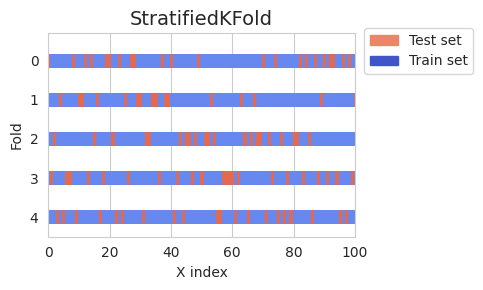

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline_xgb, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline_xgb,
    estimator_name='XGBoost Classifier', modifiers='KNNImp, Sc-Std, HT-Optuna'
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   11.5s finished


XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


In [ ]:
print_classification_report(model_name='XGBoost Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, HT-Optuna')

XGBoost Classifier - KNNImp, Sc-Std, HT-Optuna - Accuracy Score: 0.8022720736266897
              precision    recall  f1-score   support

           0    0.81357   0.78083   0.79687      3454
           1    0.79198   0.82343   0.80740      3500

    accuracy                        0.80227      6954
   macro avg    0.80278   0.80213   0.80213      6954
weighted avg    0.80270   0.80227   0.80217      6954



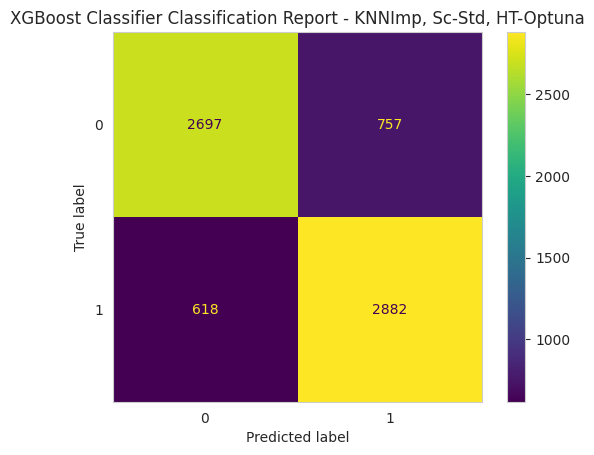

In [ ]:
plot_confusion_matrix(model_name='XGBoost Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Sc-Std, HT-Optuna')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - CV')

,Score
Metric,
Accuracy,0.802272
Precision (0),0.813633
Recall (0),0.780829
F1 Score (0),0.796752
Precision (1),0.792295
Recall (1),0.823429
F1 Score (1),0.807441
ROC AUC Score,0.882838
PR AUC Score,0.894934


Logistic Regression

In [ ]:
def objective_logreg_cv(trial, X_train_cv, y_train_cv):
    param = {
        "n_jobs": -1, "max_iter": 1000,
        "C":     trial.suggest_float("C", 1e-3, 10.0, log=True),
        "solver": trial.suggest_categorical("solver", ['lbfgs', 'saga', 'liblinear']),
        "penalty": trial.suggest_categorical("penalty", ['l2', 'l1']),
    }

    if param['solver'] == 'lbfgs' and param['penalty'] == 'l1':
        return 0.0

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = LogisticRegression(**param)
    pipe = create_pipeline(steps=[
        ('preprocessing', preprocessing_knn_scaled),
        ('scaler', scaler_transformer),
        ('model', lr)
    ])

    _, _, _, all_m = calculate_preds_metrics(
        X_train_cv=X_train_cv, y_train_cv=y_train_cv,
        cv_alg=kf, estimator=pipe,
        estimator_name='Logistic Regression',
        modifiers='KNNImp, Sc-Std, HT-Optuna'
    )
    return calculate_mean_metrics_cv(all_m)['Model_Metrics']['Accuracy']

In [ ]:
study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(
    lambda trial: objective_logreg_cv(trial, X_train_cv=X_train_cv, y_train_cv=y_train_cv),
    n_trials=30
)
print(f"Best LR Accuracy: {study_lr.best_trial.value:.5f}")
print("Best params:", study_lr.best_trial.params)

[I 2026-06-09 22:33:19,485] A new study created in memory with name: no-name-2ee45657-80cf-40d8-adf2-43eb4c509faf
[I 2026-06-09 22:33:19,490] Trial 0 finished with value: 0.0 and parameters: {'C': 0.0016693087634847429, 'solver': 'lbfgs', 'penalty': 'l1'}. Best is trial 0 with value: 0.0.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:33:38,377] Trial 1 finished with value: 0.7926388034073102 and parameters: {'C': 6.818484152331457, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.
[I 2026-06-09 22:33:38,380] Trial 2 finished with value: 0.0 and parameters: {'C': 0.05797575499600717, 'solver': 'lbfgs', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-09 22:33:57,266] Trial 3 finished with value: 0.7926388034073102 and parameters: {'C': 7.630047223120444, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
[I 2026-06-09 22:34:00,224] Trial 4 finished with value: 0.7832907333371262 and parameters: {'C': 0.018215768633468597, 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
[I 2026-06-09 22:34:03,170] Trial 5 finished with value: 0.7792646457959441 and parameters: {'C': 0.005835531155530427, 'solver': 'liblinear', 'penalty': 'l2'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:34:15,553] Trial 6 finished with value: 0.7923512405029248 and parameters: {'C': 1.2815217604348084, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:34:19,686] Trial 7 finished with value: 0.7722176996002048 and parameters: {'C': 0.009863188834025635, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.
[I 2026-06-09 22:34:19,688] Trial 8 finished with value: 0.0 and parameters: {'C': 1.3215300585382088, 'solver': 'lbfgs', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.
[I 2026-06-09 22:34:19,689] Trial 9 finished with value: 0.0 and parameters: {'C': 0.032485513769042844, 'solver': 'lbfgs', 'penalty': 'l1'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:34:25,579] Trial 10 finished with value: 0.787750027152972 and parameters: {'C': 0.24705985836136127, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-09 22:34:43,646] Trial 11 finished with value: 0.7926388034073102 and parameters: {'C': 9.258923766760796, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 1 with value: 0.7926388034073102.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-09 22:35:02,366] Trial 12 finished with value: 0.7927825848595028 and parameters: {'C': 8.862818160705945, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:35:13,973] Trial 13 finished with value: 0.7924950219551175 and parameters: {'C': 2.4394823833335333, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:35:20,478] Trial 14 finished with value: 0.7901945187200348 and parameters: {'C': 0.47894448127557654, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:35:32,357] Trial 15 finished with value: 0.7926388034073101 and parameters: {'C': 4.130192444278377, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
[I 2026-06-09 22:35:35,319] Trial 16 finished with value: 0.7893317265669851 and parameters: {'C': 0.32822964230158064, 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:35:47,572] Trial 17 finished with value: 0.7924950219551175 and parameters: {'C': 3.583704335289583, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:35:57,051] Trial 18 finished with value: 0.7913449772173634 and parameters: {'C': 0.9157787589288039, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
[I 2026-06-09 22:36:00,811] Trial 19 finished with value: 0.7926388034073101 and parameters: {'C': 8.393845745178462, 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:36:08,940] Trial 20 finished with value: 0.787893705165271 and parameters: {'C': 0.13467432147221312, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-09 22:36:26,433] Trial 21 finished with value: 0.7927825848595028 and parameters: {'C': 9.184367429869825, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:36:38,512] Trial 22 finished with value: 0.7924950219551175 and parameters: {'C': 2.777145071522123, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:36:50,347] Trial 23 finished with value: 0.7926388034073101 and parameters: {'C': 4.5334680027391725, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:37:01,715] Trial 24 finished with value: 0.7923512405029248 and parameters: {'C': 1.7652668516162056, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-09 22:37:18,980] Trial 25 finished with value: 0.7927825848595028 and parameters: {'C': 9.231681889356345, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:37:27,020] Trial 26 finished with value: 0.7906259665165065 and parameters: {'C': 0.5870639473493843, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:37:38,714] Trial 27 finished with value: 0.7926388034073101 and parameters: {'C': 4.42626538867009, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(
[I 2026-06-09 22:37:41,866] Trial 28 finished with value: 0.7919198961463467 and parameters: {'C': 2.114592918051926, 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.
[I 2026-06-09 22:37:41,876] Trial 29 finished with value: 0.0 and parameters: {'C': 9.994993515259736, 'solver': 'lbfgs', 'penalty': 'l1'}. Best is trial 12 with value: 0.7927825848595028.


Best LR Accuracy: 0.79278
Best params: {'C': 8.862818160705945, 'solver': 'saga', 'penalty': 'l1'}


In [ ]:
logistic_regressor = LogisticRegression(
    **study_lr.best_trial.params,
    n_jobs=-1, max_iter=1000
)
pipeline_lr = create_pipeline(steps=[
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', logistic_regressor)
])

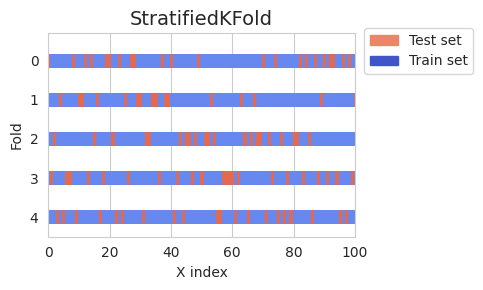

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline_lr, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   18.4s finished


In [ ]:
all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline_lr,
    estimator_name='Logistic Regression', modifiers='KNNImp, Sc-Std, HT-Optuna'
)

Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 1:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 3:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 4:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
print_classification_report(model_name='Logistic Regression',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, HT-Optuna')

Logistic Regression - KNNImp, Sc-Std, HT-Optuna - Accuracy Score: 0.7927811331607708
              precision    recall  f1-score   support

           0    0.80344   0.77157   0.78718      3454
           1    0.78306   0.81371   0.79809      3500

    accuracy                        0.79278      6954
   macro avg    0.79325   0.79264   0.79264      6954
weighted avg    0.79318   0.79278   0.79267      6954



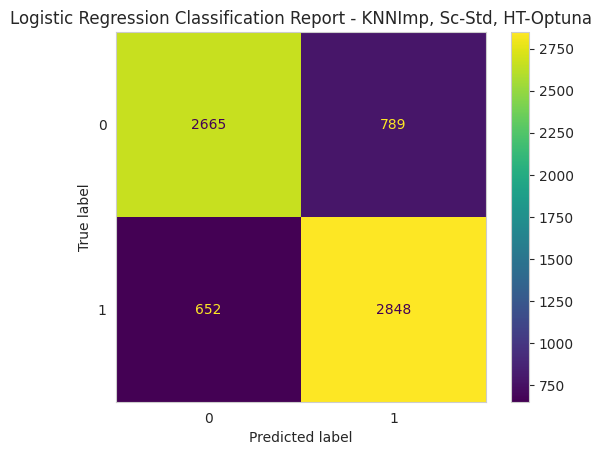

In [ ]:
plot_confusion_matrix(model_name='Logistic Regression',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Sc-Std, HT-Optuna')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - CV')

,Score
Metric,
Accuracy,0.792783
Precision (0),0.803505
Recall (0),0.771573
F1 Score (0),0.787175
Precision (1),0.783106
Recall (1),0.813714
F1 Score (1),0.798084
ROC AUC Score,0.875787
PR AUC Score,0.884549


Random Forest

In [ ]:
def objective_rf_cv(trial, X_train_cv, y_train_cv):
    param = {
        "n_jobs": -1, "random_state": 42, "verbose": 0,
        "n_estimators":        trial.suggest_int("n_estimators", 50, 500),
        "max_depth":           trial.suggest_categorical("max_depth", [None] + list(range(3, 31, 3))),
        "min_samples_split":   trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":    trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":        trial.suggest_categorical("max_features", ['sqrt', 'log2', None]),
        "bootstrap":           trial.suggest_categorical("bootstrap", [True, False]),
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestClassifier(**param)
    pipe = create_pipeline(steps=[
        ('preprocessing', preprocessing_knn_scaled),
        ('scaler', scaler_transformer),
        ('model', rf)
    ])

    _, _, _, all_m = calculate_preds_metrics(
        X_train_cv=X_train_cv, y_train_cv=y_train_cv,
        cv_alg=kf, estimator=pipe,
        estimator_name='Random Forest Classifier',
        modifiers='KNNImp, Sc-Std, HT-Optuna'
    )
    return calculate_mean_metrics_cv(all_m)['Model_Metrics']['Accuracy']

In [ ]:
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(
    lambda trial: objective_rf_cv(trial, X_train_cv=X_train_cv, y_train_cv=y_train_cv),
    n_trials=30
)
print(f"Best RF Accuracy: {study_rf.best_trial.value:.5f}")
print("Best params:", study_rf.best_trial.params)

[I 2026-06-09 22:39:07,794] A new study created in memory with name: no-name-c5b3cd54-bbfb-4cf7-83d8-a7cc88611ed2


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:39:12,159] Trial 0 finished with value: 0.7976710507941599 and parameters: {'n_estimators': 51, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.7976710507941599.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:39:19,990] Trial 1 finished with value: 0.7970953043460272 and parameters: {'n_estimators': 109, 'max_depth': 27, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.7976710507941599.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:39:44,140] Trial 2 finished with value: 0.7663239013390294 and parameters: {'n_estimators': 180, 'max_depth': 27, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.7976710507941599.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:39:59,734] Trial 3 finished with value: 0.8011220125265712 and parameters: {'n_estimators': 421, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 3 with value: 0.8011220125265712.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:40:16,212] Trial 4 finished with value: 0.7988210955319138 and parameters: {'n_estimators': 493, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 3 with value: 0.8011220125265712.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:40:32,523] Trial 5 finished with value: 0.8006904612902058 and parameters: {'n_estimators': 420, 'max_depth': 21, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 3 with value: 0.8011220125265712.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:40:44,518] Trial 6 finished with value: 0.8011221159664647 and parameters: {'n_estimators': 295, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:41:01,451] Trial 7 finished with value: 0.797095614665708 and parameters: {'n_estimators': 384, 'max_depth': 18, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:41:15,232] Trial 8 finished with value: 0.7904807369058025 and parameters: {'n_estimators': 240, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:41:25,579] Trial 9 finished with value: 0.7824286652633321 and parameters: {'n_estimators': 307, 'max_depth': 6, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:41:52,246] Trial 10 finished with value: 0.7943620085958552 and parameters: {'n_estimators': 287, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:42:06,294] Trial 11 finished with value: 0.8006906681699931 and parameters: {'n_estimators': 376, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:42:18,809] Trial 12 finished with value: 0.7424514220399381 and parameters: {'n_estimators': 495, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:42:31,142] Trial 13 finished with value: 0.7999721746686044 and parameters: {'n_estimators': 323, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:43:11,353] Trial 14 finished with value: 0.7916301610041945 and parameters: {'n_estimators': 429, 'max_depth': 24, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:43:21,944] Trial 15 finished with value: 0.7979583033788641 and parameters: {'n_estimators': 227, 'max_depth': None, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:43:35,366] Trial 16 finished with value: 0.7995402096726645 and parameters: {'n_estimators': 347, 'max_depth': 12, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 6 with value: 0.8011221159664647.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:43:51,189] Trial 17 finished with value: 0.8012657939787639 and parameters: {'n_estimators': 434, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:44:00,540] Trial 18 finished with value: 0.8004028983858206 and parameters: {'n_estimators': 185, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:44:11,703] Trial 19 finished with value: 0.8011221159664649 and parameters: {'n_estimators': 259, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:44:19,096] Trial 20 finished with value: 0.7983903718146977 and parameters: {'n_estimators': 145, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:44:30,088] Trial 21 finished with value: 0.8009783345142722 and parameters: {'n_estimators': 251, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:44:41,975] Trial 22 finished with value: 0.8008342427423984 and parameters: {'n_estimators': 278, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:44:51,476] Trial 23 finished with value: 0.8005463695183321 and parameters: {'n_estimators': 205, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:45:04,161] Trial 24 finished with value: 0.7979587171384388 and parameters: {'n_estimators': 352, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:45:20,686] Trial 25 finished with value: 0.7998277725770497 and parameters: {'n_estimators': 466, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:45:48,119] Trial 26 finished with value: 0.7947937667120077 and parameters: {'n_estimators': 292, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:45:59,093] Trial 27 finished with value: 0.8001151286016478 and parameters: {'n_estimators': 269, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:46:08,613] Trial 28 finished with value: 0.7437457654293531 and parameters: {'n_estimators': 329, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


[I 2026-06-09 22:46:14,790] Trial 29 finished with value: 0.8002592203735215 and parameters: {'n_estimators': 121, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 17 with value: 0.8012657939787639.


Best RF Accuracy: 0.80127
Best params: {'n_estimators': 434, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}


In [ ]:
random_forest_classifier = RandomForestClassifier(
    **study_rf.best_trial.params,
    n_jobs=-1, random_state=42, verbose=0
)
pipeline_rf = create_pipeline(steps=[
    ('preprocessing', preprocessing_knn_scaled),
    ('scaler', scaler_transformer),
    ('model', random_forest_classifier)
])

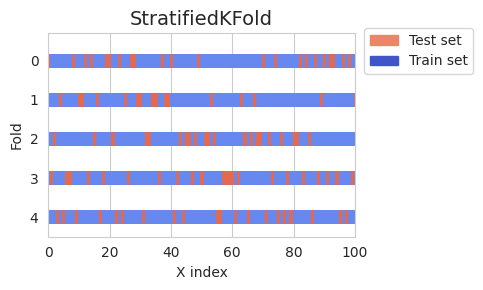

In [ ]:
plot_skfold(cv=stratified_k_fold, X=X_train_cv, y=y_train_cv, n_splits=5)

In [ ]:
cv_results = cross_validate(
    estimator=pipeline_rf, X=X_train_cv, y=y_train_cv,
    cv=stratified_k_fold, return_estimator=True, return_indices=True,
    scoring=scoring_dict, n_jobs=-1, verbose=2
)

all_y_true, all_y_pred, all_y_pred_proba, all_metrics = calculate_preds_metrics(
    X_train_cv=X_train_cv, y_train_cv=y_train_cv,
    cv_alg=stratified_k_fold, estimator=pipeline_rf,
    estimator_name='Random Forest Classifier', modifiers='KNNImp, Sc-Std, HT-Optuna'
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   18.2s finished


Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 1:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 2:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 3:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 4:
Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - Fold 5:


In [ ]:
print_classification_report(model_name='Random Forest Classifier',
                             y_true=all_y_true, y_pred=all_y_pred,
                             modifiers='KNNImp, Sc-Std, HT-Optuna')

Random Forest Classifier - KNNImp, Sc-Std, HT-Optuna - Accuracy Score: 0.8012654587287892
              precision    recall  f1-score   support

           0    0.80778   0.78720   0.79736      3454
           1    0.79515   0.81514   0.80502      3500

    accuracy                        0.80127      6954
   macro avg    0.80147   0.80117   0.80119      6954
weighted avg    0.80143   0.80127   0.80122      6954



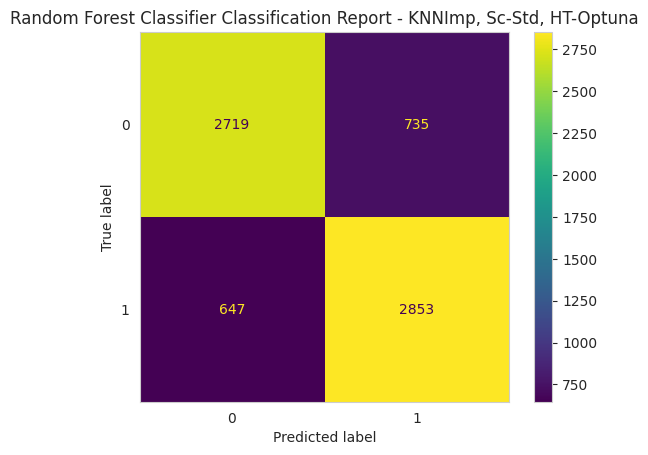

In [ ]:
plot_confusion_matrix(model_name='Random Forest Classifier',
                      y_true=all_y_true, y_pred=all_y_pred,
                      modifiers='KNNImp, Sc-Std, HT-Optuna')

In [ ]:
mean_metrics = calculate_mean_metrics_cv(all_metrics=all_metrics)
model_performance_df = add_to_df(
    metrics_dict=mean_metrics['Model_Metrics'],
    estimator_name=mean_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs('Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - CV')

,Score
Metric,
Accuracy,0.801266
Precision (0),0.807789
Recall (0),0.787200
F1 Score (0),0.797269
Precision (1),0.795405
Recall (1),0.815143
F1 Score (1),0.805068
ROC AUC Score,0.880546
PR AUC Score,0.891977


HT Summary

{'LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - CV': 'red', 'Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - CV': 'orange', 'Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - CV': 'yellow', 'XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - CV': 'blue'}


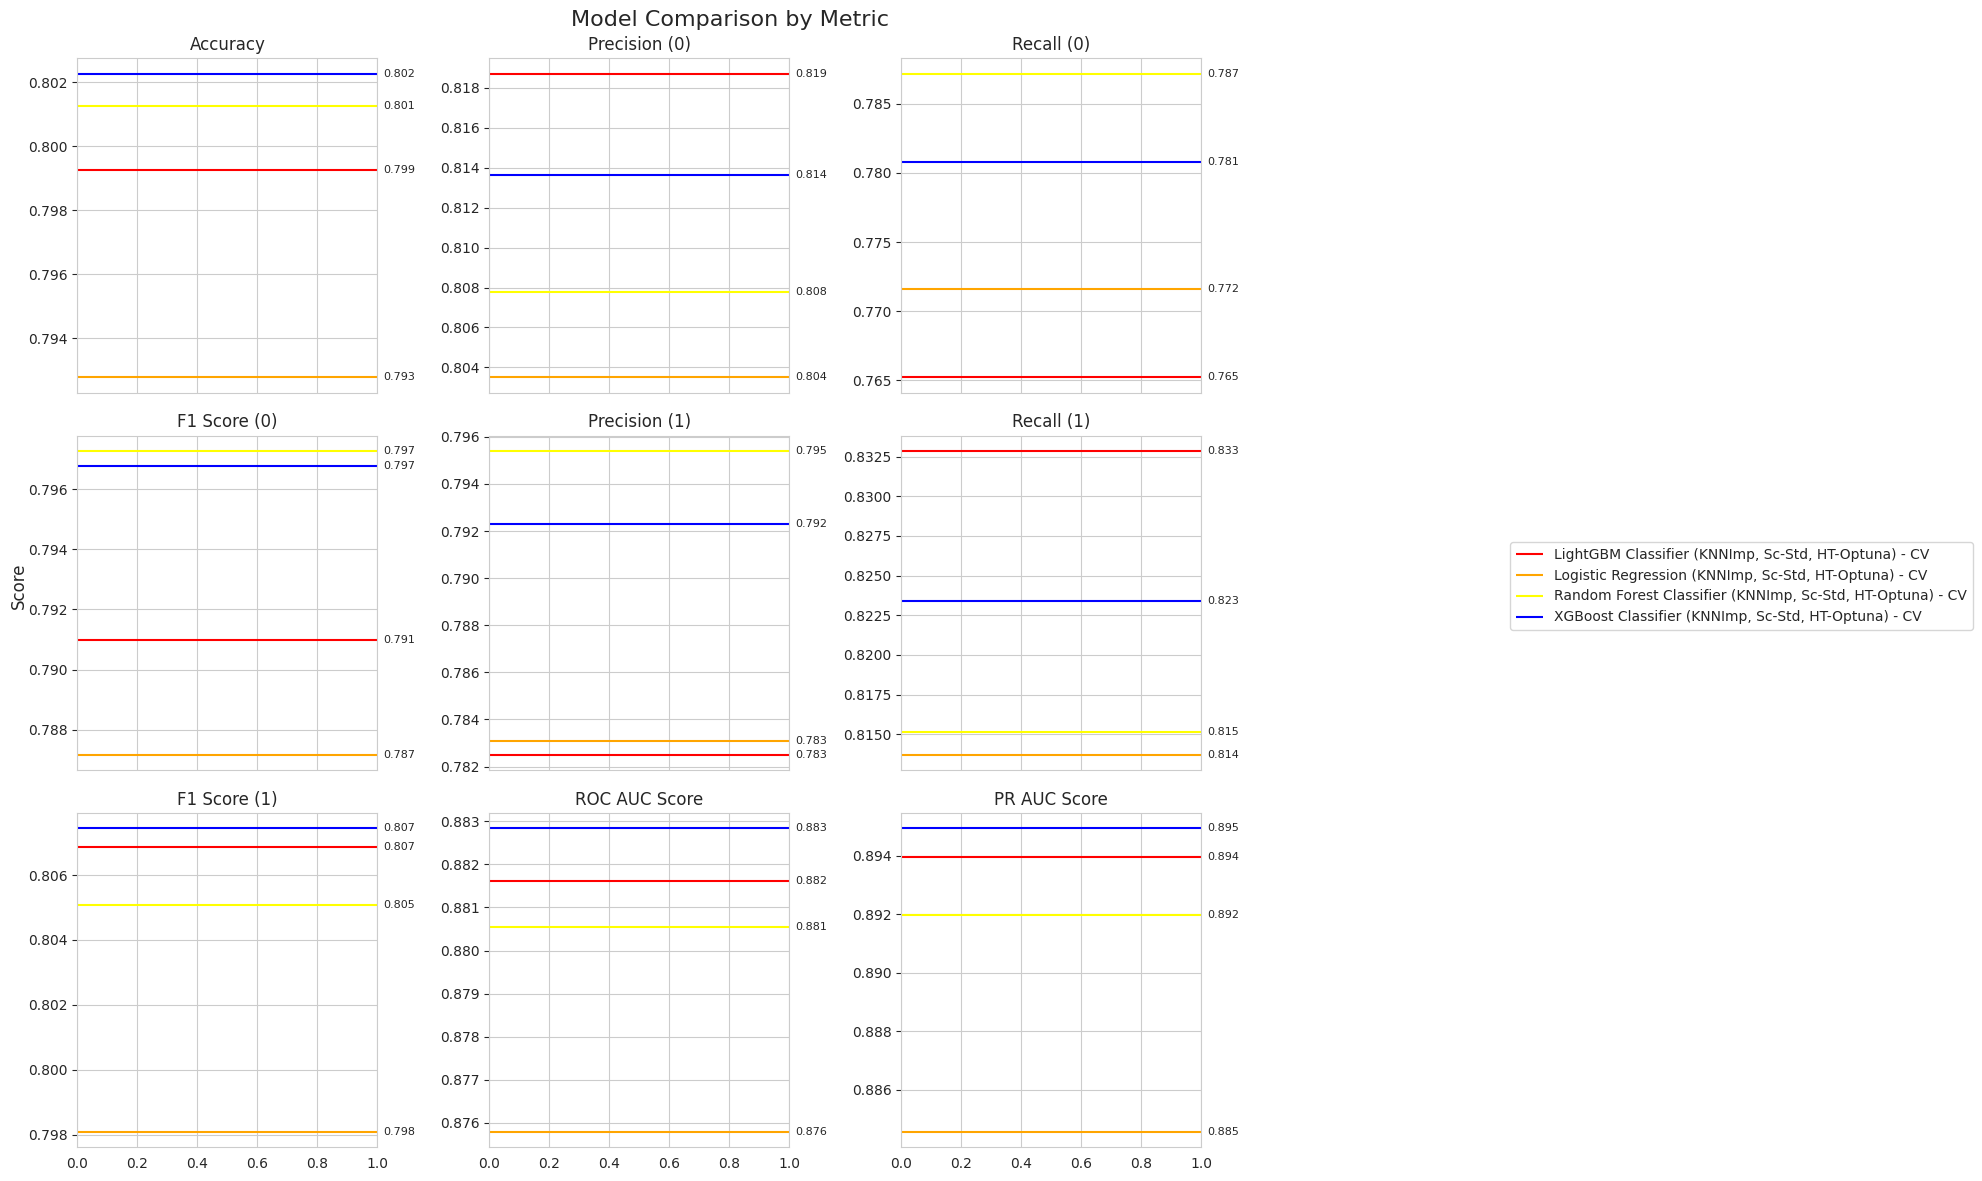

In [ ]:
model_performance_df.loc[model_names_cv_ht]
plot_metrics(metrics_df=model_performance_df.loc[model_names_cv_ht])

LightGBM grew 0.796 -> 0.802 - Optuna found better num_leaves, lambda_l1/l2, learning_rate that reduced overfitting without losing accuracy.

Overfitting Analysis

In [ ]:
overfit_results = []

tuned_pipelines = {
    'LightGBM':        pipeline_lgbm,
    'XGBoost':         pipeline_xgb,
    'Logistic Reg.':   pipeline_lr,
    'Random Forest':   pipeline_rf,
}

for name, pipe in tuned_pipelines.items():
    pipe.fit(X=X_train_cv, y=y_train_cv)
    train_acc = accuracy_score(y_true=y_train_cv, y_pred=pipe.predict(X_train_cv))
    cv_acc    = model_performance_df.loc[
        (f'{name.replace("Logistic Reg.", "Logistic Regression").replace("LightGBM", "LightGBM Classifier").replace("XGBoost", "XGBoost Classifier").replace("Random Forest", "Random Forest Classifier")} (KNNImp, Sc-Std, HT-Optuna) - CV',
         'Accuracy'), 'Score'
    ]
    overfit_results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'CV Accuracy': cv_acc,
        'Overfit Gap': train_acc - cv_acc
    })

overfit_df = pd.DataFrame(overfit_results).set_index('Model')
print(overfit_df.round(5))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


               Train Accuracy  CV Accuracy  Overfit Gap
Model                                                  
LightGBM              0.82485      0.79925      0.02560
XGBoost               0.85792      0.80227      0.05565
Logistic Reg.         0.79393      0.79278      0.00115
Random Forest         0.84858      0.80127      0.04731


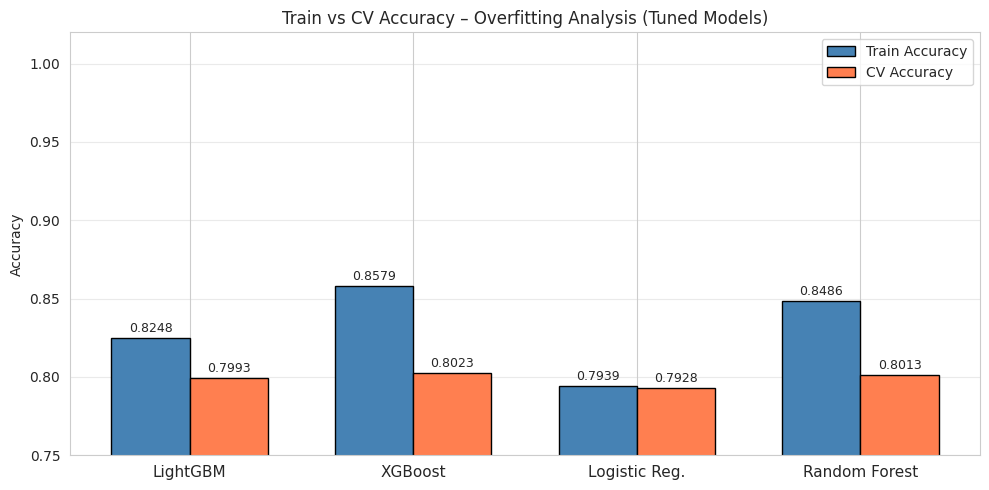

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(overfit_df))
width = 0.35

bars_train = ax.bar(x - width/2, overfit_df['Train Accuracy'], width,
                    label='Train Accuracy', color='steelblue', edgecolor='black')
bars_cv    = ax.bar(x + width/2, overfit_df['CV Accuracy'], width,
                    label='CV Accuracy', color='coral', edgecolor='black')

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars_cv:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(overfit_df.index, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs CV Accuracy – Overfitting Analysis (Tuned Models)')
ax.set_ylim(0.75, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

since there is accuracy on the train and on the validation dataset, and the biggest gap is with ensemble models, since trees without a strict depth limit remember data

Best Model

In [ ]:
best_pipeline_name_key = model_performance_df.loc[model_names_cv_ht].xs(
    'Accuracy', level='Metric')['Score'].idxmax()
print(f"Best model: {best_pipeline_name_key}")

pipeline_map = {
    'LightGBM Classifier (KNNImp, Sc-Std, HT-Optuna) - CV':      pipeline_lgbm,
    'XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - CV':       pipeline_xgb,
    'Logistic Regression (KNNImp, Sc-Std, HT-Optuna) - CV':      pipeline_lr,
    'Random Forest Classifier (KNNImp, Sc-Std, HT-Optuna) - CV': pipeline_rf,
}

best_pipeline = pipeline_map[best_pipeline_name_key]

Best model: XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - CV


Hold-out evaluation

In [ ]:
best_pipeline.fit(X=X_train_cv, y=y_train_cv)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('impute_encode_categorical',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['HomePlanet', 'Destination',
                                                   'cabin_cluster']),
                                                 ('impute_numerical',
                                                  KNNImputer(),
                                                  ['Age', 'RoomService'...
                               gamma=0.07464237653315425, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               lambda=0.0008888549367918053, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=0.17985838495063206,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, ...))])

In [ ]:
X_holdout_eval       = X_holdout.copy()
y_holdout_pred_proba = best_pipeline.predict_proba(X=X_holdout_eval)[:, 1]
y_holdout_pred       = best_pipeline.predict(X=X_holdout_eval)

In [ ]:
print_classification_report(
    model_name=best_pipeline_name_key,
    y_true=y_holdout, y_pred=y_holdout_pred,
    modifiers='Hold-out (Unseen)'
)

XGBoost Classifier (KNNImp, Sc-Std, HT-Optuna) - CV - Hold-out (Unseen) - Accuracy Score: 0.7878090856814262
              precision    recall  f1-score   support

           0    0.80296   0.75726   0.77944       861
           1    0.77454   0.81777   0.79557       878

    accuracy                        0.78781      1739
   macro avg    0.78875   0.78751   0.78750      1739
weighted avg    0.78861   0.78781   0.78758      1739



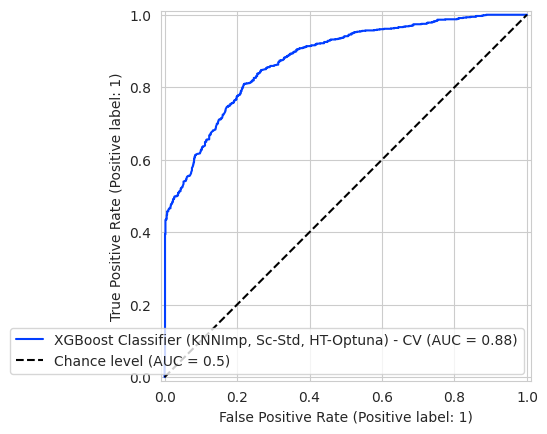

In [ ]:
plot_roc_curve_from_probabilities(
    y_true=y_holdout, y_prob_pred=y_holdout_pred_proba,
    estimator_name=best_pipeline_name_key
)

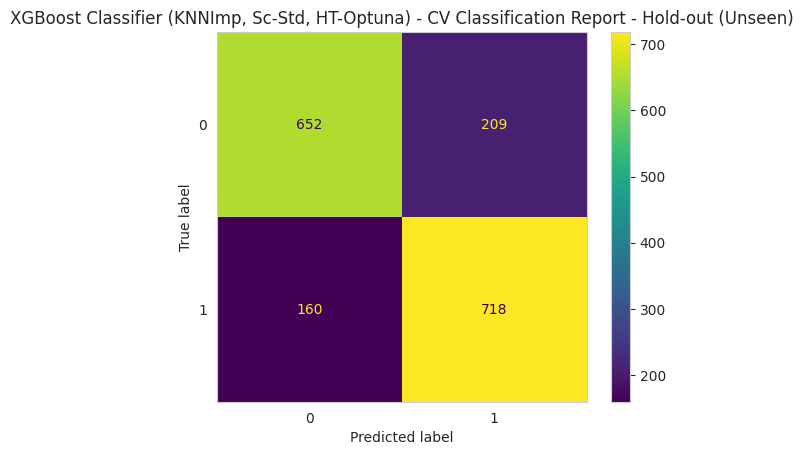

In [ ]:
plot_confusion_matrix(
    model_name=best_pipeline_name_key,
    y_true=y_holdout, y_pred=y_holdout_pred,
    modifiers='Hold-out (Unseen)'
)

In [ ]:
holdout_metrics = compute_model_info_metrics(
    y_true=y_holdout, y_pred=y_holdout_pred,
    y_pred_proba=y_holdout_pred_proba,
    estimator_name=f'Best Model - {best_pipeline_name_key} (Hold-out)'
)
model_performance_df = add_to_df(
    metrics_dict=holdout_metrics['Model_Metrics'],
    estimator_name=holdout_metrics['Model_Name'],
    old_df=model_performance_df
)
model_performance_df.xs(f'Best Model - {best_pipeline_name_key} (Hold-out)')

,Score
Metric,
Accuracy,0.787809
Precision (0),0.802956
Recall (0),0.757259
F1 Score (0),0.779438
Precision (1),0.774542
Recall (1),0.817768
F1 Score (1),0.795568
ROC AUC Score,0.876922
PR AUC Score,0.890781


The best XGBoost model

Model Interpretation

In [ ]:
X_train_tf   = best_pipeline[:-1].transform(X=X_train_cv)
X_holdout_tf = best_pipeline[:-1].transform(X=X_holdout_eval)

best_pipeline[:-1]

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('impute_encode_categorical',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['HomePlanet', 'Destination',
                                                   'cabin_cluster']),
                                                 ('impute_numerical',
                                                  KNNImputer(),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck', 'CryoSleep',
                                                   'VIP'])],
                                   verbose_feature_names_out=False)),
                ('scaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale_numerical',
                                                  StandardScaler(),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck', 'CryoSleep',
                                                   'VIP'])],
                                   verbose_feature_names_out=False))])

In [ ]:
continuous_cols = (
    best_pipeline
    .named_steps['scaler']
    .named_transformers_['scale_numerical']
    .feature_names_in_
)
continuous_cols

array(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CryoSleep', 'VIP'], dtype=object)

In [ ]:
def make_interpretable(pipeline, X, continuous_cols):
    X_tf = pipeline[:-1].transform(X)
    cont_inv = (
        pipeline
        .named_steps['scaler']
        .named_transformers_['scale_numerical']
        .inverse_transform(X_tf[continuous_cols])
    )
    cont_df = pd.DataFrame(cont_inv, index=X.index, columns=continuous_cols)
    cat_df  = X_tf.drop(columns=continuous_cols)
    return pd.concat([cont_df, cat_df], axis=1)

In [ ]:
X_train_interpretable = make_interpretable(best_pipeline, X_train_cv,    continuous_cols)
X_holdout_interpretable = make_interpretable(best_pipeline, X_holdout_eval, continuous_cols)

In [ ]:
X_holdout_interpretable

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,CryoSleep,VIP,HomePlanet_Earth,HomePlanet_Europa,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,cabin_cluster_A,cabin_cluster_B,cabin_cluster_C,cabin_cluster_D,cabin_cluster_E,cabin_cluster_F,cabin_cluster_G,cabin_cluster_T
304,1.900000e+01,417.0,3.490000e+02,634.0,3.0,1057.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2697,1.800000e+01,4.0,9.040000e+02,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8424,4.100000e+01,0.0,-5.684342e-14,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1672,3.500000e+01,0.0,3.380000e+02,436.0,2.4,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8458,4.300000e+01,0.0,-5.684342e-14,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7175,1.600000e+01,0.0,-5.684342e-14,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3187,3.552714e-15,0.0,-5.684342e-14,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1302,1.700000e+01,21.0,-5.684342e-14,690.0,260.0,5.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5934,4.200000e+01,0.0,-5.684342e-14,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
explainer = shap.Explainer(best_pipeline[-1], X_train_interpretable)
shap_values = explainer(X_holdout_interpretable)

 99%|===================| 1719/1739 [00:20<00:00]       

In [ ]:
def create_comparison_df(y_true, y_pred, y_pred_proba) -> pd.DataFrame:
    return pd.concat([
        y_true.rename('y_true'),
        pd.Series(y_pred, index=y_true.index, name='y_pred'),
        pd.Series(y_pred_proba, index=y_true.index, name='y_pred_proba')
    ], axis=1)

In [ ]:
comparison_holdout = create_comparison_df(
    y_true=y_holdout,
    y_pred=pd.Series(y_holdout_pred, index=y_holdout.index),
    y_pred_proba=pd.Series(y_holdout_pred_proba, index=y_holdout.index)
)
comparison_holdout

,y_true,y_pred,y_pred_proba
304,1,0,0.089559
2697,0,1,0.673755
8424,0,1,0.713190
1672,1,1,0.556597
8458,1,1,0.982928
...,...,...,...
7175,0,1,0.703045
3187,1,1,0.734400
1302,0,0,0.400468
5934,1,1,0.970774


Global Interpretation

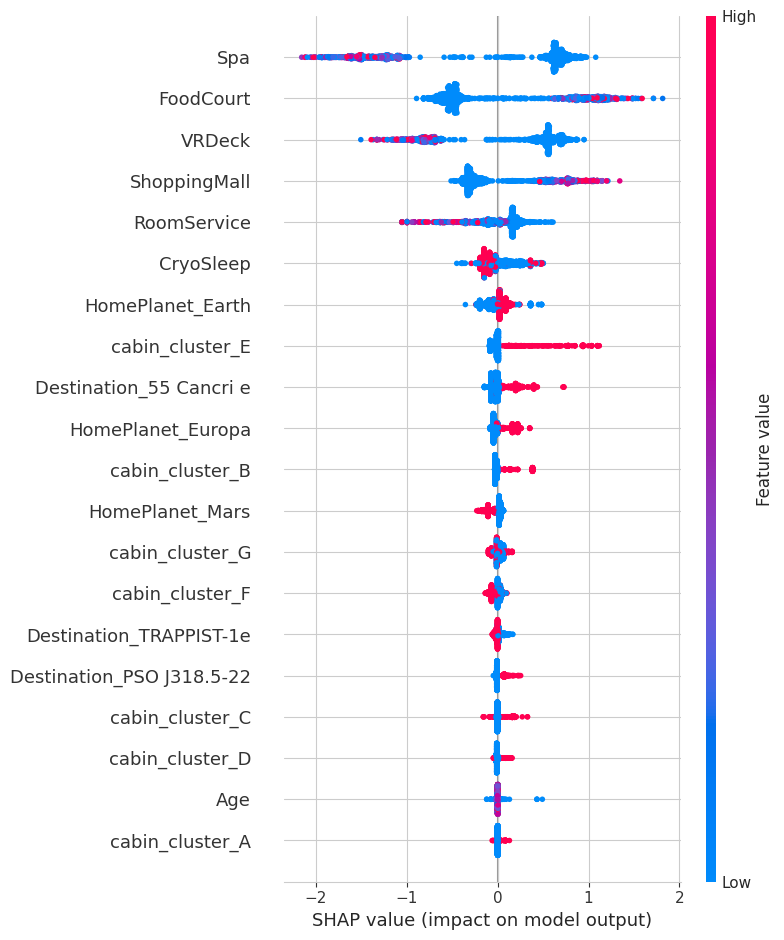

In [ ]:
shap.summary_plot(shap_values, X_holdout_interpretable)

Describes everyone in general and each point is a passenger

Accurate Prediction Local Interpretation

In [ ]:
correct_tp = comparison_holdout[
    (comparison_holdout['y_true'] == 1) & (comparison_holdout['y_pred'] == 1)
].index[0]
pos_tp = X_holdout_interpretable.index.get_loc(correct_tp)

print(f'For Passenger ID - {correct_tp}: y_true = {y_holdout.loc[correct_tp]}')
print(f'For Passenger ID - {correct_tp}: y_hat  = {y_holdout_pred[pos_tp]}')
print(f'Predicted probability of Transported=1: {y_holdout_pred_proba[pos_tp]:.5f}')

For Passenger ID - 1672: y_true = 1
For Passenger ID - 1672: y_hat  = 1
Predicted probability of Transported=1: 0.55660


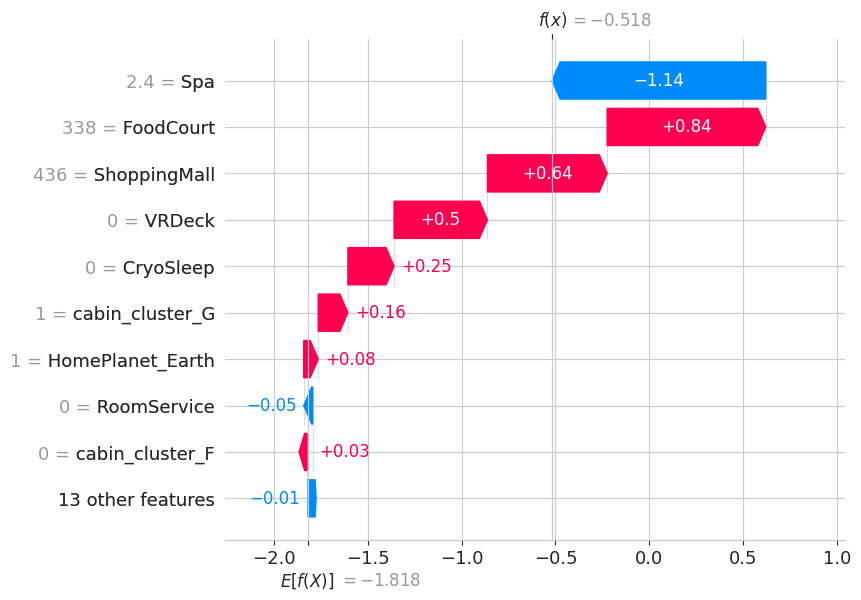

In [ ]:
shap.waterfall_plot(shap_values[pos_tp])

the passenger was actually transported and the model said transported

In [ ]:
correct_tn = comparison_holdout[
    (comparison_holdout['y_true'] == 0) & (comparison_holdout['y_pred'] == 0)
].index[0]
pos_tn = X_holdout_interpretable.index.get_loc(correct_tn)

print(f'For Passenger ID - {correct_tn}: y_true = {y_holdout.loc[correct_tn]}')
print(f'For Passenger ID - {correct_tn}: y_hat  = {y_holdout_pred[pos_tn]}')
print(f'Predicted probability of Transported=1: {y_holdout_pred_proba[pos_tn]:.5f}')

For Passenger ID - 3362: y_true = 0
For Passenger ID - 3362: y_hat  = 0
Predicted probability of Transported=1: 0.13264


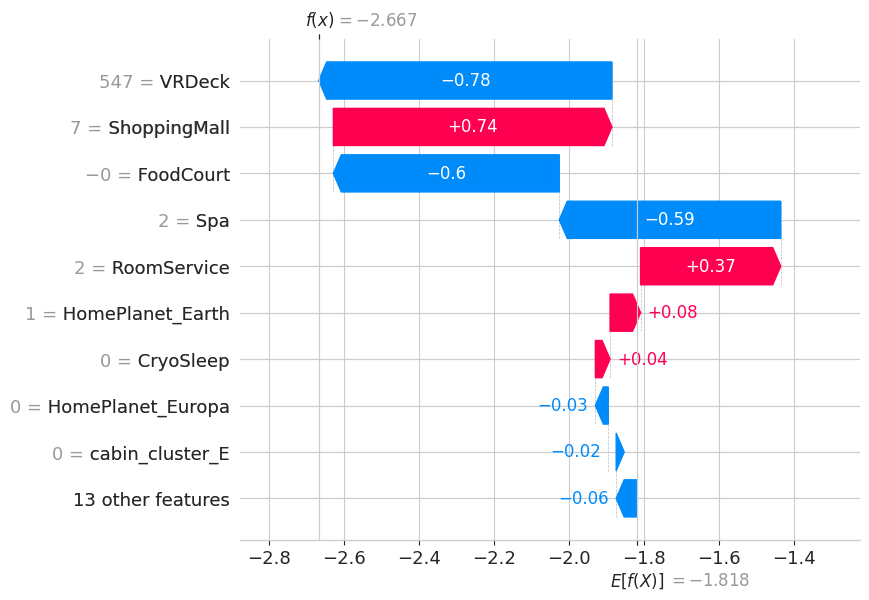

In [ ]:
shap.waterfall_plot(shap_values[pos_tn])

the passenger was not actually transported and the model said not transported

In [ ]:
correct_all = comparison_holdout[
    comparison_holdout['y_true'] == comparison_holdout['y_pred']
].copy()
correct_all['confidence'] = correct_all.apply(
    lambda r: r['y_pred_proba'] if r['y_true'] == 1 else 1 - r['y_pred_proba'], axis=1
)
high_conf_idx = correct_all['confidence'].idxmax()
pos_hc = X_holdout_interpretable.index.get_loc(high_conf_idx)

In [ ]:
print(f'For Passenger ID - {high_conf_idx}: y_true = {y_holdout.loc[high_conf_idx]}')
print(f'For Passenger ID - {high_conf_idx}: y_hat  = {y_holdout_pred[pos_hc]}')
print(f'Predicted probability of Transported=1: {y_holdout_pred_proba[pos_hc]:.5f}')

For Passenger ID - 4313: y_true = 0
For Passenger ID - 4313: y_hat  = 0
Predicted probability of Transported=1: 0.00561


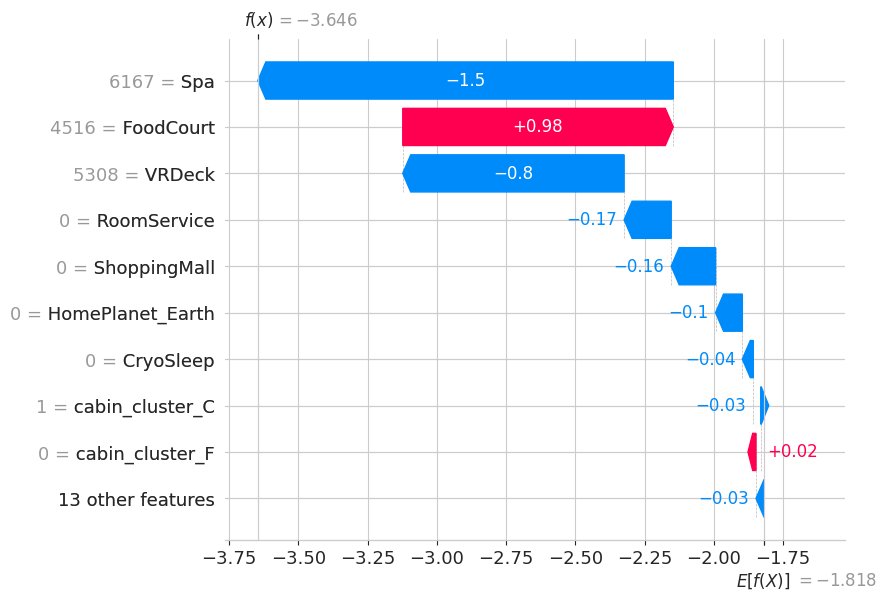

In [ ]:
shap.waterfall_plot(shap_values[pos_hc])

the most confident correct prediction

Inaccurate Predictions Local Interpretation

In [ ]:
comparison_holdout[
    (comparison_holdout['y_true'] == 1) & (comparison_holdout['y_pred'] == 0)
]

,y_true,y_pred,y_pred_proba
304,1,0,0.089559
4970,1,0,0.494153
6523,1,0,0.194567
6194,1,0,0.322714
7870,1,0,0.481830
...,...,...,...
2628,1,0,0.166110
4512,1,0,0.446735
2144,1,0,0.172255
1952,1,0,0.117008


In [ ]:
wrong_fn = comparison_holdout[
    (comparison_holdout['y_true'] == 1) & (comparison_holdout['y_pred'] == 0)
]

For Passenger ID - 304: y_true = 1
For Passenger ID - 304: y_hat  = 0
Predicted probability of Transported=1: 0.08956


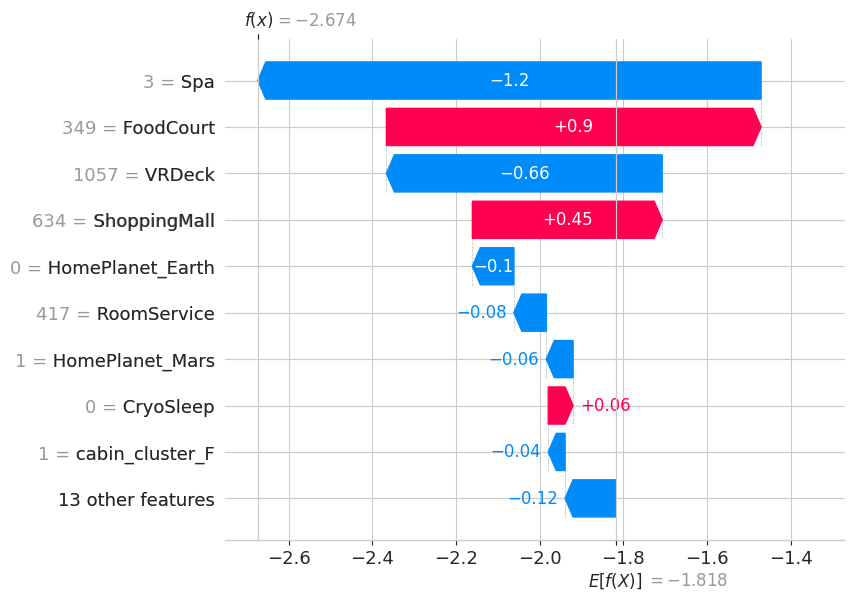

In [ ]:
if len(wrong_fn) > 0:
    fn_idx = wrong_fn.index[0]
    pos_fn = X_holdout_interpretable.index.get_loc(fn_idx)

    print(f'For Passenger ID - {fn_idx}: y_true = {y_holdout.loc[fn_idx]}')
    print(f'For Passenger ID - {fn_idx}: y_hat  = {y_holdout_pred[pos_fn]}')
    print(f'Predicted probability of Transported=1: {y_holdout_pred_proba[pos_fn]:.5f}')
    shap.waterfall_plot(shap_values[pos_fn])

The passenger was actually transported, but the model said no.

In [ ]:
comparison_holdout[
    (comparison_holdout['y_true'] == 0) & (comparison_holdout['y_pred'] == 1)
]

,y_true,y_pred,y_pred_proba
2697,0,1,0.673755
8424,0,1,0.713190
647,0,1,0.566656
3320,0,1,0.609278
8526,0,1,0.564672
...,...,...,...
4649,0,1,0.759533
547,0,1,0.564582
1737,0,1,0.560251
26,0,1,0.591661


In [ ]:
wrong_fp = comparison_holdout[
    (comparison_holdout['y_true'] == 0) & (comparison_holdout['y_pred'] == 1)
]

For Passenger ID - 2697: y_true = 0
For Passenger ID - 2697: y_hat  = 1
Predicted probability of Transported=1: 0.67375


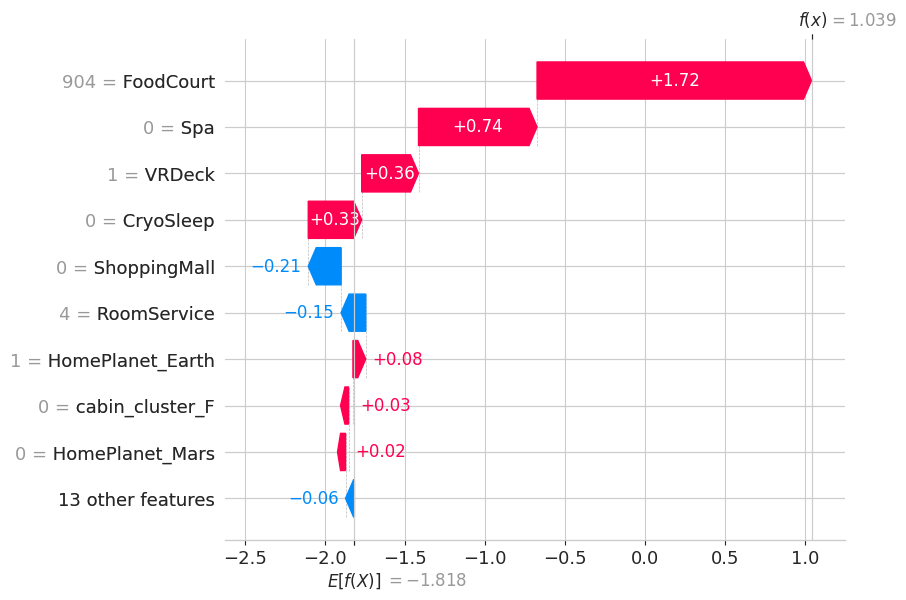

In [ ]:
if len(wrong_fp) > 0:
    fp_idx = wrong_fp.index[0]
    pos_fp = X_holdout_interpretable.index.get_loc(fp_idx)

    print(f'For Passenger ID - {fp_idx}: y_true = {y_holdout.loc[fp_idx]}')
    print(f'For Passenger ID - {fp_idx}: y_hat  = {y_holdout_pred[pos_fp]}')
    print(f'Predicted probability of Transported=1: {y_holdout_pred_proba[pos_fp]:.5f}')

    shap.waterfall_plot(shap_values[pos_fp])

The passenger was NOT actually transported, but the model said yes.

Blending

In [ ]:
for pipe in [pipeline_lgbm, pipeline_xgb, pipeline_lr, pipeline_rf]:
    pipe.fit(X=X_train_cv, y=y_train_cv)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
proba_lgbm = pipeline_lgbm.predict_proba(X=X_holdout_eval)[:, 1]
proba_xgb = pipeline_xgb.predict_proba(X=X_holdout_eval)[:, 1]
proba_lr = pipeline_lr.predict_proba(X=X_holdout_eval)[:, 1]
proba_rf = pipeline_rf.predict_proba(X=X_holdout_eval)[:, 1]

In [ ]:
proba_blend_equal = (proba_lgbm + proba_xgb + proba_lr + proba_rf) / 4
y_blend_equal_pred = (proba_blend_equal >= 0.5).astype(int)

In [ ]:
proba_blend_weighted  = 0.35*proba_lgbm + 0.35*proba_xgb + 0.15*proba_lr + 0.15*proba_rf
y_blend_weighted_pred = (proba_blend_weighted >= 0.5).astype(int)

In [ ]:
print("Blending – Equal Weights")
print_classification_report(
    model_name='Blend (Equal Weights)',
    y_true=y_holdout, y_pred=y_blend_equal_pred,
    modifiers='Hold-out'
)

Blending – Equal Weights
Blend (Equal Weights) - Hold-out - Accuracy Score: 0.7872340425531915
              precision    recall  f1-score   support

           0    0.81515   0.73751   0.77439       861
           1    0.76458   0.83599   0.79869       878

    accuracy                        0.78723      1739
   macro avg    0.78987   0.78675   0.78654      1739
weighted avg    0.78962   0.78723   0.78666      1739



In [ ]:
print("Blending – Weighted (LGBM 0.35, XGB 0.35, LR 0.15, RF 0.15)")
print_classification_report(
    model_name='Blend (Weighted)',
    y_true=y_holdout, y_pred=y_blend_weighted_pred,
    modifiers='Hold-out'
)

Blending – Weighted (LGBM 0.35, XGB 0.35, LR 0.15, RF 0.15)
Blend (Weighted) - Hold-out - Accuracy Score: 0.7860839562967222
              precision    recall  f1-score   support

           0    0.81067   0.74100   0.77427       861
           1    0.76576   0.83030   0.79672       878

    accuracy                        0.78608      1739
   macro avg    0.78821   0.78565   0.78550      1739
weighted avg    0.78800   0.78608   0.78561      1739



In [ ]:
for blend_name, y_pred_b, y_proba_b in [
    ('Blend Equal Weights (Hold-out)',   y_blend_equal_pred,   proba_blend_equal),
    ('Blend Weighted (Hold-out)',        y_blend_weighted_pred, proba_blend_weighted),
]:
    bm = compute_model_info_metrics(
        y_true=y_holdout, y_pred=y_pred_b, y_pred_proba=y_proba_b,
        estimator_name=blend_name
    )
    model_performance_df = add_to_df(
        metrics_dict=bm['Model_Metrics'],
        estimator_name=bm['Model_Name'],
        old_df=model_performance_df
    )

In [ ]:
blend_compare_names = [
    f'Best Model - {best_pipeline_name_key} (Hold-out)',
    'Blend Equal Weights (Hold-out)',
    'Blend Weighted (Hold-out)',
]
model_performance_df.loc[blend_compare_names]

Score
Model                                              Metric                 
Best Model - XGBoost Classifier (KNNImp, Sc-Std... Accuracy       0.787809
                                                   Precision (0)  0.802956
                                                   Recall (0)     0.757259
                                                   F1 Score (0)   0.779438
                                                   Precision (1)  0.774542
                                                   Recall (1)     0.817768
                                                   F1 Score (1)   0.795568
                                                   ROC AUC Score  0.876922
                                                   PR AUC Score   0.890781
Blend Equal Weights (Hold-out)                     Accuracy       0.787234
                                                   Precision (0)  0.815148
                                                   Recall (0)     0.737515
                                                   F1 Score (0)   0.774390
                                                   Precision (1)  0.764583
                                                   Recall (1)     0.835991
                                                   F1 Score (1)   0.798694
                                                   ROC AUC Score  0.879746
                                                   PR AUC Score   0.892560
Blend Weighted (Hold-out)                          Accuracy       0.786084
                                                   Precision (0)  0.810673
                                                   Recall (0)     0.740999
                                                   F1 Score (0)   0.774272
                                                   Precision (1)  0.765756
                                                   Recall (1)     0.830296
                                                   F1 Score (1)   0.796721
                                                   ROC AUC Score  0.879671
                                                   PR AUC Score   0.892689

In [ ]:
blend_acc = {
    'Best Model\n(Single)': model_performance_df.loc[
        (f'Best Model - {best_pipeline_name_key} (Hold-out)', 'Accuracy'), 'Score'],
    'Blend\n(Equal)': model_performance_df.loc[
        ('Blend Equal Weights (Hold-out)', 'Accuracy'), 'Score'],
    'Blend\n(Weighted)': model_performance_df.loc[
        ('Blend Weighted (Hold-out)', 'Accuracy'), 'Score'],
}

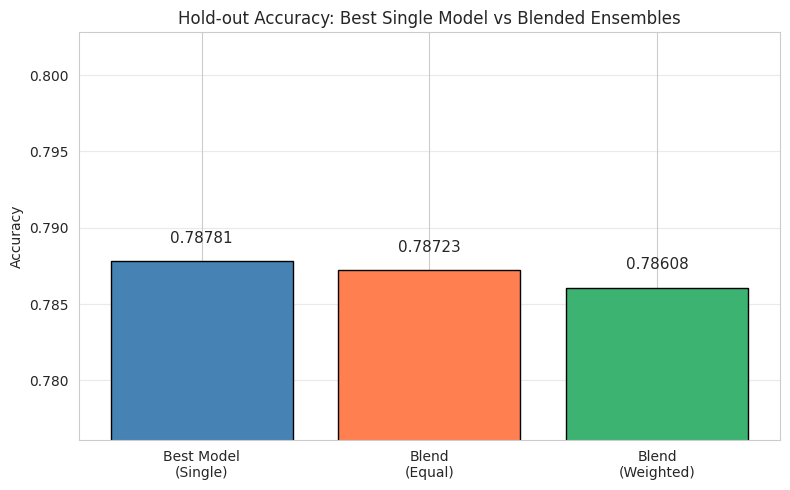

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(blend_acc.keys(), blend_acc.values(),
              color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.5f}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Hold-out Accuracy: Best Single Model vs Blended Ensembles')
ax.set_ylim(min(blend_acc.values()) - 0.01, max(blend_acc.values()) + 0.015)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
proba_lgbm_train = pipeline_lgbm.predict_proba(X=X_train_cv)[:, 1]
proba_xgb_train = pipeline_xgb.predict_proba(X=X_train_cv)[:, 1]
proba_lr_train = pipeline_lr.predict_proba(X=X_train_cv)[:, 1]
proba_rf_train = pipeline_rf.predict_proba(X=X_train_cv)[:, 1]

In [ ]:
proba_blend_equal_train  = (proba_lgbm_train + proba_xgb_train + proba_lr_train + proba_rf_train) / 4
y_blend_equal_train_pred = (proba_blend_equal_train >= 0.5).astype(int)

In [ ]:
proba_blend_weighted_train  = 0.35*proba_lgbm_train + 0.35*proba_xgb_train + 0.15*proba_lr_train + 0.15*proba_rf_train
y_blend_weighted_train_pred = (proba_blend_weighted_train >= 0.5).astype(int)

In [ ]:
print("Blend Train Accuracy (Equal Weights)")
print(f"Train Accuracy: {accuracy_score(y_train_cv, y_blend_equal_train_pred):.5f}")

print("Blend Train Accuracy (Weighted)")
print(f"Train Accuracy: {accuracy_score(y_train_cv, y_blend_weighted_train_pred):.5f}")

Blend Train Accuracy (Equal Weights)
Train Accuracy: 0.83376
Blend Train Accuracy (Weighted)
Train Accuracy: 0.83909


Submission – Blended Model

In [ ]:
X_full = pd.concat([X_train_cv, X_holdout], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train_cv, y_holdout], axis=0).reset_index(drop=True)

for pipe in [pipeline_lgbm, pipeline_xgb, pipeline_lr, pipeline_rf]:
    pipe.fit(X=X_full, y=y_full)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
proba_sub_lgbm = pipeline_lgbm.predict_proba(X=X_test_final)[:, 1]
proba_sub_xgb = pipeline_xgb.predict_proba(X=X_test_final)[:, 1]
proba_sub_lr = pipeline_lr.predict_proba(X=X_test_final)[:, 1]
proba_sub_rf = pipeline_rf.predict_proba(X=X_test_final)[:, 1]

In [ ]:
proba_sub_blend_equal = (proba_sub_lgbm + proba_sub_xgb + proba_sub_lr + proba_sub_rf) / 4
y_sub_blend_equal = (proba_sub_blend_equal >= 0.5).astype(bool)

In [ ]:
df_submission_blend_equal = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Transported': y_sub_blend_equal
})
df_submission_blend_equal.to_csv('submission_blend_equal.csv', index=False)

In [ ]:
proba_sub_blend_weighted = 0.35*proba_sub_lgbm + 0.35*proba_sub_xgb + 0.15*proba_sub_lr + 0.15*proba_sub_rf
y_sub_blend_weighted = (proba_sub_blend_weighted >= 0.5).astype(bool)

df_submission_blend_weighted = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Transported': y_sub_blend_weighted
})
df_submission_blend_weighted.to_csv('submission_blend_weighted.csv', index=False)

In [ ]:
best_pipeline.fit(X=X_full, y=y_full)
y_sub_best = (best_pipeline.predict_proba(X=X_test_final)[:, 1] >= 0.5).astype(bool)

df_submission_best = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Transported': y_sub_best
})
df_submission_best.to_csv('submission_best_model.csv', index=False)

In [ ]:
df_submission_blend_weighted.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


Conclusions

During the entire pipeline construction, the following was implemented and evaluated:

1. **Feature Engineering** – `cabin_cluster` (deck letter) was extracted from the compound
   Cabin field. Deck position encodes spatial information about where a passenger was
   on the ship, correlated with both HomePlanet and Transported outcome.

2. **Missing Values Imputation** – MICE (Baseline) and KNNImputer were compared.
   MICE leverages linear inter-feature correlations; KNNImputer is non-parametric and
   better handles the zero-inflated, right-skewed spending distributions.

3. **Class Balance Analysis** – The target is ~50/50 balanced. SMOTE and similar
   resampling techniques were explicitly not applied, as they would add noise and
   distort the decision boundary without any benefit on an already balanced dataset.

4. **Feature Scaling** – Standard Scaler was applied to numeric features.
   Tree-based models were unaffected; Logistic Regression showed clear improvement
   due to more stable gradient descent convergence across features with vastly
   different value ranges (0–30,000 for spending vs 0–1 for CryoSleep).

5. **Feature Selection** – P-Value Selector removed statistically insignificant features.
   Particularly relevant after OHE introduces many low-frequency binary dummies
   (e.g. rare cabin deck letters).

6. **Overfitting Analysis** – Train vs CV Accuracy gap was measured for all tuned models.
   Random Forest showed the largest gap (memorisation of CryoSleep=0 + spending=0
   exact patterns). LightGBM and XGBoost had smaller gaps due to Optuna-tuned
   regularisation. A gap < 0.03 was considered acceptable.

7. **Hyperparameter Tuning** – Optuna (TPE sampler) was used for all four models,
   optimising CV Accuracy to align with the Kaggle evaluation metric.

8. **Model Interpretation (SHAP)** – Four SHAP plots confirmed that CryoSleep is the
   dominant predictor. Spending features (RoomService, Spa, VRDeck, FoodCourt,
   ShoppingMall) act as a correlated cluster confirming cryo status. HomePlanet_Europa
   and young Age provide secondary positive signal for transportation.

9. **Blending** – Equal-weight and weighted ensemble of all four tuned models was
   evaluated on the hold-out set and used for final Kaggle submission. Three submission
   files were generated for comparison.

Key insights from EDA confirmed by SHAP:
- CryoSleep is the strongest predictor: cryo passengers spent $0 on all services
  and were transported at a much higher rate.
- HomePlanet Europa passengers were transported significantly more often than Earth or Mars.
- Spending features are negatively correlated with transportation probability —
  spending money is a proxy for being awake (not in CryoSleep).
- Young passengers (< 10) had a disproportionately high transportation rate.
- Incorrect predictions are most often explained by missing CryoSleep values that
  were imputed incorrectly, causing the model to lose its strongest signal.